In [1]:
!pip install kozax
!pip install brax
!pip install gymnax
!pip install jaxtyping

In [2]:
# Specify the cores to use for XLA
import functools
import os
os.environ["XLA_FLAGS"] = '--xla_force_host_platform_device_count=10'
import jax
import jax.numpy as jnp
import jax.random as jr

#import gymnax
import brax
from brax import envs
import matplotlib.pyplot as plt

from kozax.genetic_programming import GeneticProgramming
from kozax.fitness_functions.Gymnax_fitness_function import GymFitnessFunction

Failed to import warp: No module named 'warp'
Failed to import mujoco_warp: No module named 'warp'
These device(s) are detected: [CpuDevice(id=0), CpuDevice(id=1), CpuDevice(id=2), CpuDevice(id=3), CpuDevice(id=4), CpuDevice(id=5), CpuDevice(id=6), CpuDevice(id=7), CpuDevice(id=8), CpuDevice(id=9)]


# Brax comparison

## Kozax

In [3]:
#Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
inv_pen_koz_1 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_1 = jnp.array([9357.037, 9359.12, 9358.753, 9358.725, 9357.877, 9357.457, 9359.156, 9359.297, 9358.126, 9358.464])
reacher_koz_1 = jnp.array([-44.87253, -17.745766, -14.169327, -47.63744, -42.01737, -73.18745, -49.66477, -18.541279, -131.94737, -34.372272])
swimmer_koz_1 = jnp.array([366.0406, 366.0734, 366.87454, 367.08075, 365.97742, 365.45813, 364.86426, 365.81805, 364.79086, 366.9635])
hopper_koz_1 = jnp.array([1199.6332, 1177.7301, 1247.7908, 1228.2421, 1177.3754, 1184.458, 1197.1526, 1193.1149, 1189.3345, 1183.6586])
walker2d_koz_1 = jnp.array([280.34158, 256.11685, 249.40906, 245.11902, 268.775, 247.34793, 298.68124, 311.4616, 250.55458, 246.22557]) # max_nodes = 7
half_cheetah_koz_1 = jnp.array([5030.8115, 4998.507, 4782.6353, 4975.135, 5163.064, 5024.8496, 4977.914, 5111.1265, 5081.814, 4945.8696]) # max_nodes = 7
ant_koz_1 = jnp.array([222.7219, 320.6515, 355.0758, 104.46048, 33.967506, 377.49023, 202.84161, 250.88937, 454.81415, 485.24106]) # max_nodes = 7

#Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
inv_pen_koz_2 = jnp.array([1000., 1000., 1000.,  620., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_2 = jnp.array([9354.579, 9359.588, 9358.889, 9357.842, 9356.544, 8376.444, 9358.368, 9359.737, 9355.103, 9358.697])
reacher_koz_2 = jnp.array([-76.42881, -11.442436, -9.734155, -125.53045, -17.742325, -28.035576, -31.190842, -10.783359, -35.829453, -80.139626])
swimmer_koz_2 = jnp.array([361.54105, 366.2345, 366.5612, 367.1253, 365.09348, 366.06464, 365.34174, 366.00275, 364.85516, 365.8025])
hopper_koz_2 = jnp.array([1164.8481, 1118.759, 1139.3821, 1156.9786, 1118.4917, 1158.2399, 1129.1803, 1127.7664, 1161.3081, 1149.5365])
walker2d_koz_2 = jnp.array([1141.0729, 1142.9606, 1142.7114, 1144.0468, 1147.3556, 1136.5703, 1144.5051, 1145.0028, 1137.4034, 1144.1232]) # max_nodes = 7
half_cheetah_koz_2 = jnp.array([3633.6216, 3644.07, 3621.1821, 3655.7021, 3685.6287, 3616.2817, 3623.5586, 3650.5955, 3621.121, 3648.761 ]) # max_nodes = 7
ant_koz_2 = jnp.array([917.4532, 105.59323, 221.99437, 571.84125, 146.73146, 336.20676, 760.23267, 67.42464, 254.5915, 10.293206]) # max_nodes = 7

#Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 15)
inv_pen_koz_3 = jnp.array([1000., 1000., 1000.,  646., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_3 = jnp.array([9355.532, 9359.4375, 9359.118, 9357.713, 9357.108, 7958.565, 9359.1045, 9359.362, 9356.851, 9359.208 ])
reacher_koz_3 = jnp.array([-41.499214, -176.17009, -209.36317, -23.784708, -51.600853, -33.61942, -35.026424, -191.99925, -22.322062, -32.76813])
swimmer_koz_3 = jnp.array([363.35333, 366.32297, 366.81186, 366.50726, 367.83246, 364.71802, 364.61197, 365.92163, 363.40134, 366.2321])
hopper_koz_3 = jnp.array([1113.0027, 1122.0856, 1098.9341, 1107.2761, 1121.335, 1098.8802, 1114.3518, 1100.3206, 1122.0569, 1110.0243])
walker2d_koz_3 = jnp.array([1110.6194, 1110.0742, 1113.9567, 1109.0103, 1108.8289, 1114.5671, 1111.9152, 1111.5178, 1114.213, 1113.2781]) # max_nodes = 7
half_cheetah_koz_3 = jnp.array([3911.815, 3797.7998, 3879.1118, 3935.6958, 3858.3154, 3702.5083, 3857.3838, 3898.5312, 3699.9294, 3889.0413]) # max_nodes = 7
ant_koz_3 = jnp.array([504.10974, 322.28232, 1184.9219, 404.4476, 638.33826, 1095.2211, 1024.2231, 1122.5476, 219.83997, 600.38837]) # max_nodes = 7, punish_duplicates = False

#Kozax (pop_size = 5x200, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 31)
inv_pen_koz_4 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_4 = jnp.array([9357.037, 9359.12, 9358.753, 9358.725, 9357.877, 9357.457, 9359.156, 9359.297, 9358.126, 9358.464])
reacher_koz_4 = jnp.array([-145.4002, -19.121103, -20.50119, -170.51462, -19.075264, -23.408243, -32.24815, -15.488464, -20.877077, -192.1216])
swimmer_koz_4 = jnp.array([364.85022, 368.6852, 369.38287, 369.25504, 367.07794, 368.96466, 366.30878, 368.42447, 367.607, 365.9111])
hopper_koz_4 = jnp.array([1460.4553, 1427.8954, 1213.5117, 1430.4442, 1443.2144, 1462.6288, 1442.805, 1439.8119, 1411.4772, 1196.9066])
walker2d_koz_4 = jnp.array([965.1732, 1022.33386, 1172.5381, 1007.2782, 833.53314, 1122.0557, 1067.9847, 1003.89813, 790.89844, 753.0572 ]) # max_nodes = 7
half_cheetah_koz_4 = jnp.array([3773.6018, 3778.5623, 3926.513, 3843.472, 3859.0605, 3753.0261, 3754.9321, 3757.889, 3933.7766, 3802.9883]) # max_nodes = 7, batch_size = 10
ant_koz_4 = jnp.array([393.51364, 175.44182, 134.69951, 327.3441,  217.51797, 254.19913, 242.60353, 520.2767, 150.1278, 429.0715]) # max_nodes = 7

# #Modi Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
# inv_pen_modi = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_modi = jnp.array([9355.8545, 9359.465, 9358.972, 9357.854, 9356.783, 9350.944, 9358.734, 9359.593, 9355.387, 9358.907])
# reacher_modi = jnp.array([-175.19783, -63.13835, -37.02901, -180.53899, -57.421474, -28.747427, -33.05677, -56.196613, -43.199436, -203.85191])
# swimmer_modi = jnp.array([356.5535, 362.9277, 364.44666, 363.63202, 359.30313, 363.15305, 361.96964, 362.48068, 361.0248, 355.5801])
# hopper_modi = jnp.array([984.09064, 1094.1439, 1131.451, 1117.8174, 1077.4199, 1162.1007, 1105.1051, 955.29395, 1085.3868, 1023.7265])
# walker2d_modi = jnp.array([153.24753, 297.67093, 298.46902, 341.44586, 370.54337, 262.10083, 278.31628, 314.96555, 289.04016, 226.69106])
# half_cheetah_modi = jnp.array([4578.9385, 4324.202, 4306.3193, 4341.361, 4345.3438, 4318.327, 4390.781, 4281.847, 4272.643, 4597.422])
# ant_modi = jnp.array([1111.7856, 57.949547, 1156.3043, 987.65015, 1154.1079, 1156.6812, 1140.5776, 1144.268, 1040.0242, 1154.5076])

# #CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

# inv_pen_cgpax = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_cgpax = jnp.array([6085.7686, 9352.39, 7519.252, 8480.27, 6468.175, 5534.562, 7947.753, 9356.813, 6077.8467, 6985.178])
# reacher_cgpax = jnp.array([-39.922165, -49.821873, -60.0979, -18.984558, -196.48444, -95.03198, -85.89033, -64.415504, -143.82385, -35.902977])
# swimmer_cgpax = jnp.array([340.49014, 354.60565, 357.7974, 356.29767, 332.6057, 343.8158, 355.68326, 350.99344, 350.90198, 356.40247])
# hopper_cgpax = jnp.array([1095.3315, 1113.9839, 1087.3208, 1162.5234, 1101.0757, 1126.1235, 1115.9884, 1135.301, 1101.0874, 1095.2422])
# walker2d_cgpax = jnp.array([1006.7979, 998.26044, 186.08589, 1002.9979, 1002.74066, 199.45091, 199.19106, 1005.68115, 188.41426, 998.5209])
# half_cheetah_cgpax = jnp.array([2996.433, 2989.0247, 2931.519, 2966.6746, 2851.7498, 2970.5422, 2968.7727, 3031.474, 2988.5461, 2880.8806])
# ant_cgpax = jnp.array([480.9499, 975.9896, 158.4743, 146.41995, 931.418, 1125.1726, 638.22107, 1233.552, 652.7863, 6.751278])

# #CGPAX seed 0 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_1 = jnp.array([327., 286., 302., 255., 317., 756., 871., 369., 800., 830.])
# inv_double_pen_cgpax_1 = jnp.array([6085.769, 9352.39, 7519.252, 8480.269, 6468.176, 5534.562, 7947.753, 9356.814, 6077.847, 6985.178])
# reacher_cgpax_1 = jnp.array([-7.4905834, -163.55624, -184.84052, -15.100983, -253.42589, -94.9962, -70.69127, -175.25826, -151.07886, -30.723774])
# swimmer_cgpax_1 = jnp.array([-83.04826, -88.872894, 290.13858, -86.28288, 281.96912, 290.61572, 270.7681, -89.37675, 290.27258, 289.76736])
# hopper_cgpax_1 = jnp.array([1065.0084, 908.15247, 975.2533, 1074.8286, 1078.4054, 1064.7007, 1105.2708, 842.52515, 1050.9861, 984.34064])
# walker2d_cgpax_1 = jnp.array([476.44366, 297.28305, 184.7797, 580.2114, 485.383, 243.22278, 180.2444, 479.88785, 249.75342, 709.9433])
# half_cheetah_cgpax_1 = jnp.array([580.0425, 560.63776, 576.0425, 565.81964, 583.5791, 544.6001, 543.2681, 596.8219, 583.0479, 598.6538])
# ant_cgpax_1 = jnp.array([50.75792, 6.551172, 949.8468, 1286.7367, 9.833655, 4.799202, 1378.0898, 833.31647, 1215.5165, 13.6646805])

# #CGPAX seed 26 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_2 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_cgpax_2 = jnp.array([1044.9553, 1503.5643, 1437.9645, 1568.8003, 1016.30304, 1044.8029, 1640.746, 1456.9756, 1363.4429, 1006.9472])
# reacher_cgpax_2 = jnp.array([-52.020493, -169.55801, -152.3594, -57.278828, -104.88697, -67.94385, -48.766273, -176.55815, -110.21392, -14.164314])
# swimmer_cgpax_2 = jnp.array([363.89423, 364.96524, 366.26532, 365.95493, 367.21057, 366.97, 362.46048, 365.31403, 364.1156, 366.5797])
# hopper_cgpax_2 = jnp.array([825.0731, 1072.1655, 822.0334, 1062.8568, 824.7747, 1069.6842, 1003.4234, 1051.3003, 807.047, 867.9057])
# walker2d_cgpax_2 = jnp.array([289.4038, 280.1455, 256.0286, 290.58295, 288.66913, 269.15347, 262.44696, 286.61493, 255.7673, 291.05807])
# half_cheetah_cgpax_2 = jnp.array([2755.5637, 2661.911, 2893.0732, 2802.624, 2621.4885, 2825.1545, 2462.8484, 2595.2903, 2911.7817, 2358.1855])
# ant_cgpax_2 = jnp.array([474.25043, 535.41016, 509.94208, 8.219259, 4.738791, -2.3205132, 529.02094, 496.2157, 497.80035, 526.80493])

# #CGPAX seed 10 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_3 = jnp.array([1000., 1000., 1000.,  619., 1000., 1000., 844., 1000., 1000., 1000.])
# inv_double_pen_cgpax_3 = jnp.array([9355.65, 9358.7295, 9358.095, 9357.979, 9356.994, 9355.965, 9358.791, 9358.988, 9358.201, 9357.607])
# reacher_cgpax_3 = jnp.array([-59.30034, -42.06773, -35.455994, -59.454384, -275.2382, -98.774536, -74.93168, -30.89294, -151.66763, -27.037868])
# swimmer_cgpax_3 = jnp.array([354.68875, 355.18967, 360.3561, 360.3968, 355.34338, 357.10434, 353.88812, 358.06656, 352.87103, 353.88028])
# hopper_cgpax_3 = jnp.array([1062.6826, 1069.1431, 1066.7932, 1061.0326, 1059.439, 1068.8335, 1063.7628, 1061.562, 1064.9453, 1061.7975])
# walker2d_cgpax_3 = jnp.array([107.38916, 204.52266, 298.34244, 316.10608, 288.2991, 209.57796, 279.2315, 120.26227, 21.290922, 238.33588])
# half_cheetah_cgpax_3 = jnp.array([-128.7229, -655.4468, -364.5511, -205.94751, -96.49075, -350.7605, -257.85593, -19.034502, -51.94186, -164.36374 ])
# ant_cgpax_3 = jnp.array([383.82178, 979.60376, 1119.153, 998.07886, 366.9502, 1094.5615, 763.23236, 666.5521, 941.32227, 1009.0104])

# #PPO ()
# inv_pen_ppo = jnp.array([1000, 1000, 1000])
# inv_double_pen_ppo =  jnp.array([9359.55, 2233.88, 7846.11])
# reacher_ppo = jnp.array([-8.57, -7.47, -8.19])
# swimmer_ppo = jnp.array([41.43, 32.11, 38.10])
# hopper_ppo =  jnp.array([662.54, 362.60, 333.84])
# walker2d_ppo =  jnp.array([1039.15, 608.69, 1129.97])
# half_cheetah_ppo =  jnp.array([15637.27, 10508.78, 15843.99])
# ant_ppo =  jnp.array([7554.29, 7184.30, 7314.80])

# #SAC ()
# inv_pen_sac = jnp.array([872.09, 1000, 1000])
# inv_double_pen_sac = jnp.array([9358.22, 9351.96, 9355.70])
# reacher_sac = jnp.array([-67.69, -68.26, -67.54])
# swimmer_sac = jnp.array([282.62, 330.16, 329.65])
# hopper_sac = jnp.array([3761.52, 3611.48, 3577.32])
# walker2d_sac = jnp.array([5526.82, 2503.95, ])
# half_cheetah_sac = jnp.array([14178.33, 16453.82, 17423.82])
# ant_sac = jnp.array([5283.45, 6055.11, 5345.16])

inv_pen_results = [inv_pen_koz_1, inv_pen_koz_2, inv_pen_koz_3, inv_pen_koz_4]
inv_double_pen_results = [inv_double_pen_koz_1, inv_double_pen_koz_2, inv_double_pen_koz_3, inv_double_pen_koz_4]
reacher_results = [reacher_koz_1, reacher_koz_2, reacher_koz_3, reacher_koz_4]
swimmer_results = [swimmer_koz_1, swimmer_koz_2, swimmer_koz_3, swimmer_koz_4]
hopper_results = [hopper_koz_1, hopper_koz_2, hopper_koz_3, hopper_koz_4]
walker2d_results = [walker2d_koz_1, walker2d_koz_2, walker2d_koz_3, walker2d_koz_4]
half_cheetah_results = [half_cheetah_koz_1, half_cheetah_koz_2, half_cheetah_koz_3, half_cheetah_koz_4]
ant_results = [ant_koz_1, ant_koz_2, ant_koz_3, ant_koz_4]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

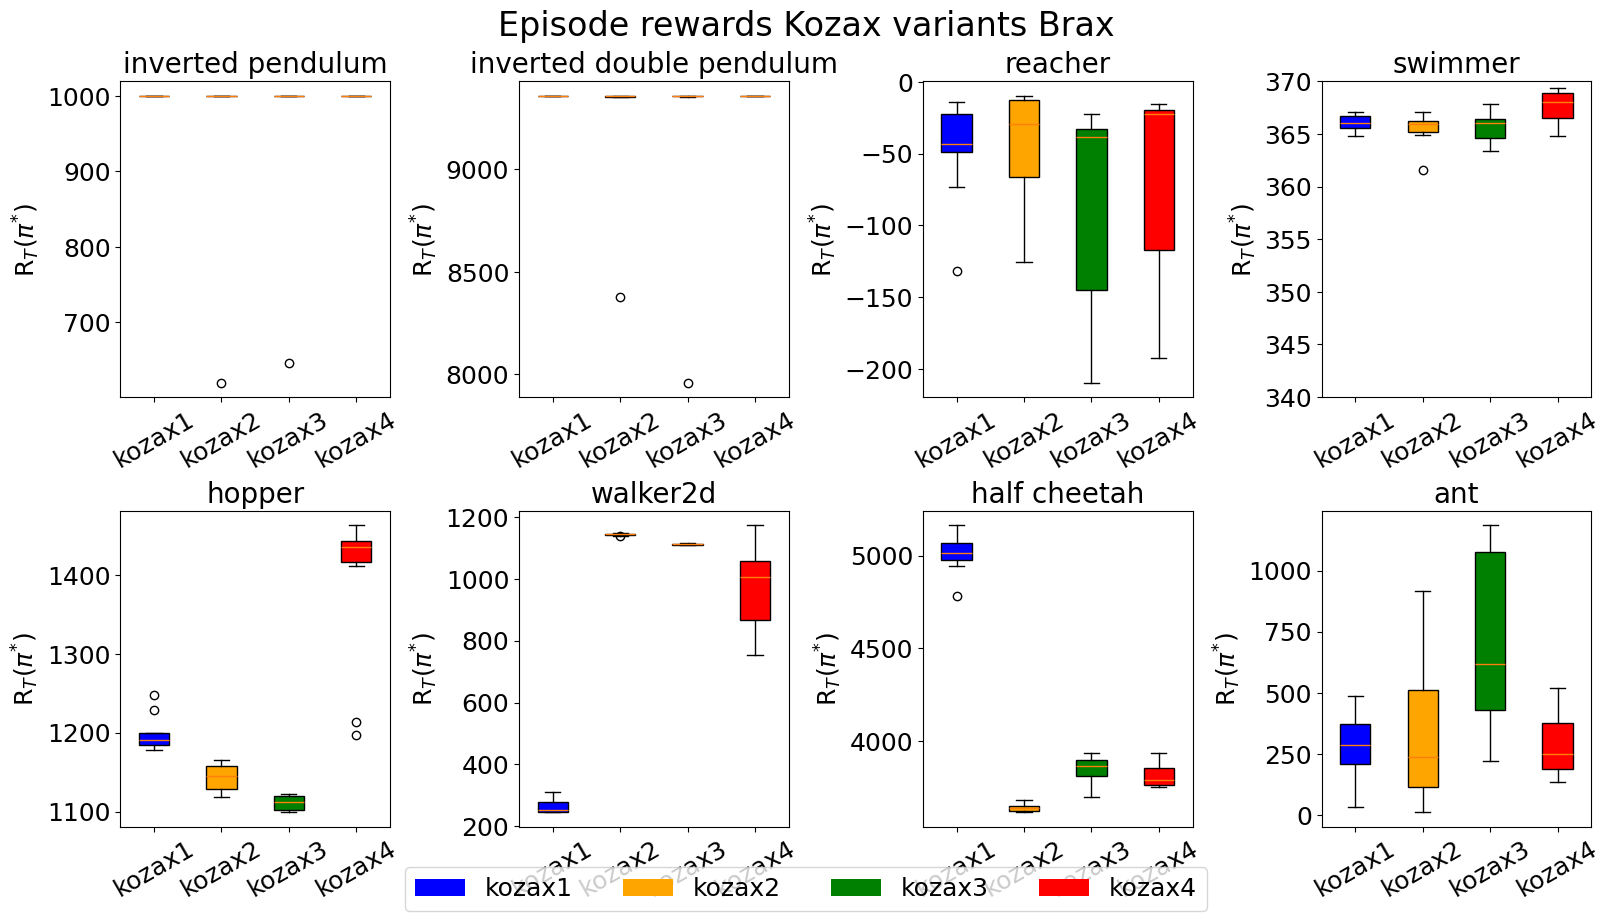

In [4]:
from matplotlib.patches import Patch

nrows = 2
ncols = 4
plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
colors = ["blue", "orange", "green", "red"]
tick_labels = ["kozax1", "kozax2", "kozax3", "kozax4"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Episode rewards Kozax variants Brax", fontsize=24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize=20)
    if plot_titles[idx] == "swimmer":
      axs[i,j].set_ylim((340, 370))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize=18)
    axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize=18)
    axs[i, j].tick_params(axis="y", labelsize=18)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=18
)

In [5]:
#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
inv_pen_koz_1 = [[1, 181.9375],[3, 240.75],[5, 977.0],[7, 1000]]
inv_double_pen_koz_1 = [[1, 440.76], [3, 1086.07], [5, 2160.14], [7, 8854.65], [9, 9356.14], [13, 9357.80], [15, 9357.97]]
reacher_koz_1 = [[2, -112.85],[4, -80.09],[6, -77.81],[8, -76.78], [10, -76.25], [12, -71.30], [14, -66.94], [16, -60.69], [20, -59.15], [24, -56.50]]
swimmer_koz_1 = [[2, 140.60], [4, 256.43], [6, 341.89], [8, 359.38], [10, 361.20], [12, 363.12], [14, 363.84], [16, 365.01], [18, 365.70]]
hopper_koz_1 = [[3, 70.32], [7, 317.14], [9, 907.31], [13, 1001.21], [15, 1004.28], [17, 1038.74], [19, 1070.18], [21, 1082.11], [23, 1090.53], [25, 1138.27], [27, 1198.30]]
walker2d_koz_1 = [[14, 26.06], [18, 32.06], [20, 175.24], [22, 187.84], [26, 220.54], [30, 233.10], [32, 240.52], [34, 263.88]]
half_cheetah_koz_1 = [[14, 39.73], [16, 2690.80], [18, 2951.04], [20, 3260.05], [22, 3529.84], [26, 3888.21], [30, 4284.81], [32, 4451.58], [34, 4540.71], [36, 5028.03]]
ant_koz_1 = [[20, -311.94], [22, -6.01], [24, 1.39], [26, 85.32], [28, 161.22], [30, 247.77], [38, 299.61], [44, 392.25], [52, 412.14]]
koz_1 = [inv_pen_koz_1, inv_double_pen_koz_1, reacher_koz_1, swimmer_koz_1, hopper_koz_1, walker2d_koz_1, half_cheetah_koz_1, ant_koz_1]

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
inv_pen_koz_2 = [[1, 181.9375],[3, 240.75],[5, 977.0],[6, 1000.0]]
inv_double_pen_koz_2 = [[1, 440.76], [3, 8804.75], [7, 8897.35], [8, 8913.10], [9, 9190.37], [10, 9357.38]]
reacher_koz_2 = [[2, -112.85],[3, -112.82], [4, -112.77],[6, -58.20],[8, -46.43], [12, -36.63], [17, -31.12], [24, -30.28]]
swimmer_koz_2 = [[2, 139.91], [3, 184.04], [4, 236.37], [5, 249.93], [6, 341.74], [7, 351.82], [8, 357.63], [9, 362.59], [15, 363.84], [17, 365.32]]
hopper_koz_2 = [[3, 53.54], [4, 105.17], [5, 175.64], [7, 244.39], [8, 367.93], [9, 562.77], [11, 990.75], [12, 1012.87], [13, 1050.76], [14, 1085.74], [15, 1104.03], [23, 1108.34], [27, 1111.54], [28, 1116.96], [34, 1133.90], [37, 1139.76]]
walker2d_koz_2 = [[9, 2.40], [13, 121.12], [15, 121.43], [17, 173.18], [18, 196.51], [21, 265.62], [22, 620.36], [26, 896.13], [29, 921.80], [30, 1123.41], [31, 1143.68]]
half_cheetah_koz_2 = [[10, 47.73], [12, 2193.31], [14, 2229.79], [15, 2795.47], [18, 3646.92]]
ant_koz_2 = [[17, 16.67], [20, 100.93], [22, 124.78], [23, 130.62], [24, 150.84], [26, 180.70], [27, 217.14], [39, 225.26], [40, 262.33], [41, 267.67], [42, 286.79], [43, 405.86]]
koz_2 = [inv_pen_koz_2, inv_double_pen_koz_2, reacher_koz_2, swimmer_koz_2, hopper_koz_2, walker2d_koz_2, half_cheetah_koz_2, ant_koz_2]

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 15)
inv_pen_koz_3 = [[1, 181.94], [3, 273.81], [5, 977.0], [6, 1000.0]]
inv_double_pen_koz_3 = [[1, 440.76], [3, 6974.55], [5, 8679.20], [6, 8703.91], [7, 9003.73], [8, 9277.10], [9, 9322.84], [10, 9357.23], [12, 9357.70], [14, 9357.95]]
reacher_koz_3 = [[2, -125.70], [3, -112.82], [4, -80.09], [6, -79.91], [8, -62.12], [9, -58.33], [10, -58.33], [11, -53.99], [13, -42.98], [14, -42.85], [16, -40.47], [20, -40.20]]
swimmer_koz_3 = [[2, 58.21], [4, 210.24], [6, 341.74], [7, 348.37], [8, 357.63], [12, 362.91], [16, 363.34], [20, 365.45]]
hopper_koz_3 = [[3, 194.09], [5, 970.62], [7, 1043.71], [9, 1044.10], [11, 1061.17], [12, 1067.99], [13, 1068.31], [14, 1078.20], [15, 1082.94], [16, 1091.81], [17, 1096.30], [19, 1107.29]]
walker2d_koz_3 = [[16, -0.75], [17, 30.14], [19, 96.92], [20, 213.41], [21, 333.53], [23, 333.85], [24, 337.96], [25, 1096.91], [26, 1097.53], [28, 1097.81], [30, 1104.54], [31, 1108.07], [32, 1110.13], [36, 1112.26]]
half_cheetah_koz_3 = [[12, 3079.68], [16, 3609.61], [17, 3628.88], [18, 3856.85], [20, 3880.94]]
ant_koz_3 = [[20, 49.62], [22, 44.54], [23, 38.46], [25, 72.46], [28, 83.19], [30, 89.15], [31, 333.77], [32, 454.42], [38, 525.35], [41, 556.53], [43, 610.33], [45, 701.30], [46, 994.37], [52, 1003.27]]
koz_3 = [inv_pen_koz_3, inv_double_pen_koz_3, reacher_koz_3, swimmer_koz_3, hopper_koz_3, walker2d_koz_3, half_cheetah_koz_3, ant_koz_3]

#Kozax (pop_size = 200, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 31)
inv_pen_koz_4 = [[1, 181.9375],[3, 240.75], [4, 233.375], [5, 977.0],[7, 1000.0]]
inv_double_pen_koz_4 = [[1, 440.76], [3, 7958.79], [8, 7974.86], [9, 9336.08], [11, 9355.83], [15, 9357.83], [17, 9358.13], [20, 9358.14], [21, 9358.21], [22, 9358.46], [23, 9358.78], [25, 9358.95], [27, 9359.08], [30, 9359.08]]
reacher_koz_4 = [[2, -112.85],[4, -80.09],[6, -80.09],[7, -77.78],[9, -58.08], [12, -57.26], [13, -56.53], [15, -41.00], [16, -40.64], [23, -40.53], [25, -40.51], [26, -40.25], [27, -39.98], [29, -39.81], [30, -34.01], [32, -33.95], [39, -33.22]]
swimmer_koz_4 = [[2, 138.48], [3, 181.37], [4, 264.07], [5, 265.49], [6, 341.74], [8, 347.16], [9, 356.61], [11, 357.79], [12, 362.47], [21, 362.57], [22, 363.79], [29, 364.62], [34, 365.01] ,[36, 366.15], [38, 366.49], [41, 367.13]]
hopper_koz_4 = [[3, 122.01], [5, 173.79], [7, 369.96], [8, 794.16], [9, 1006.32], [11, 1019.01], [14, 1042.62], [16, 1064.96], [18, 1068.88], [19, 1104.18], [20, 1117.56], [24, 1120.43], [31, 1124.18], [35, 1264.14]]
walker2d_koz_4 = [[11, 18.35], [12, 36.82], [13, 47.52], [14, 162.26], [15, 261.91], [16, 276.49], [23, 835.23], [29, 849.12], [30, 887.32], [31, 888.11], [33, 1027.74]]
half_cheetah_koz_4 = [[8, -264.65], [9, 125.87], [10, 387.41], [11, 1736.76], [13, 2887.86], [14, 3055.33], [15, 3063.32], [18, 3104.06], [19, 3137.95], [20, 3236.85], [22, 3397.43], [23, 3466.47], [26, 3909.11]]
ant_koz_4 = [[14, -515.77], [17, -108.45], [18, -13.25], [19, 25.72], [21, 44.20], [23, 60.68], [25, 78.12], [26, 121.41], [31, 176.04], [33, 205.64], [34, 206.08], [38, 229.50], [39, 304.04]]
koz_4 = [inv_pen_koz_4, inv_double_pen_koz_4, reacher_koz_4, swimmer_koz_4, hopper_koz_4, walker2d_koz_4, half_cheetah_koz_4, ant_koz_4]

all_koz = [koz_1, koz_2, koz_3, koz_4]

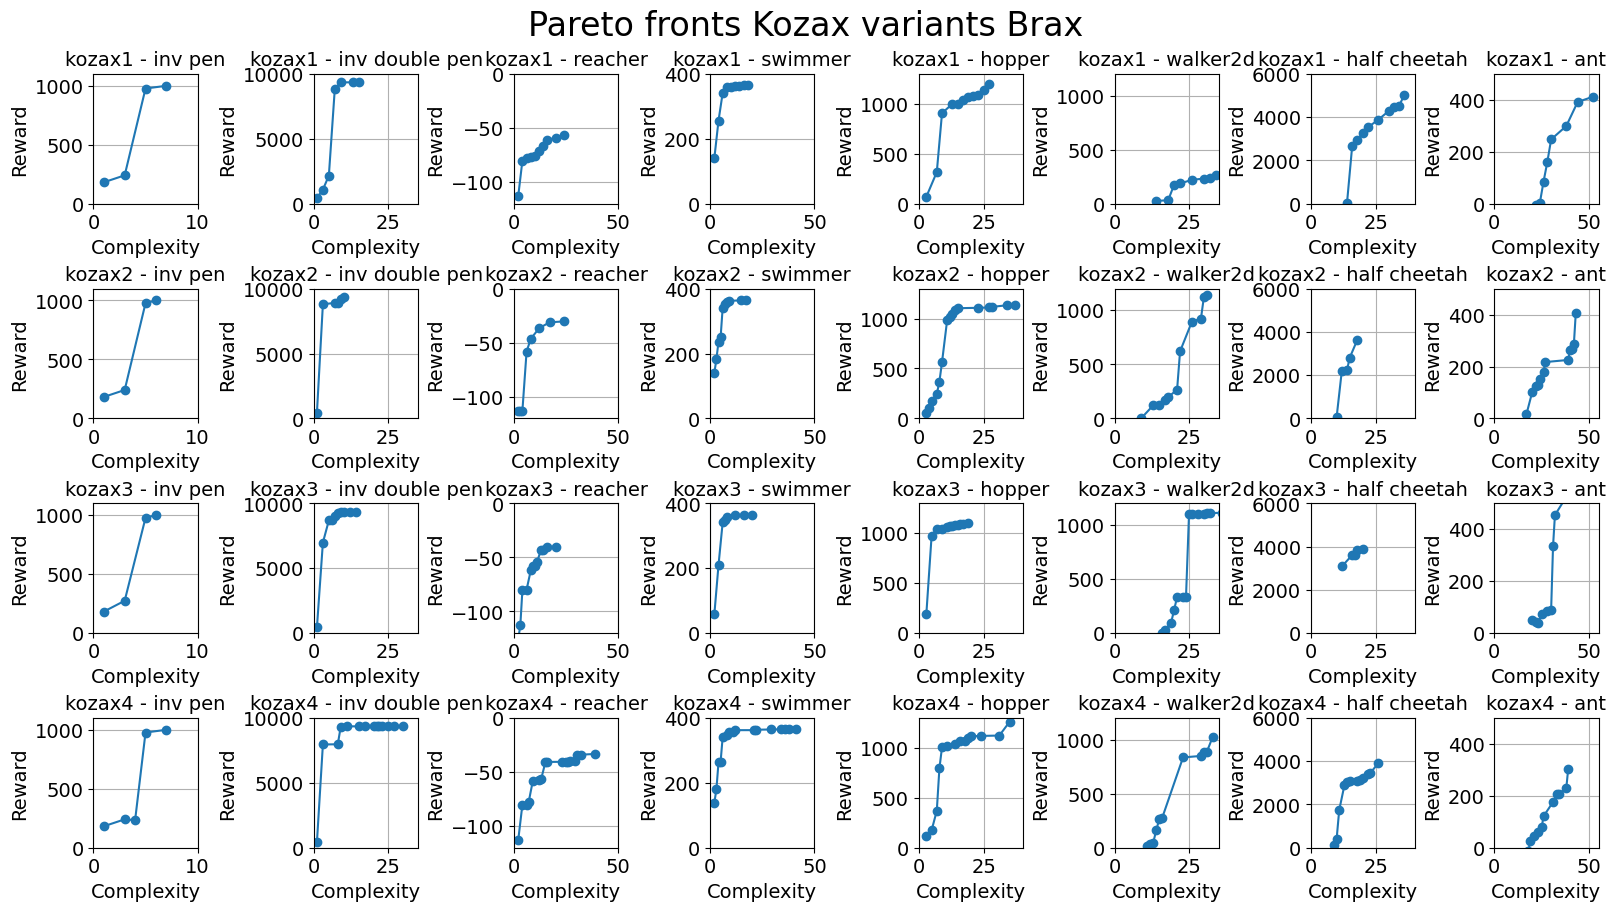

In [6]:
fig, axs = plt.subplots(4, 8, figsize=(16, 9), constrained_layout=True)
fig.suptitle("Pareto fronts Kozax variants Brax", fontsize=24)

xlims = [(0, 10), (0, 35), (0, 50), (0, 50), (0, 40), (0, 35), (0, 40), (0, 55)]
ylims = [(0, 1100), (0, 10_000), (-120, 0), (0, 400), (0, 1300), (0, 1200), (0, 6000), (0, 500)]

env_names = ["inv pen", "inv double pen", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
variant_names = ["kozax1", "kozax2", "kozax3", "kozax4"]

for i, koz in enumerate(all_koz):
    for j, front in enumerate(koz):

        x = [p[0] for p in front]
        y = [p[1] for p in front]

        axs[i, j].plot(x, y, marker='o')
        axs[i, j].set_title(f"{variant_names[i]} - {env_names[j]}", fontsize=14)
        axs[i, j].set_xlabel("Complexity", fontsize=14)
        axs[i, j].set_ylabel("Reward", fontsize=14)
        axs[i, j].set_xlim(xlims[j])
        axs[i, j].set_ylim(ylims[j])
        axs[i, j].tick_params(axis="x", labelsize=14)
        axs[i, j].tick_params(axis="y", labelsize=14)
        axs[i, j].grid()

plt.show()

In [7]:
#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
inv_pen_koz_1 = [664.44, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
inv_double_pen_koz_1 = [824.91, 857.85, 1043.59, 1043.59, 1433.88, 1433.88, 8042.37, 8042.37, 8042.37, 8042.37, 8042.37, 8660.88, 8660.88, 8660.88, 8660.88, 9356.14, 9356.14, 9357.96, 9357.96, 9357.96, 9357.96, 9357.96, 9357.96, 9357.97, 9357.97]
reacher_koz_1 = [-94.50, -83.27, -78.64, -78.64, -78.38, -76.43, -74.24, -70.32, -70.32, -70.31, -70.14, -70.14, -67.24, -67.24, -65.84, -65.84, -65.84, -64.51, -64.51, -59.15, -59.15, -59.15, -56.51, -56.51, -56.51]
swimmer_koz_1 = [173.09, 268.80, 320.90, 347.25, 347.25, 349.73, 349.73, 349.73, 353.99, 353.99, 355.69, 362.65, 362.65, 363.83, 363.83, 363.83, 363.83, 363.83, 363.83, 363.83, 363.84, 363.84, 363.84, 363.84, 365.71]
hopper_koz_1 = [449.27, 501.68, 501.68, 942.02, 1012.90, 1012.91, 1022.56, 1022.87, 1022.87, 1022.88, 1023.05, 1023.20, 1028.91, 1028.91, 1042.11, 1044.07, 1044.07, 1050.58, 1076.41, 1076.41, 1187.22, 1187.22, 1187.22, 1189.02, 1198.30]
walker2d_koz_1 = [51.09, 110.39, 114.09, 150.41, 150.41, 150.41, 179.58, 201.25, 201.25, 210.57, 210.57, 260.62, 260.62, 260.90, 260.90, 260.90, 263.88, 263.88, 263.88, 263.88, 263.88, 263.88, 263.88, 263.88, 263.88]
half_cheetah_koz_1 = [336.10, 414.92, 440.86, 1092.58, 1934.77, 1934.82, 3228.71, 3228.71, 3228.87, 3228.91, 3239.42, 3239.42, 3428.27, 3913.69, 3925.25, 4415.25, 4418.80, 4418.80, 4434.03, 4439.37, 4439.37, 4451.58, 4540.71, 4540.71, 5028.03]
ant_koz_1 = [-221.79, -147.78, -39.10, -39.10, 27.00, 46.28, 61.28, 165.59, 165.59, 165.59, 165.59, 165.59, 167.87, 176.37, 189.58, 189.58, 204.23, 204.23, 271.69, 392.25, 392.25, 392.25, 392.25, 392.25, 412.14]
koz_1 = [inv_pen_koz_1, inv_double_pen_koz_1, reacher_koz_1, swimmer_koz_1, hopper_koz_1, walker2d_koz_1, half_cheetah_koz_1, ant_koz_1]

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
inv_pen_koz_2 = [616.75, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
inv_double_pen_koz_2 = [1074.22, 1074.22, 1074.22, 7522.41, 7522.41, 7522.41, 7522.41, 7522.41, 7522.41, 7522.41, 7963.11, 8804.75, 8804.75, 8907.23, 9207.89, 9207.89, 9207.89, 9207.89, 9207.89, 9356.74, 9356.74, 9356.74, 9356.74, 9356.74, 9357.38]
reacher_koz_2 = [-109.39, -76.81, -76.54, -66.48, -60.83, -45.59, -45.59, -42.86, -42.86, -37.76, -37.76, -37.76, -37.76, -37.76, -36.92, -36.92, -36.24, -36.24, -36.24, -36.24, -34.62, -34.62, -32.01, -32.01, -30.28]
swimmer_koz_2 = [329.11, 329.11, 329.11, 334.79, 353.40, 353.42, 353.44, 353.44, 353.47, 358.50, 358.50, 358.50, 358.50, 358.50, 362.19, 365.32, 365.32, 365.32, 365.32, 365.32, 365.32, 365.32, 365.32, 365.32, 365.32]
hopper_koz_2 = [681.99, 846.53, 1014.93, 1015.45, 1052.15, 1052.19, 1064.96, 1067.35, 1067.35, 1078.50, 1078.50, 1078.50, 1078.50, 1081.67, 1096.71, 1097.80, 1097.80, 1102.86, 1106.36, 1115.77, 1116.47, 1122.08, 1125.96, 1133.90, 1139.76]
walker2d_koz_2 = [140.23, 140.23, 249.12, 249.76, 249.76, 249.76, 249.76, 549.72, 650.56, 710.32, 929.68, 929.68, 929.68, 929.68, 931.75, 932.12, 932.12, 932.52, 932.95, 932.95, 938.57, 938.57, 938.57, 1123.19, 1143.68]
half_cheetah_koz_2 = [231.30, 797.74, 797.74, 797.74, 1858.15, 2746.23, 2998.38, 3214.26, 3214.26, 3214.28, 3214.29, 3214.29, 3214.30, 3214.30, 3267.77, 3267.77, 3267.77, 3267.77, 3363.03, 3405.71, 3405.71, 3585.20, 3585.80, 3643.64, 3646.92]
ant_koz_2 = [-13.14, 4.44, -0.92, -0.92, 29.40, 29.47, 95.65, 95.64, 95.64, 98.97, 124.22, 124.22, 135.67, 155.75, 174.18, 182.94, 257.91, 265.48, 265.48, 316.30, 391.47, 392.01, 392.01, 405.86, 405.86]
koz_2 = [inv_pen_koz_2, inv_double_pen_koz_2, reacher_koz_2, swimmer_koz_2, hopper_koz_2, walker2d_koz_2, half_cheetah_koz_2, ant_koz_2]

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 15)
inv_pen_koz_3 = [256.44, 616.75, 977.0, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
inv_double_pen_koz_3 = [1057.67, 6748.22, 6748.22, 6878.90, 6922.71, 7015.61, 9277.10, 9277.10, 9277.10, 9277.10, 9357.34, 9357.34, 9357.34, 9357.34, 9357.34, 9357.84, 9357.84, 9357.84, 9357.84, 9357.84, 9357.84, 9357.84, 9357.84, 9357.84, 9357.95]
reacher_koz_3 = [-112.83, -94.19, -61.51, -60.10, -60.10, -60.05, -58.34, -58.34, -56.30, -52.79, -51.86, -51.83, -48.18, -42.87, -42.87, -42.87, -42.87, -40.47, -40.47, -40.47, -40.47, -40.47, -40.47, -40.20, -40.20]
swimmer_koz_3 = [329.11, 329.11, 337.18, 337.18, 348.88, 352.18, 352.18, 356.80, 356.80, 357.63, 358.10, 359.78, 361.49, 361.49, 361.49, 361.49, 363.32, 363.32, 363.32, 363.52, 365.45, 365.45, 365.45, 365.45, 365.45]
hopper_koz_3 = [320.53, 482.86, 997.45, 1006.73, 1006.85, 1021.11, 1021.18, 1043.84, 1043.86, 1043.86, 1051.66, 1064.14, 1064.14, 1064.14, 1064.41, 1064.58, 1065.38, 1065.41, 1085.40, 1086.53, 1089.12, 1089.12, 1103.15, 1103.21, 1107.29]
walker2d_koz_3 = [132.32, 161.33, 196.62, 228.06, 228.06, 295.58, 306.32, 324.74, 331.75, 333.80, 339.63, 351.27, 394.65, 427.92, 853.87, 1040.37, 1105.84, 1108.00, 1108.05, 1108.64, 1110.65, 1112.05, 1112.21, 1112.21, 1112.26]
half_cheetah_koz_3 = [383.35, 384.14, 384.14, 615.35, 691.45, 1121.64, 1145.53, 2764.13, 2764.20, 2764.20, 2764.20, 2764.20, 3417.69, 3476.26, 3476.26, 3769.18, 3793.77, 3793.77, 3808.24, 3808.24, 3812.20, 3838.75, 3839.15, 3844.43, 3868.38]
ant_koz_3 = [-169.67, -47.49, -22.92, -22.92, -13.15, 33.70, 33.70, 41.38, 51.84, 78.78, 109.32, 186.01, 333.77, 348.03, 548.68, 610.33, 610.33, 625.81, 718.63, 899.25, 899.25, 909.30, 1003.27, 1003.27, 1003.27]
koz_3 = [inv_pen_koz_3, inv_double_pen_koz_3, reacher_koz_3, swimmer_koz_3, hopper_koz_3, walker2d_koz_3, half_cheetah_koz_3, ant_koz_3]

#Kozax (pop_size = 200, nr_of_gen = 25, operator_list = [+,-,x,%,pow,sin,cos], max_nodes = 31)
inv_pen_koz_4 = [333.88, 442.06, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000, 1000]
inv_double_pen_koz_4 = [7958.78, 7958.78, 7958.78, 7958.78, 7958.78, 7958.78, 7958.78, 9357.86, 9357.86, 9358.22, 9358.22, 9358.30, 9358.35, 9358.35, 9358.57, 9358.57, 9358.77, 9358.81, 9358.81, 9358.81, 9359.01, 9359.01, 9359.01, 9359.08, 9359.08]
reacher_koz_4 = [-112.83, -107.25, -68.60, -68.60, -67.30, -63.41, -63.41, -63.41, -58.10, -58.10, -56.19, -53.51, -53.51, -50.94, -41.00, -41.00, -41.00, -41.00, -40.51, -39.53, -39.53, -39.23, -39.23, -33.99, -33.22]
swimmer_koz_4 = [329.11, 329.11, 329.11, 334.79, 350.99, 351.04, 357.75, 357.75, 358.47, 358.47, 360.03, 360.03, 364.13, 364.13, 366.15, 366.15, 366.15, 366.15, 366.15, 366.15, 366.15, 366.15, 367.13, 367.13, 367.13]
hopper_koz_4 = [320.53, 835.69, 931.72, 962.38, 987.31, 1012.41, 1014.73, 1014.73, 1025.58, 1048.98, 1056.03, 1094.25, 1094.80, 1094.80, 1095.23, 1109.92, 1110.93, 1113.39, 1118.81, 1119.87, 1119.87, 1120.44, 1128.33, 1128.33, 1264.14]
walker2d_koz_4 = [173.13, 173.25, 195.42, 207.82, 207.82, 508.31, 508.31, 515.97, 518.22, 518.22, 519.56, 526.63, 526.63, 588.82, 605.97, 612.31, 629.21, 781.23, 783.84, 856.12, 861.06, 891.82, 898.87, 1027.74, 1027.74]
half_cheetah_koz_4 = [668.47, 668.47, 668.47, 759.66, 1480.87, 1757.12, 2153.86, 2523.79, 2523.79, 2568.53, 3002.82, 3303.23, 3306.03, 3306.03, 3551.55, 3582.43, 3582.43, 3866.07, 3897.32, 3897.32, 3897.32, 3897.32, 3897.32, 3909.11, 3909.11]
ant_koz_4 = [-191.79, -54.36, -28.28, -21.65, -13.27, 17.41, 29.20, 29.20, 29.20, 83.83, 108.48, 154.67, 154.67, 154.67, 166.04, 205.64, 205.64, 205.64, 205.64, 205.64, 205.64, 231.47, 279.93, 279.93, 304.04]
koz_4 = [inv_pen_koz_4, inv_double_pen_koz_4, reacher_koz_4, swimmer_koz_4, hopper_koz_4, walker2d_koz_4, half_cheetah_koz_4, ant_koz_4]

all_koz = [koz_1, koz_2, koz_3, koz_4]

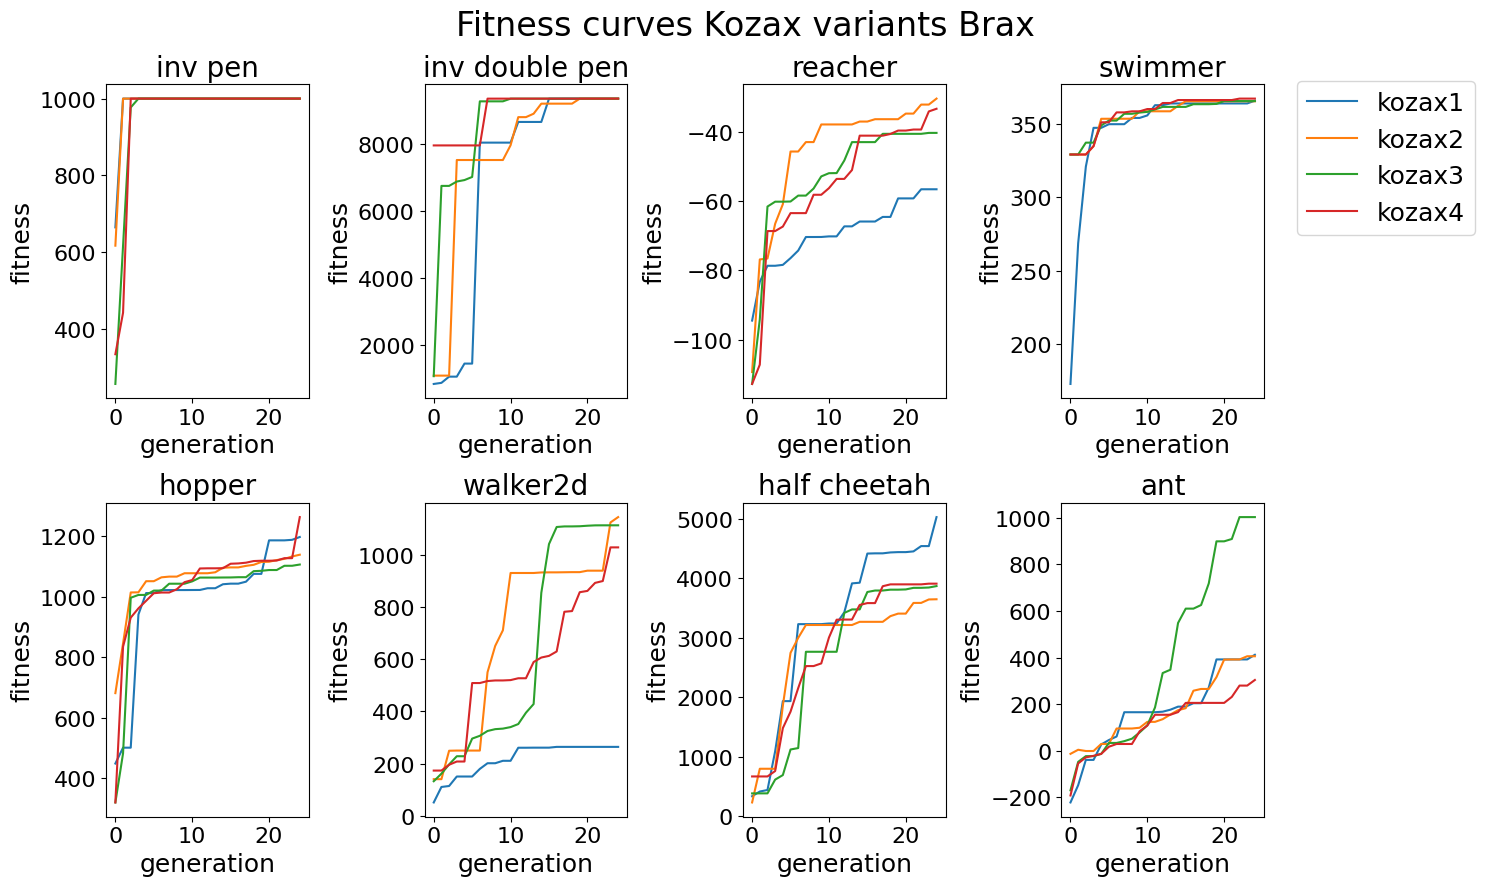

In [8]:
nr_of_cols = 4
nr_of_rows = 2

fig, axs = plt.subplots(nr_of_rows, nr_of_cols, figsize=(15, 9))
fig.suptitle("Fitness curves Kozax variants Brax", fontsize=24)

x_s = jnp.arange(25)
env_names = ["inv pen", "inv double pen", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]

for i, env_name in enumerate(env_names):
  j = int(i / nr_of_cols)
  k = i % nr_of_cols
  axs[j, k].plot(x_s, all_koz[0][i], label = "kozax1")
  axs[j, k].plot(x_s, all_koz[1][i], label = "kozax2")
  axs[j, k].plot(x_s, all_koz[2][i], label = "kozax3")
  axs[j, k].plot(x_s, all_koz[3][i], label = "kozax4")
  axs[j, k].set_title(env_name, fontsize=20)
  axs[j, k].set_xlabel("generation", fontsize=18)
  axs[j, k].set_ylabel("fitness", fontsize=18)
  axs[j, k].tick_params(axis="x", labelsize=16)
  axs[j, k].tick_params(axis="y", labelsize=16)
axs[0, 3].legend(bbox_to_anchor=(1.1, 1.05), fontsize=18)
plt.tight_layout()
plt.show()

## Modi

In [9]:
#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.1, carry_on_method = both)
inv_pen_koz_01 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_01 = jnp.array([9358.409, 9359.675, 9359.508, 9359.096, 9358.557, 7868.482, 9359.284, 9359.688, 9357.397, 9359.496])
reacher_koz_01 = jnp.array([-43.276836, -161.22643, -178.93286, -23.529663, -51.55991, -40.16065, -38.944, -159.24199, -29.36893, -48.24795])
swimmer_koz_01 = jnp.array([359.14072, 362.8725, 363.88358, 363.07492, 338.80704, 363.4162, 362.93494, 361.40332, 362.10257, 339.355])
hopper_koz_01 = jnp.array([1054.7109, 1064.7128, 1071.1763, 1057.982, 1052.8892, 1075.5183, 1064.8328, 1056.217, 1061.9327, 1055.3413])
walker2d_koz_01 = jnp.array([115.35347, 366.87024, 265.8777, 76.2899, 355.57364, 59.872196, 355.5794, 86.88176, 334.68246, 97.281586])
half_cheetah_koz_01 = jnp.array([3849.7468, 3908.5747, 3882.0986, 3907.4744, 3917.168, 3889.424, 3848.914, 3900.609, 3861.642, 3911.3289])
ant_koz_01 = jnp.array([1023.9473, 1122.6729, 1078.6663, 1055.8859, 1030.1185, 1072.3279, 1051.9048, 1121.7212, 1134.4824, 1125.8882])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.3, carry_on_method = both)
inv_pen_koz = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz = jnp.array([9358.205, 9359.394, 9359.021, 9358.735, 9358.339, 9355.937, 9359.061, 9359.48, 9358.334, 9358.899])
reacher_koz = jnp.array([-47.342804, -76.17395, -102.334015, -48.559208, -112.55008, -68.836975, -51.741783, -67.5976, -108.94585, -48.315815])
swimmer_koz = jnp.array([362.05035, 363.85745, 364.71753, 365.4873, 364.57602, 364.68008, 363.04663, 363.687, 363.65063, 364.20834])
hopper_koz = jnp.array([1038.2855, 1001.81683, 1008.4778, 1061.9589, 1019.2018, 1007.24585, 926.83453, 1357.0073, 1031.7102, 1051.4977])
walker2d_koz = jnp.array([303.3918, 313.9658, 288.94617, 189.48434, 154.26135, 306.30945, 306.00058, 297.9052, 266.7031, 153.96793])
half_cheetah_koz = jnp.array([3355.5647, 3413.357, 3388.3813, 3443.1604, 3380.401, 3435.9495, 3381.419, 3406.6729, 3397.991, 3422.9866])
ant_koz = jnp.array([1134.8474, 214.03435, 1152.4371, 71.25823, 1046.7189, 980.5063, 1049.9897, 1133.0228, 1072.5364, 1009.8362])

# #Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
# inv_pen_koz_31 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_koz_31 = jnp.array([9358.409, 9359.497, 9359.231, 9358.931, 9358.449, 8758.594, 9359.218, 9359.567, 9357.733, 9359.115])
# reacher_koz_31 = jnp.array([-71.797585, -76.50382, -66.14164, -70.157585, -39.103134, -73.39729, -54.12071, -61.12878, -113.0095, -67.93172])
# swimmer_koz_31 = jnp.array([359.1305, 360.94162, 362.3107, 362.69046, 363.15396, 362.32727, 358.91922, 361.68344, 360.05637, 362.15866])
# hopper_koz_31 = jnp.array([1094.5725, 1098.8917, 1093.7343, 1071.841, 1084.0002, 1110.2927, 1102.1447, 1114.1674, 1106.1766, 1075.1117])
# walker2d_koz_31 = jnp.array([929.30994, 432.62476, 315.85483, 342.56406, 60.307526, 435.46625, 348.97125, 331.79358, 306.8846, 96.40559])
# half_cheetah_koz_31 = jnp.array([4424.6855, 4716.041, 4410.9536, 4738.696, 4643.1235, 4689.689, 4703.8403, 4425.2197, 4384.572, 4481.4746])
# ant_koz_31 = jnp.array([992.12177, 1167.897, 873.16455, 1186.7295, 1181.0555, 1102.4985, 1084.6112, 1200.6146, 985.7667, 1012.2176])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.5, carry_on_method = both)
inv_pen_koz_05 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_05 = jnp.array([9357.726, 9359.676, 9359.482, 9359.203, 9358.589, 9349.977, 9359.356, 9359.698, 9357.703, 9359.465])
reacher_koz_05 = jnp.array([-41.835274, -152.86887, -165.28587, -23.536903, -41.937756, -39.8673, -39.337242, -153.03262, -28.142065, -34.870316])
swimmer_koz_05 = jnp.array([364.2526, 366.76068, 366.1773, 367.8567, 367.43143, 366.79132, 365.2317, 367.01535, 365.89902, 366.83383])
hopper_koz_05 = jnp.array([1107.7516, 1155.9347, 1121.0009, 1053.6785, 1103.5032, 1136.344, 1149.3889, 1053.3938, 1160.8887, 1164.2938])
walker2d_koz_05 = jnp.array([142.89697, 480.72864, 180.11876, 73.70694, 655.6268, 41.941048, 512.1357, 72.177734, 261.12225, 429.6995])
half_cheetah_koz_05 = jnp.array([3754.6816, 3789.1138, 3752.768, 3808.3406, 3817.1445, 3778.101, 3785.0857, 3792.0737, 3731.0854, 3790.534])
ant_koz_05 = jnp.array([1120.611, 1138.6074, 1016.56696, 1114.9111, 1127.9413, 1132.9961, 1014.7657, 1123.9764, 1000.22156, 1119.5923])

# #Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.3, carry_on_method = right)
# inv_pen_koz_right = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_koz_right = jnp.array([9357.7705, 9359.582, 9359.359, 9358.858, 9358.474, 9352.969, 9359.155, 9359.605, 9358.051, 9359.337])
# reacher_koz_right = jnp.array([-152.32224, -135.46692, -146.05956, -169.25555, -192.98155, -35.29763, -49.130363, -138.72195, -27.973225, -196.63495])
# swimmer_koz_right = jnp.array([360.7939, 366.32343, 366.3811, 362.89465, 362.2785, 362.35828, 359.73984, 361.0279, 361.36554, 366.67416])
# hopper_koz_right = jnp.array([1220.8702, 1030.2891, 1151.6022, 1168.3066, 1043.909, 1105.6702, 1022.5662, 1226.0515, 1252.5488, 1114.1125])
# walker2d_koz_right = jnp.array([353.59134, 309.0358, 124.74884, 366.88916, 172.05125, 261.1611, 280.50687, 246.72125, 291.4999, 278.85364])
# half_cheetah_koz_right = jnp.array([3909.4558, 3923.4468, 3939.5635, 3935.5205, 3966.8486, 3914.4917, 3878.2104, 3935.1865, 3871.9915, 3934.2383])
# ant_koz_right = jnp.array([1089.702, 1085.7938, 1055.2452, 998.36816, 1025.9331, 991.6496, 990.5235, 44.4008, 1011.9478, 1016.64514])

# #Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = right)
# inv_pen_koz_right_31 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_koz_right_31 = jnp.array([9358.209, 9359.943, 9359.716, 9359.544, 9358.119, 9357.143, 9359.291, 9359.777, 9358.226, 9359.806])
# reacher_koz_right_31 = jnp.array([-35.735065, -49.669582, -36.397686, -34.37678, -97.07439, -48.99712, -45.98899, -41.0545, -81.18262, -36.757267])
# swimmer_koz_right_31 = jnp.array([361.31213, 366.51425, 366.30804, 367.19482, 366.84515, 366.6272, 364.7911, 365.83102, 363.79767, 366.49066])
# hopper_koz_right_31 = jnp.array([1061.6517, 1061.4204, 1060.8208, 1060.238, 1063.3364, 1059.871, 1063.6476, 1063.2897, 1060.6854, 1060.931])
# walker2d_koz_right_31 = jnp.array([42.77537, 557.1118, 512.9777, 57.261, 564.2915, 67.79653, 572.3944, 80.214645, 473.55563, 163.92967])
# half_cheetah_koz_right_31 = jnp.array([4238.1504, 4266.0776, 4240.239, 4263.8716, 4308.486, 4218.943, 4226.9014, 4268.3022, 4210.98, 4248.501])
# ant_koz_right_31 = jnp.array([217.99266, 761.60626, 988.0469, 289.83636, 945.60736, 698.17505, 455.7607, 1097.4751, 1032.7646, 991.0273])

inv_pen_results = [inv_pen_koz_01, inv_pen_koz, inv_pen_koz_05]
inv_double_pen_results = [inv_double_pen_koz_01, inv_double_pen_koz, inv_double_pen_koz_05]
reacher_results = [reacher_koz_01, reacher_koz, reacher_koz_05]
swimmer_results = [swimmer_koz_01, swimmer_koz, swimmer_koz_05]
hopper_results = [hopper_koz_01, hopper_koz, hopper_koz_05]
walker2d_results = [walker2d_koz_01, walker2d_koz, walker2d_koz_05]
half_cheetah_results = [half_cheetah_koz_01, half_cheetah_koz, half_cheetah_koz_05]
ant_results = [ant_koz_01, ant_koz, ant_koz_05]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

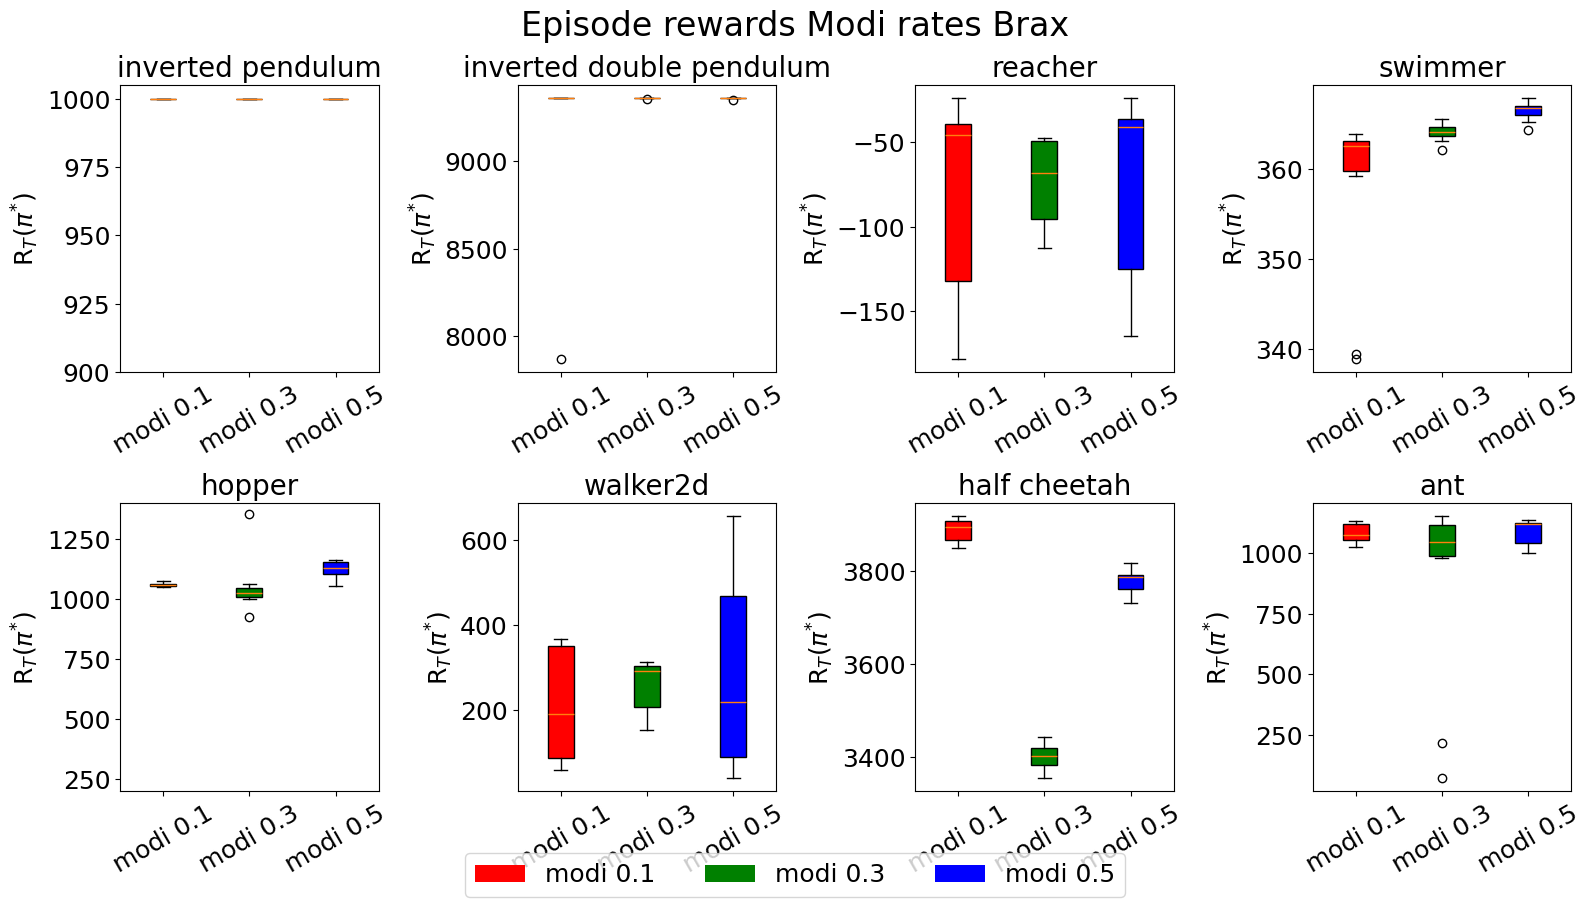

In [10]:
from matplotlib.patches import Patch

nrows = 2
ncols = 4
plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
colors = ["red", "green", "blue"]
tick_labels = ["modi 0.1", "modi 0.3", "modi 0.5"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards Modi rates Brax", fontsize=24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize=20)
    if plot_titles[idx] == "inverted pendulum":
      axs[i,j].set_ylim((900, 1005))
    if plot_titles[idx] == "hopper":
      axs[i,j].set_ylim((200, 1400))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize=18)
    axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize=18)
    axs[i,j].tick_params(axis="y", labelsize=18)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=18
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

In [11]:
#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.3, carry_on_method = both)
inv_pen_koz = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz = jnp.array([9358.205, 9359.394, 9359.021, 9358.735, 9358.339, 9355.937, 9359.061, 9359.48, 9358.334, 9358.899])
reacher_koz = jnp.array([-47.342804, -76.17395, -102.334015, -48.559208, -112.55008, -68.836975, -51.741783, -67.5976, -108.94585, -48.315815])
swimmer_koz = jnp.array([362.05035, 363.85745, 364.71753, 365.4873, 364.57602, 364.68008, 363.04663, 363.687, 363.65063, 364.20834])
hopper_koz = jnp.array([1038.2855, 1001.81683, 1008.4778, 1061.9589, 1019.2018, 1007.24585, 926.83453, 1357.0073, 1031.7102, 1051.4977])
walker2d_koz = jnp.array([303.3918, 313.9658, 288.94617, 189.48434, 154.26135, 306.30945, 306.00058, 297.9052, 266.7031, 153.96793])
half_cheetah_koz = jnp.array([3355.5647, 3413.357, 3388.3813, 3443.1604, 3380.401, 3435.9495, 3381.419, 3406.6729, 3397.991, 3422.9866])
ant_koz = jnp.array([1134.8474, 214.03435, 1152.4371, 71.25823, 1046.7189, 980.5063, 1049.9897, 1133.0228, 1072.5364, 1009.8362])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_koz_31 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_31 = jnp.array([9358.409, 9359.497, 9359.231, 9358.931, 9358.449, 8758.594, 9359.218, 9359.567, 9357.733, 9359.115])
reacher_koz_31 = jnp.array([-71.797585, -76.50382, -66.14164, -70.157585, -39.103134, -73.39729, -54.12071, -61.12878, -113.0095, -67.93172])
swimmer_koz_31 = jnp.array([359.1305, 360.94162, 362.3107, 362.69046, 363.15396, 362.32727, 358.91922, 361.68344, 360.05637, 362.15866])
hopper_koz_31 = jnp.array([1094.5725, 1098.8917, 1093.7343, 1071.841, 1084.0002, 1110.2927, 1102.1447, 1114.1674, 1106.1766, 1075.1117])
walker2d_koz_31 = jnp.array([929.30994, 432.62476, 315.85483, 342.56406, 60.307526, 435.46625, 348.97125, 331.79358, 306.8846, 96.40559])
half_cheetah_koz_31 = jnp.array([4424.6855, 4716.041, 4410.9536, 4738.696, 4643.1235, 4689.689, 4703.8403, 4425.2197, 4384.572, 4481.4746])
ant_koz_31 = jnp.array([992.12177, 1167.897, 873.16455, 1186.7295, 1181.0555, 1102.4985, 1084.6112, 1200.6146, 985.7667, 1012.2176])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.5, carry_on_method = both)
inv_pen_koz_05 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_05 = jnp.array([9357.726, 9359.676, 9359.482, 9359.203, 9358.589, 9349.977, 9359.356, 9359.698, 9357.703, 9359.465])
reacher_koz_05 = jnp.array([-41.835274, -152.86887, -165.28587, -23.536903, -41.937756, -39.8673, -39.337242, -153.03262, -28.142065, -34.870316])
swimmer_koz_05 = jnp.array([364.2526, 366.76068, 366.1773, 367.8567, 367.43143, 366.79132, 365.2317, 367.01535, 365.89902, 366.83383])
hopper_koz_05 = jnp.array([1107.7516, 1155.9347, 1121.0009, 1053.6785, 1103.5032, 1136.344, 1149.3889, 1053.3938, 1160.8887, 1164.2938])
walker2d_koz_05 = jnp.array([142.89697, 480.72864, 180.11876, 73.70694, 655.6268, 41.941048, 512.1357, 72.177734, 261.12225, 429.6995])
half_cheetah_koz_05 = jnp.array([3754.6816, 3789.1138, 3752.768, 3808.3406, 3817.1445, 3778.101, 3785.0857, 3792.0737, 3731.0854, 3790.534])
ant_koz_05 = jnp.array([1120.611, 1138.6074, 1016.56696, 1114.9111, 1127.9413, 1132.9961, 1014.7657, 1123.9764, 1000.22156, 1119.5923])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.5, carry_on_method = both)
inv_pen_koz_05_31 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_05_31 = jnp.array([9359.158, 9359.453, 9359.391, 9359.135, 9358.949, 9358.576, 9359.452, 9359.417, 9359.394, 9359.4])
reacher_koz_05_31 = jnp.array([-39.72755, -16.614042, -19.623846, -42.80767, -43.005592, -68.6426, -54.335564, -9.836964, -119.168594, -35.927315])
swimmer_koz_05_31 = jnp.array([362.25424, 360.53094, 366.18625, 362.68225, 365.82697, 365.79086, 360.5978, 360.56937, 364.79016, 364.6697])
hopper_koz_05_31 = jnp.array([1188.1772, 1204.0989, 1193.0215, 1116.0194, 1168.4097, 1160.8026, 1187.1567, 1150.0044, 1213.0109, 1136.2396])
walker2d_koz_05_31 = jnp.array([1027.125, 1661.5126, 866.80426, 593.0974, 840.0624, 1552.9336, 1504.2971, 609.9359, 1600.6606, 555.2125])
half_cheetah_koz_05_31 = jnp.array([4523.558, 4430.1865, 4526.424, 4444.7734, 4626.186, 4457.6504, 4505.113, 4471.725, 4467.7075, 4521.5083])
ant_koz_05_31 = jnp.array([1174.334, 1213.3641, 1054.9786, 1188.9072, 473.16135, 912.6757, 1029.1942, 1156.1122, 1097.0897, 1175.7594])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.3, carry_on_method = right)
inv_pen_koz_right = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_right = jnp.array([9357.7705, 9359.582, 9359.359, 9358.858, 9358.474, 9352.969, 9359.155, 9359.605, 9358.051, 9359.337])
reacher_koz_right = jnp.array([-152.32224, -135.46692, -146.05956, -169.25555, -192.98155, -35.29763, -49.130363, -138.72195, -27.973225, -196.63495])
swimmer_koz_right = jnp.array([360.7939, 366.32343, 366.3811, 362.89465, 362.2785, 362.35828, 359.73984, 361.0279, 361.36554, 366.67416])
hopper_koz_right = jnp.array([1220.8702, 1030.2891, 1151.6022, 1168.3066, 1043.909, 1105.6702, 1022.5662, 1226.0515, 1252.5488, 1114.1125])
# walker2d_koz_right = jnp.array([353.59134, 309.0358, 124.74884, 366.88916, 172.05125, 261.1611, 280.50687, 246.72125, 291.4999, 278.85364])
# half_cheetah_koz_right = jnp.array([3909.4558, 3923.4468, 3939.5635, 3935.5205, 3966.8486, 3914.4917, 3878.2104, 3935.1865, 3871.9915, 3934.2383])
# ant_koz_right = jnp.array([1089.702, 1085.7938, 1055.2452, 998.36816, 1025.9331, 991.6496, 990.5235, 44.4008, 1011.9478, 1016.64514])
walker2d_koz_right = jnp.array([351.9599, 323.6598, 322.81702, 384.50708, 376.3048, 339.063, 298.20477, 364.29202, 362.36548, 349.62885])
half_cheetah_koz_right = jnp.array([4055.0898, 4090.2654, 4079.7158, 4083.647, 4135.5156, 4051.7932, 4056.6106, 4079.8608, 4061.3328, 4082.0664])
ant_koz_right = jnp.array([1009.1226, 1145.101, 1123.4193, 1005.03864, 1163.4454, 1131.1194, 1155.1284, 963.7276, 1019.0955, 1109.095])

#Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = right)
inv_pen_koz_right_31 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_right_31 = jnp.array([9358.209, 9359.943, 9359.716, 9359.544, 9358.119, 9357.143, 9359.291, 9359.777, 9358.226, 9359.806])
reacher_koz_right_31 = jnp.array([-35.735065, -49.669582, -36.397686, -34.37678, -97.07439, -48.99712, -45.98899, -41.0545, -81.18262, -36.757267])
swimmer_koz_right_31 = jnp.array([361.31213, 366.51425, 366.30804, 367.19482, 366.84515, 366.6272, 364.7911, 365.83102, 363.79767, 366.49066])
hopper_koz_right_31 = jnp.array([1061.6517, 1061.4204, 1060.8208, 1060.238, 1063.3364, 1059.871, 1063.6476, 1063.2897, 1060.6854, 1060.931])
# walker2d_koz_right_31 = jnp.array([42.77537, 557.1118, 512.9777, 57.261, 564.2915, 67.79653, 572.3944, 80.214645, 473.55563, 163.92967])
# half_cheetah_koz_right_31 = jnp.array([4238.1504, 4266.0776, 4240.239, 4263.8716, 4308.486, 4218.943, 4226.9014, 4268.3022, 4210.98, 4248.501])
# ant_koz_right_31 = jnp.array([217.99266, 761.60626, 988.0469, 289.83636, 945.60736, 698.17505, 455.7607, 1097.4751, 1032.7646, 991.0273])
walker2d_koz_right_31 = jnp.array([100.660324, 310.94043, 268.88815, 206.74333, 370.84518, 359.04987, 286.06335, 93.37104, 316.8145, 296.41766])
half_cheetah_koz_right_31 = jnp.array([4654.2993, 4579.5107, 4515.788, 4584.813, 4606.2446, 4524.1436, 4536.881, 4641.96, 4531.5825, 4509.38])
ant_koz_right_31 = jnp.array([1037.6927, 1128.9384, 1112.067, 173.33104, 1141.4677, 1132.2037, 1044.9579, 1104.1135, 1010.1063, 1106.8324])

inv_pen_results = [inv_pen_koz, inv_pen_koz_31, inv_pen_koz_05, inv_pen_koz_05_31, inv_pen_koz_right, inv_pen_koz_right_31]
inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_koz_31, inv_double_pen_koz_05, inv_double_pen_koz_05_31, inv_double_pen_koz_right, inv_double_pen_koz_right_31]
reacher_results = [reacher_koz, reacher_koz_31, reacher_koz_05, reacher_koz_05_31, reacher_koz_right, reacher_koz_right_31]
swimmer_results = [swimmer_koz, swimmer_koz_31, swimmer_koz_05, swimmer_koz_05_31, swimmer_koz_right, swimmer_koz_right_31]
hopper_results = [hopper_koz, hopper_koz_31, hopper_koz_05, hopper_koz_05_31, hopper_koz_right, hopper_koz_right_31]
walker2d_results = [walker2d_koz, walker2d_koz_31, walker2d_koz_05, walker2d_koz_05_31, walker2d_koz_right, walker2d_koz_right_31]
half_cheetah_results = [half_cheetah_koz, half_cheetah_koz_31, half_cheetah_koz_05, half_cheetah_koz_05_31, half_cheetah_koz_right, half_cheetah_koz_right_31]
ant_results = [ant_koz, ant_koz_31, ant_koz_05, ant_koz_05_31, ant_koz_right, ant_koz_right_31]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

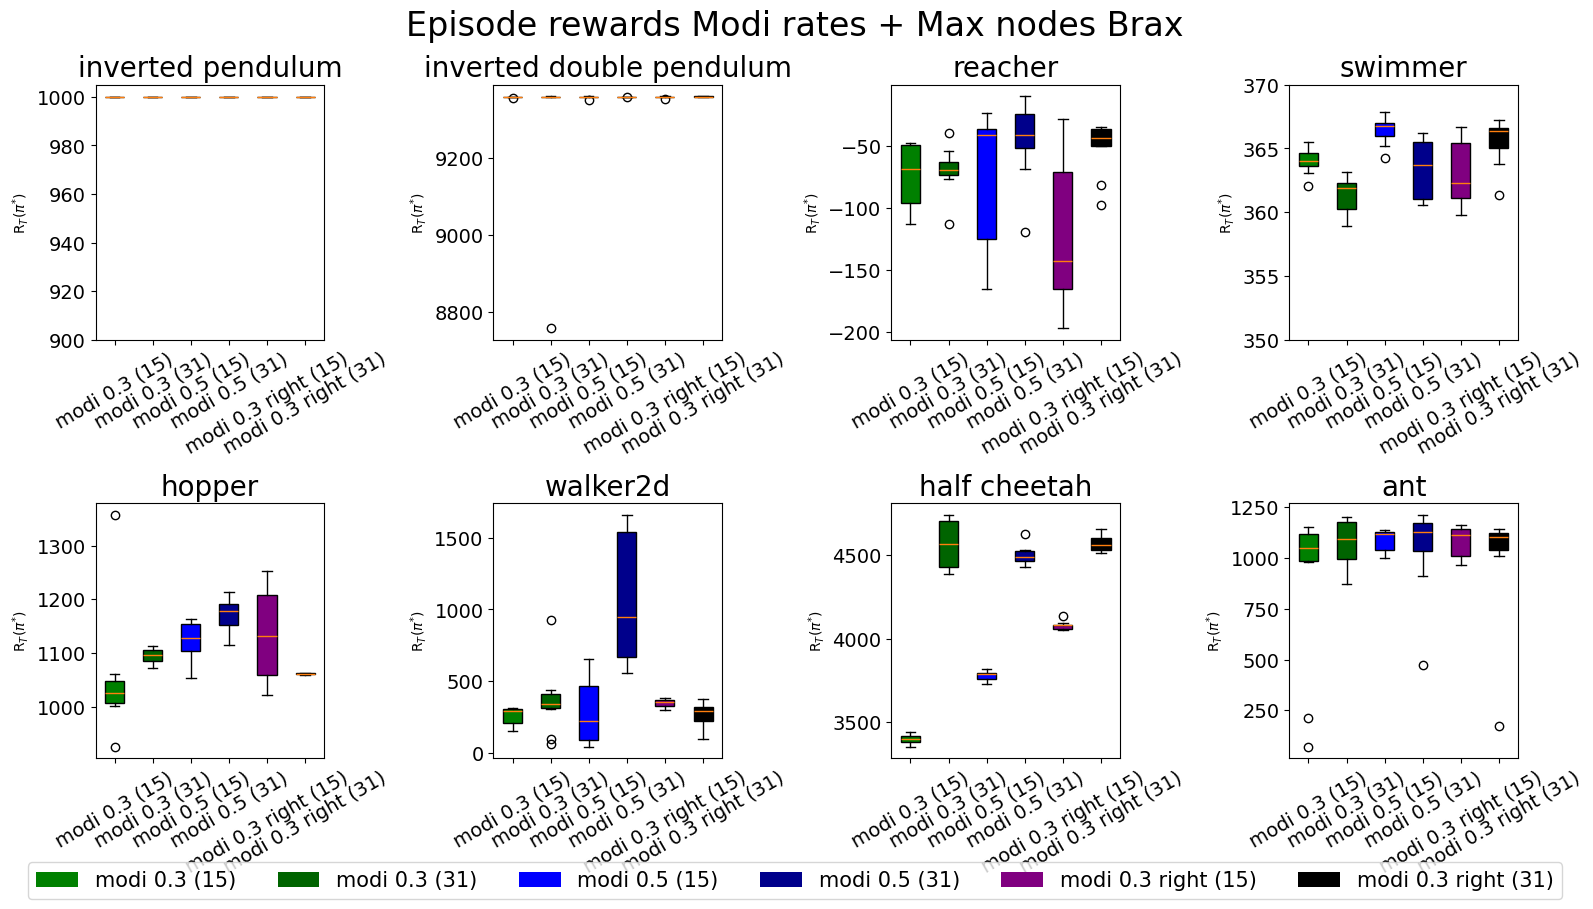

In [12]:
from matplotlib.patches import Patch

nrows = 2
ncols = 4
plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
colors = ["green", "darkgreen", "blue", "darkblue", "purple", "black"]
tick_labels = ["modi 0.3 (15)", "modi 0.3 (31)", "modi 0.5 (15)", "modi 0.5 (31)", "modi 0.3 right (15)", "modi 0.3 right (31)"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards Modi rates + Max nodes Brax", fontsize=24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize=20)
    if plot_titles[idx] == "inverted pendulum":
      axs[i,j].set_ylim((900, 1005))
    if plot_titles[idx] == "swimmer":
      axs[i,j].set_ylim((350, 370))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)")
    axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize=14)
    axs[i,j].tick_params(axis="y", labelsize=14)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15
)
plt.tight_layout()

## Full baseline comparison

In [13]:
# #Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
# inv_pen_koz = jnp.array([1000., 1000., 1000.,  620., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_koz = jnp.array([9354.579, 9359.588, 9358.889, 9357.842, 9356.544, 8376.444, 9358.368, 9359.737, 9355.103, 9358.697])
# reacher_koz = jnp.array([-76.42881, -11.442436, -9.734155, -125.53045, -17.742325, -28.035576, -31.190842, -10.783359, -35.829453, -80.139626])
# swimmer_koz = jnp.array([361.54105, 366.2345, 366.5612, 367.1253, 365.09348, 366.06464, 365.34174, 366.00275, 364.85516, 365.8025])
# hopper_koz = jnp.array([1164.8481, 1118.759, 1139.3821, 1156.9786, 1118.4917, 1158.2399, 1129.1803, 1127.7664, 1161.3081, 1149.5365])
# walker2d_koz = jnp.array([1141.0729, 1142.9606, 1142.7114, 1144.0468, 1147.3556, 1136.5703, 1144.5051, 1145.0028, 1137.4034, 1144.1232]) # max_nodes = 7
# half_cheetah_koz = jnp.array([3633.6216, 3644.07, 3621.1821, 3655.7021, 3685.6287, 3616.2817, 3623.5586, 3650.5955, 3621.121, 3648.761 ]) # max_nodes = 7
# ant_koz = jnp.array([917.4532, 105.59323, 221.99437, 571.84125, 146.73146, 336.20676, 760.23267, 67.42464, 254.5915, 10.293206]) # max_nodes = 7

# #Modi Kozax (pop_size = 5x100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
# inv_pen_modi = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_modi = jnp.array([9355.8545, 9359.465, 9358.972, 9357.854, 9356.783, 9350.944, 9358.734, 9359.593, 9355.387, 9358.907])
# reacher_modi = jnp.array([-175.19783, -63.13835, -37.02901, -180.53899, -57.421474, -28.747427, -33.05677, -56.196613, -43.199436, -203.85191])
# swimmer_modi = jnp.array([356.5535, 362.9277, 364.44666, 363.63202, 359.30313, 363.15305, 361.96964, 362.48068, 361.0248, 355.5801])
# hopper_modi = jnp.array([984.09064, 1094.1439, 1131.451, 1117.8174, 1077.4199, 1162.1007, 1105.1051, 955.29395, 1085.3868, 1023.7265])
# walker2d_modi = jnp.array([153.24753, 297.67093, 298.46902, 341.44586, 370.54337, 262.10083, 278.31628, 314.96555, 289.04016, 226.69106])
# half_cheetah_modi = jnp.array([4578.9385, 4324.202, 4306.3193, 4341.361, 4345.3438, 4318.327, 4390.781, 4281.847, 4272.643, 4597.422])
# ant_modi = jnp.array([1111.7856, 57.949547, 1156.3043, 987.65015, 1154.1079, 1156.6812, 1140.5776, 1144.268, 1040.0242, 1154.5076])

# #Modi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15, modi_rate = 0.3, carry_on_method = both)
# inv_pen_modi = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_modi = jnp.array([9358.205, 9359.394, 9359.021, 9358.735, 9358.339, 9355.937, 9359.061, 9359.48, 9358.334, 9358.899])
# reacher_modi = jnp.array([-47.342804, -76.17395, -102.334015, -48.559208, -112.55008, -68.836975, -51.741783, -67.5976, -108.94585, -48.315815])
# swimmer_modi = jnp.array([362.05035, 363.85745, 364.71753, 365.4873, 364.57602, 364.68008, 363.04663, 363.687, 363.65063, 364.20834])
# hopper_modi = jnp.array([1038.2855, 1001.81683, 1008.4778, 1061.9589, 1019.2018, 1007.24585, 926.83453, 1357.0073, 1031.7102, 1051.4977])
# walker2d_modi = jnp.array([303.3918, 313.9658, 288.94617, 189.48434, 154.26135, 306.30945, 306.00058, 297.9052, 266.7031, 153.96793])
# half_cheetah_modi = jnp.array([3355.5647, 3413.357, 3388.3813, 3443.1604, 3380.401, 3435.9495, 3381.419, 3406.6729, 3397.991, 3422.9866])
# ant_modi = jnp.array([1134.8474, 214.03435, 1152.4371, 71.25823, 1046.7189, 980.5063, 1049.9897, 1133.0228, 1072.5364, 1009.8362])

# #CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

# inv_pen_cgpax = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_cgpax = jnp.array([6085.7686, 9352.39, 7519.252, 8480.27, 6468.175, 5534.562, 7947.753, 9356.813, 6077.8467, 6985.178])
# reacher_cgpax = jnp.array([-39.922165, -49.821873, -60.0979, -18.984558, -196.48444, -95.03198, -85.89033, -64.415504, -143.82385, -35.902977])
# swimmer_cgpax = jnp.array([340.49014, 354.60565, 357.7974, 356.29767, 332.6057, 343.8158, 355.68326, 350.99344, 350.90198, 356.40247])
# hopper_cgpax = jnp.array([1095.3315, 1113.9839, 1087.3208, 1162.5234, 1101.0757, 1126.1235, 1115.9884, 1135.301, 1101.0874, 1095.2422])
# walker2d_cgpax = jnp.array([1006.7979, 998.26044, 186.08589, 1002.9979, 1002.74066, 199.45091, 199.19106, 1005.68115, 188.41426, 998.5209])
# half_cheetah_cgpax = jnp.array([2996.433, 2989.0247, 2931.519, 2966.6746, 2851.7498, 2970.5422, 2968.7727, 3031.474, 2988.5461, 2880.8806])
# ant_cgpax = jnp.array([480.9499, 975.9896, 158.4743, 146.41995, 931.418, 1125.1726, 638.22107, 1233.552, 652.7863, 6.751278])

# #CGPAX seed 0 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_1 = jnp.array([327., 286., 302., 255., 317., 756., 871., 369., 800., 830.])
# inv_double_pen_cgpax_1 = jnp.array([6085.769, 9352.39, 7519.252, 8480.269, 6468.176, 5534.562, 7947.753, 9356.814, 6077.847, 6985.178])
# reacher_cgpax_1 = jnp.array([-7.4905834, -163.55624, -184.84052, -15.100983, -253.42589, -94.9962, -70.69127, -175.25826, -151.07886, -30.723774])
# swimmer_cgpax_1 = jnp.array([-83.04826, -88.872894, 290.13858, -86.28288, 281.96912, 290.61572, 270.7681, -89.37675, 290.27258, 289.76736])
# hopper_cgpax_1 = jnp.array([1065.0084, 908.15247, 975.2533, 1074.8286, 1078.4054, 1064.7007, 1105.2708, 842.52515, 1050.9861, 984.34064])
# walker2d_cgpax_1 = jnp.array([476.44366, 297.28305, 184.7797, 580.2114, 485.383, 243.22278, 180.2444, 479.88785, 249.75342, 709.9433])
# half_cheetah_cgpax_1 = jnp.array([580.0425, 560.63776, 576.0425, 565.81964, 583.5791, 544.6001, 543.2681, 596.8219, 583.0479, 598.6538])
# ant_cgpax_1 = jnp.array([50.75792, 6.551172, 949.8468, 1286.7367, 9.833655, 4.799202, 1378.0898, 833.31647, 1215.5165, 13.6646805])

# #CGPAX seed 26 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_2 = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
# inv_double_pen_cgpax_2 = jnp.array([1044.9553, 1503.5643, 1437.9645, 1568.8003, 1016.30304, 1044.8029, 1640.746, 1456.9756, 1363.4429, 1006.9472])
# reacher_cgpax_2 = jnp.array([-52.020493, -169.55801, -152.3594, -57.278828, -104.88697, -67.94385, -48.766273, -176.55815, -110.21392, -14.164314])
# swimmer_cgpax_2 = jnp.array([363.89423, 364.96524, 366.26532, 365.95493, 367.21057, 366.97, 362.46048, 365.31403, 364.1156, 366.5797])
# hopper_cgpax_2 = jnp.array([825.0731, 1072.1655, 822.0334, 1062.8568, 824.7747, 1069.6842, 1003.4234, 1051.3003, 807.047, 867.9057])
# walker2d_cgpax_2 = jnp.array([289.4038, 280.1455, 256.0286, 290.58295, 288.66913, 269.15347, 262.44696, 286.61493, 255.7673, 291.05807])
# half_cheetah_cgpax_2 = jnp.array([2755.5637, 2661.911, 2893.0732, 2802.624, 2621.4885, 2825.1545, 2462.8484, 2595.2903, 2911.7817, 2358.1855])
# ant_cgpax_2 = jnp.array([474.25043, 535.41016, 509.94208, 8.219259, 4.738791, -2.3205132, 529.02094, 496.2157, 497.80035, 526.80493])

# #CGPAX seed 10 (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x], max_nodes = 15)
# inv_pen_cgpax_3 = jnp.array([1000., 1000., 1000.,  619., 1000., 1000., 844., 1000., 1000., 1000.])
# inv_double_pen_cgpax_3 = jnp.array([9355.65, 9358.7295, 9358.095, 9357.979, 9356.994, 9355.965, 9358.791, 9358.988, 9358.201, 9357.607])
# reacher_cgpax_3 = jnp.array([-59.30034, -42.06773, -35.455994, -59.454384, -275.2382, -98.774536, -74.93168, -30.89294, -151.66763, -27.037868])
# swimmer_cgpax_3 = jnp.array([354.68875, 355.18967, 360.3561, 360.3968, 355.34338, 357.10434, 353.88812, 358.06656, 352.87103, 353.88028])
# hopper_cgpax_3 = jnp.array([1062.6826, 1069.1431, 1066.7932, 1061.0326, 1059.439, 1068.8335, 1063.7628, 1061.562, 1064.9453, 1061.7975])
# walker2d_cgpax_3 = jnp.array([107.38916, 204.52266, 298.34244, 316.10608, 288.2991, 209.57796, 279.2315, 120.26227, 21.290922, 238.33588])
# half_cheetah_cgpax_3 = jnp.array([-128.7229, -655.4468, -364.5511, -205.94751, -96.49075, -350.7605, -257.85593, -19.034502, -51.94186, -164.36374 ])
# ant_cgpax_3 = jnp.array([383.82178, 979.60376, 1119.153, 998.07886, 366.9502, 1094.5615, 763.23236, 666.5521, 941.32227, 1009.0104])

# #PPO ()
# inv_pen_ppo = jnp.array([1000, 1000, 1000])
# inv_double_pen_ppo =  jnp.array([9359.55, 2233.88, 7846.11])
# reacher_ppo = jnp.array([-8.57, -7.47, -8.19])
# swimmer_ppo = jnp.array([41.43, 32.11, 38.10])
# hopper_ppo =  jnp.array([662.54, 362.60, 333.84])
# walker2d_ppo =  jnp.array([1039.15, 608.69, 1129.97])
# half_cheetah_ppo =  jnp.array([15637.27, 10508.78, 15843.99])
# ant_ppo =  jnp.array([7554.29, 7184.30, 7314.80])

# #SAC ()
# inv_pen_sac = jnp.array([872.09, 1000, 1000])
# inv_double_pen_sac = jnp.array([9358.22, 9351.96, 9355.70])
# reacher_sac = jnp.array([-67.69, -68.26, -67.54])
# swimmer_sac = jnp.array([282.62, 330.16, 329.65])
# hopper_sac = jnp.array([3761.52, 3611.48, 3577.32])
# walker2d_sac = jnp.array([5526.82, 2503.95, 6634.59])
# half_cheetah_sac = jnp.array([14178.33, 16453.82, 17423.82])
# ant_sac = jnp.array([5283.45, 6055.11, 5345.16])

# inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
# inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_modi, inv_double_pen_cgpax, inv_double_pen_ppo, inv_double_pen_sac]
# reacher_results = [reacher_koz, reacher_modi, reacher_cgpax, reacher_ppo, reacher_sac]
# swimmer_results = [swimmer_koz, swimmer_modi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
# hopper_results = [hopper_koz, hopper_modi, hopper_cgpax, hopper_ppo, hopper_sac]
# walker2d_results = [walker2d_koz, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
# half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
# ant_results = [ant_koz, ant_modi, ant_cgpax, ant_ppo, ant_sac]
# all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

In [14]:
# from matplotlib.patches import Patch

# nrows = 2
# ncols = 4
# plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
# colors = ["orange", "green", "blue", "black", "purple"]
# tick_labels = ["kozax (31)", "modi 0.3 (15)", "cgpax", "ppo", "sac"]
# fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
# fig.suptitle("Episode rewards baseline comparison Brax", fontsize=24)
# for i in range(nrows):
#   for j in range(ncols):
#     idx = i * ncols + j
#     bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
#     for patch, color in zip(bp['boxes'], colors):
#       patch.set_facecolor(color)
#     # for patch, color in zip(axs['boxes'], colors):
#     #   patch.set_facecolor(color)
#     axs[i,j].set_title(plot_titles[idx], fontsize=20)
#     axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize=16)
#     axs[i,j].set_xticklabels(tick_labels, rotation=40, fontsize=14)
#     axs[i,j].tick_params(axis="y", labelsize=16)

# legend_elements = [
#     Patch(facecolor=color, label=label)
#     for color, label in zip(colors, tick_labels)
# ]

# fig.legend(
#     handles=legend_elements,
#     loc="lower center",
#     ncol=len(tick_labels),
#     bbox_to_anchor=(0.5, -0.02),
#     fontsize=15
# )
# plt.tight_layout()
#     # axs[i,j].get_xaxis().set_visible(False)

In [15]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([1000, 1000, 1000])
inv_double_pen_koz = jnp.array([9359.51, 9359.41, 9359.78])
reacher_koz = jnp.array([-40.13, -39.61, -19.60])
swimmer_koz = jnp.array([367.52, 364.78, 369.07])
hopper_koz = jnp.array([1257.84, 1309.75, 1404.76])
walker2d_koz = jnp.array([1212.84, 1341.02, 1136.54]) # max_nodes = 7
half_cheetah_koz = jnp.array([3522.61, 3610.92, 4897.04]) # max_nodes = 7
ant_koz = jnp.array([1079.78, 703.05, 1037.20]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([1000, 1000, 1000])
inv_double_pen_modi = jnp.array([9359.11, 9359.93, 9359.10])
reacher_modi = jnp.array([-39.07, -58.97, -36.51])
swimmer_modi = jnp.array([364.93, 366.00, 365.24])
hopper_modi = jnp.array([1112.68, 1162.75, 1239.69])
walker2d_modi = jnp.array([580.15, 640.95, 617.66])
half_cheetah_modi = jnp.array([4738.97, 4459.07, 3963.21])
ant_modi = jnp.array([1097.51, 1182.64, 1215.44])

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_multi = jnp.array([])
inv_double_pen_modi_multi = jnp.array([])
reacher_modi_multi = jnp.array([-46.77, -50.20, -36.11])
swimmer_modi_multi = jnp.array([365.97, 363.67, 366.18])
hopper_modi_multi = jnp.array([])
walker2d_modi_multi = jnp.array([1176.49, 1070.50, 1563.35])
half_cheetah_modi_multi = jnp.array([4449.41, 4073.12, 4453.78])
ant_modi_multi = jnp.array([1065.58, 1150.72, 1143.03])

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

inv_pen_cgpax = jnp.array([1000, 1000, 1000])
inv_double_pen_cgpax = jnp.array([9358.16, 9359.02, 9358.14])
reacher_cgpax = jnp.array([-9.77, -17.75, -15.84])
swimmer_cgpax = jnp.array([364.79, 364.47, 364.08])
hopper_cgpax = jnp.array([1152.44, 1172.05, 1237.39])
walker2d_cgpax = jnp.array([991.10, 1142.15, 1511.56])
half_cheetah_cgpax = jnp.array([5961.83, 9420.95, 9815.46])
ant_cgpax = jnp.array([774.62, 1380.29, 1011.73])

#PPO ()
inv_pen_ppo = jnp.array([1000, 1000, 1000])
inv_double_pen_ppo = jnp.array([9359.55, 2233.88, 7846.11])
reacher_ppo = jnp.array([-8.57, -7.47, -8.19])
swimmer_ppo = jnp.array([41.43, 32.11, 38.10])
hopper_ppo =  jnp.array([662.54, 362.60, 333.84])
walker2d_ppo = jnp.array([1039.15, 608.69, 1129.97])
half_cheetah_ppo = jnp.array([15637.27, 10508.78, 15843.99])
ant_ppo =  jnp.array([7554.29, 7184.30, 7314.80])

#SAC ()
inv_pen_sac = jnp.array([872.09, 1000, 1000])
inv_double_pen_sac = jnp.array([9358.22, 9351.96, 9355.70])
reacher_sac = jnp.array([-67.69, -68.26, -67.54])
swimmer_sac = jnp.array([282.62, 330.16, 329.65])
hopper_sac = jnp.array([3761.52, 3611.48, 3577.32])
walker2d_sac = jnp.array([5526.82, 2503.95, 6634.59])
half_cheetah_sac = jnp.array([14178.33, 16453.82, 17423.82])
ant_sac = jnp.array([5283.45, 6055.11, 5345.16])

inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_modi_multi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_modi, inv_double_pen_modi_multi, inv_double_pen_cgpax, inv_double_pen_ppo, inv_double_pen_sac]
reacher_results = [reacher_koz, reacher_modi, reacher_modi_multi, reacher_cgpax, reacher_ppo, reacher_sac]
swimmer_results = [swimmer_koz, swimmer_modi, swimmer_modi_multi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
hopper_results = [hopper_koz, hopper_modi, hopper_modi_multi, hopper_cgpax, hopper_ppo, hopper_sac]
walker2d_results = [walker2d_koz, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_modi_multi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
ant_results = [ant_koz, ant_modi, ant_modi_multi, ant_cgpax, ant_ppo, ant_sac]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

In [16]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(inv_pen_koz.mean(), inv_pen_koz.std())
print(inv_double_pen_koz.mean(), inv_double_pen_koz.std())
print(reacher_koz.mean(), reacher_koz.std())
print(swimmer_koz.mean(), swimmer_koz.std())
print(hopper_koz.mean(), hopper_koz.std())
print(walker2d_koz.mean(), walker2d_koz.std()) # max_nodes = 7
print(half_cheetah_koz.mean(), half_cheetah_koz.std()) # max_nodes = 7
print(ant_koz.mean(), ant_koz.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi.mean(), inv_pen_modi.std())
print(inv_double_pen_modi.mean(), inv_double_pen_modi.std())
print(reacher_modi.mean(), reacher_modi.std())
print(swimmer_modi.mean(), swimmer_modi.std())
print(hopper_modi.mean(), hopper_modi.std())
print(walker2d_modi.mean(), walker2d_modi.std())
print(half_cheetah_modi.mean(), half_cheetah_modi.std())
print(ant_modi.mean(), ant_modi.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi_multi.mean(), inv_pen_modi_multi.std())
print(inv_double_pen_modi_multi.mean(), inv_double_pen_modi_multi.std())
print(reacher_modi_multi.mean(), reacher_modi_multi.std())
print(swimmer_modi_multi.mean(), swimmer_modi_multi.std())
print(hopper_modi_multi.mean(), hopper_modi_multi.std())
print(walker2d_modi_multi.mean(), walker2d_modi_multi.std())
print(half_cheetah_modi_multi.mean(), half_cheetah_modi_multi.std())
print(ant_modi_multi.mean(), ant_modi_multi.std())
print()

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

print(inv_pen_cgpax.mean(), inv_pen_cgpax.std())
print(inv_double_pen_cgpax.mean(), inv_double_pen_cgpax.std())
print(reacher_cgpax.mean(), reacher_cgpax.std())
print(swimmer_cgpax.mean(), swimmer_cgpax.std())
print(hopper_cgpax.mean(), hopper_cgpax.std())
print(walker2d_cgpax.mean(), walker2d_cgpax.std())
print(half_cheetah_cgpax.mean(), half_cheetah_cgpax.std())
print(ant_cgpax.mean(), ant_cgpax.std())
print()

#PPO ()
print(inv_pen_ppo.mean(), inv_pen_ppo.std())
print(inv_double_pen_ppo.mean(), inv_double_pen_ppo.std())
print(reacher_ppo.mean(), reacher_ppo.std())
print(swimmer_ppo.mean(), swimmer_ppo.std())
print(hopper_ppo.mean(), hopper_ppo.std())
print(walker2d_ppo.mean(), walker2d_ppo.std())
print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
print(ant_ppo.mean(), ant_ppo.std())
print()

#SAC ()
print(inv_pen_sac.mean(), inv_pen_sac.std())
print(inv_double_pen_sac.mean(), inv_double_pen_sac.std())
print(reacher_sac.mean(), reacher_sac.std())
print(swimmer_sac.mean(), swimmer_sac.std())
print(hopper_sac.mean(), hopper_sac.std())
print(walker2d_sac.mean(), walker2d_sac.std())
print(half_cheetah_sac.mean(), half_cheetah_sac.std())
print(ant_sac.mean(), ant_sac.std())

1000.0 0.0
9359.566 0.1563771
-33.113335 9.557728
367.12335 1.7737054
1324.1167 60.834064
1230.1333 84.36947
4010.1902 628.1331
940.01 168.45532

1000.0 0.0
9359.38 0.3887966
-44.850002 10.038898
365.38998 0.44952184
1171.7068 52.236923
612.92004 25.046759
4387.0835 320.76733
1165.1967 49.699566

nan nan
nan nan
-44.36 5.9993386
365.27338 1.1369568
nan nan
1270.1133 211.81639
4325.437 178.42368
1119.7766 38.45123

1000.0 0.0
9358.44 0.410033
-14.453334 3.402179
364.44666 0.29033455
1187.2933 36.317097
1214.9368 218.6216
8399.414 1731.14
1055.5468 249.19734

1000.0 0.0
6479.8467 3065.2678
-8.076667 0.45616755
37.213333 3.8561838
452.99335 148.63632
925.9367 227.3707
13996.68 2467.761
7351.1304 153.21683

957.3634 60.297337
9355.293 2.5716846
-67.83001 0.3101616
314.14337 22.291336
3650.107 80.00593
4888.453 1745.6958
16018.656 1360.2272
5561.24 350.12622


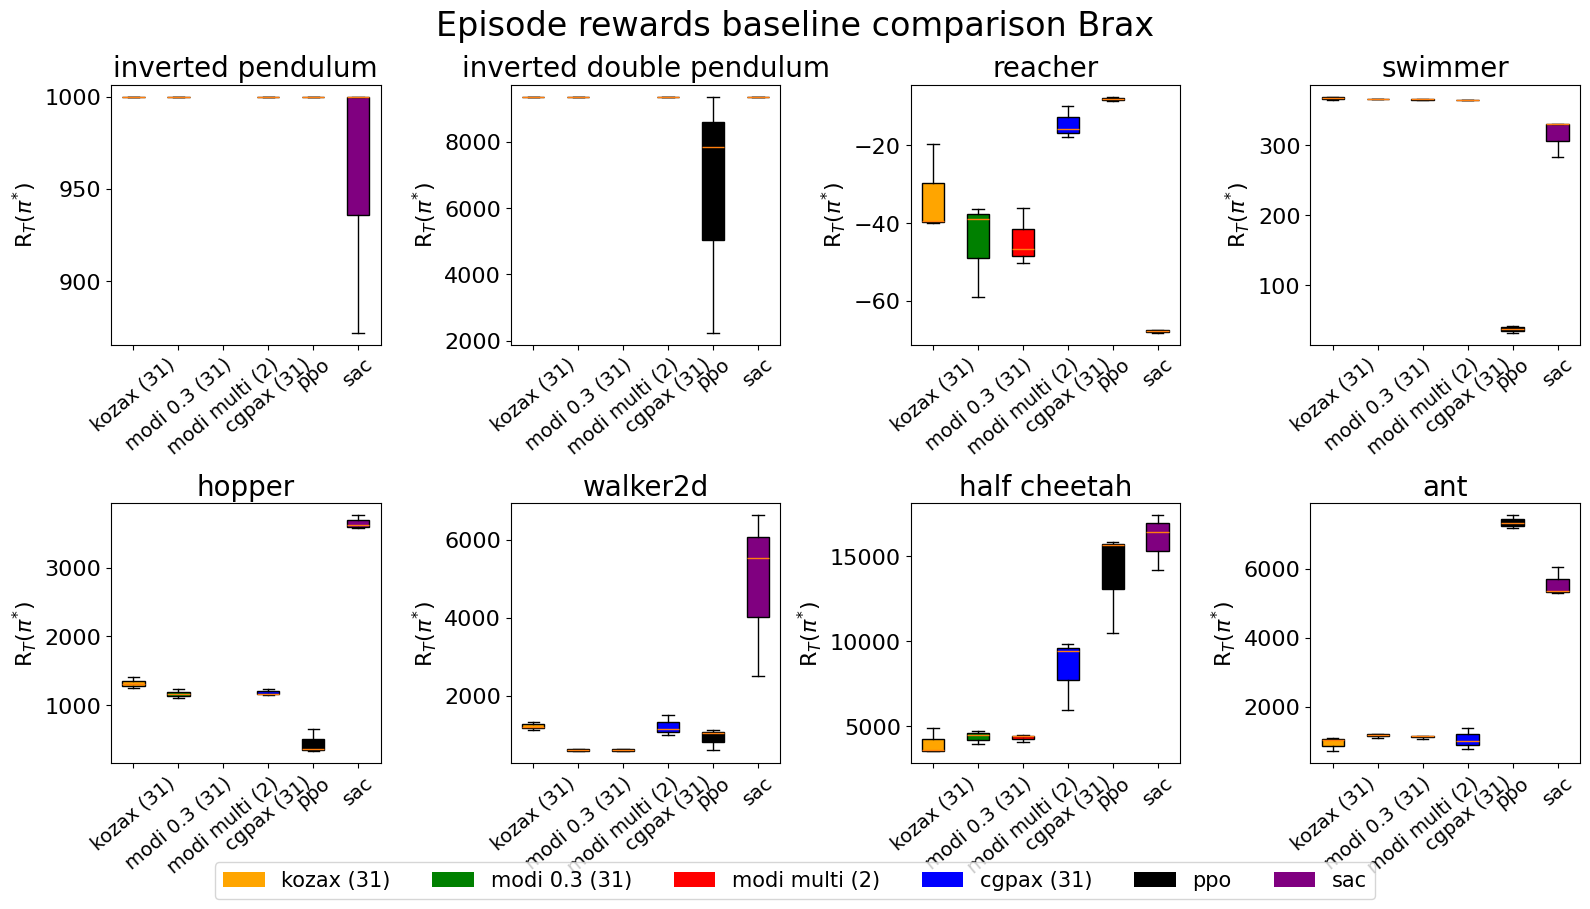

In [17]:
from matplotlib.patches import Patch

nrows = 2
ncols = 4
plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
colors = ["orange", "green", "red", "blue", "black", "purple"]
tick_labels = ["kozax (31)", "modi 0.3 (31)", "modi multi (2)", "cgpax (31)", "ppo", "sac"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards baseline comparison Brax", fontsize=24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize=20)
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize=16)
    axs[i,j].set_xticklabels(tick_labels, rotation=40, fontsize=14)
    axs[i,j].tick_params(axis="y", labelsize=16)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

## Complexity results

In [18]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([5, 5, 5])
inv_double_pen_koz = jnp.array([31, 29, 30])
reacher_koz = jnp.array([44, 56, 45])
swimmer_koz = jnp.array([37, 39, 36])
hopper_koz = jnp.array([54, 66, 51])
walker2d_koz = jnp.array([26, 33, 25]) # max_nodes = 7
half_cheetah_koz = jnp.array([27, 32, 29]) # max_nodes = 7
ant_koz = jnp.array([39, 47, 48]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([5, 7, 7])
inv_double_pen_modi = jnp.array([24, 28, 27])
reacher_modi = jnp.array([29, 31, 27])
swimmer_modi = jnp.array([27, 31, 31])
hopper_modi = jnp.array([29, 30, 27])
walker2d_modi = jnp.array([29, 24, 30])
half_cheetah_modi = jnp.array([24, 30, 25])
ant_modi = jnp.array([31, 30, 24])

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_multi = jnp.array([])
inv_double_pen_modi_multi = jnp.array([])
reacher_modi_multi = jnp.array([48, 49, 49])
swimmer_modi_multi = jnp.array([26, 29, 27])
hopper_modi_multi = jnp.array([])
walker2d_modi_multi = jnp.array([53, 55, 45])
half_cheetah_modi_multi = jnp.array([29, 32, 19])
ant_modi_multi = jnp.array([48, 52, 43])

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

inv_pen_cgpax = jnp.array([7, 7, 7])
inv_double_pen_cgpax = jnp.array([10, 11, 19])
reacher_cgpax = jnp.array([14, 9, 12])
swimmer_cgpax = jnp.array([12, 10, 12])
hopper_cgpax = jnp.array([14, 14, 10])
walker2d_cgpax = jnp.array([35, 22, 23])
half_cheetah_cgpax = jnp.array([22, 25, 19])
ant_cgpax = jnp.array([36, 21, 13])

# #PPO ()
# inv_pen_ppo = jnp.array([])
# inv_double_pen_ppo = jnp.array([])
# reacher_ppo = jnp.array([])
# swimmer_ppo = jnp.array([])
# hopper_ppo =  jnp.array([])
# walker2d_ppo = jnp.array([])
# half_cheetah_ppo = jnp.array([])
# ant_ppo =  jnp.array([])

# #SAC ()
# inv_pen_sac = jnp.array([])
# inv_double_pen_sac = jnp.array([])
# reacher_sac = jnp.array([])
# swimmer_sac = jnp.array([])
# hopper_sac = jnp.array([])
# walker2d_sac = jnp.array([])
# half_cheetah_sac = jnp.array([])
# ant_sac = jnp.array([])

# inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_modi_multi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
# inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_modi, inv_double_pen_modi_multi, inv_double_pen_cgpax, inv_double_pen_ppo, inv_double_pen_sac]
# reacher_results = [reacher_koz, reacher_modi, reacher_modi_multi, reacher_cgpax, reacher_ppo, reacher_sac]
# swimmer_results = [swimmer_koz, swimmer_modi, swimmer_modi_multi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
# hopper_results = [hopper_koz, hopper_modi, hopper_modi_multi, hopper_cgpax, hopper_ppo, hopper_sac]
# walker2d_results = [walker2d_koz, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
# half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_modi_multi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
# ant_results = [ant_koz, ant_modi, ant_modi_multi, ant_cgpax, ant_ppo, ant_sac]
# all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

In [19]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(inv_pen_koz.mean(), inv_pen_koz.std())
print(inv_double_pen_koz.mean(), inv_double_pen_koz.std())
print(reacher_koz.mean(), reacher_koz.std())
print(swimmer_koz.mean(), swimmer_koz.std())
print(hopper_koz.mean(), hopper_koz.std())
print(walker2d_koz.mean(), walker2d_koz.std()) # max_nodes = 7
print(half_cheetah_koz.mean(), half_cheetah_koz.std()) # max_nodes = 7
print(ant_koz.mean(), ant_koz.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi.mean(), inv_pen_modi.std())
print(inv_double_pen_modi.mean(), inv_double_pen_modi.std())
print(reacher_modi.mean(), reacher_modi.std())
print(swimmer_modi.mean(), swimmer_modi.std())
print(hopper_modi.mean(), hopper_modi.std())
print(walker2d_modi.mean(), walker2d_modi.std())
print(half_cheetah_modi.mean(), half_cheetah_modi.std())
print(ant_modi.mean(), ant_modi.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi_multi.mean(), inv_pen_modi_multi.std())
print(inv_double_pen_modi_multi.mean(), inv_double_pen_modi_multi.std())
print(reacher_modi_multi.mean(), reacher_modi_multi.std())
print(swimmer_modi_multi.mean(), swimmer_modi_multi.std())
print(hopper_modi_multi.mean(), hopper_modi_multi.std())
print(walker2d_modi_multi.mean(), walker2d_modi_multi.std())
print(half_cheetah_modi_multi.mean(), half_cheetah_modi_multi.std())
print(ant_modi_multi.mean(), ant_modi_multi.std())
print()

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

print(inv_pen_cgpax.mean(), inv_pen_cgpax.std())
print(inv_double_pen_cgpax.mean(), inv_double_pen_cgpax.std())
print(reacher_cgpax.mean(), reacher_cgpax.std())
print(swimmer_cgpax.mean(), swimmer_cgpax.std())
print(hopper_cgpax.mean(), hopper_cgpax.std())
print(walker2d_cgpax.mean(), walker2d_cgpax.std())
print(half_cheetah_cgpax.mean(), half_cheetah_cgpax.std())
print(ant_cgpax.mean(), ant_cgpax.std())
print()

# #PPO ()
# print(inv_pen_ppo.mean(), inv_pen_ppo.std())
# print(inv_double_pen_ppo.mean(), inv_double_pen_ppo.std())
# print(reacher_ppo.mean(), reacher_ppo.std())
# print(swimmer_ppo.mean(), swimmer_ppo.std())
# print(hopper_ppo.mean(), hopper_ppo.std())
# print(walker2d_ppo.mean(), walker2d_ppo.std())
# print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
# print(ant_ppo.mean(), ant_ppo.std())
# print()

# #SAC ()
# print(inv_pen_sac.mean(), inv_pen_sac.std())
# print(inv_double_pen_sac.mean(), inv_double_pen_sac.std())
# print(reacher_sac.mean(), reacher_sac.std())
# print(swimmer_sac.mean(), swimmer_sac.std())
# print(hopper_sac.mean(), hopper_sac.std())
# print(walker2d_sac.mean(), walker2d_sac.std())
# print(half_cheetah_sac.mean(), half_cheetah_sac.std())
# print(ant_sac.mean(), ant_sac.std())

5.0 0.0
30.0 0.8164966
48.333336 5.4365025
37.333336 1.2472191
57.0 6.4807405
28.0 3.5590262
29.333334 2.0548048
44.666668 4.0276823

6.3333335 0.942809
26.333334 1.6996732
29.0 1.6329932
29.666668 1.8856181
28.666668 1.2472191
27.666668 2.6246693
26.333334 2.6246693
28.333334 3.091206

nan nan
nan nan
48.666668 0.47140452
27.333334 1.2472192
nan nan
51.0 4.3204937
26.666668 5.5577774
47.666668 3.681787

7.0 0.0
13.333334 4.0276823
11.666667 2.0548046
11.333334 0.94280905
12.666667 1.8856181
26.666668 5.9066815
22.0 2.4494898
23.333334 9.533566



## Runtime results

In [20]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([1033, 857, 807])
inv_double_pen_koz = jnp.array([1085, 976, 959])
reacher_koz = jnp.array([1414, 971, 1126])
swimmer_koz = jnp.array([620, 605, 611])
hopper_koz = jnp.array([1306, 943, 536])
walker2d_koz = jnp.array([1757, 1509, 1330]) # max_nodes = 7
half_cheetah_koz = jnp.array([5801, 5441, 5406]) # max_nodes = 7
ant_koz = jnp.array([1138, 946, 920]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([1069, 1256, 945])
inv_double_pen_modi = jnp.array([1059, 1060, 1010])
reacher_modi = jnp.array([1418, 995, 869])
swimmer_modi = jnp.array([583, 534, 535])
hopper_modi = jnp.array([450, 438, 432])
walker2d_modi = jnp.array([1318, 1280, 1271])
half_cheetah_modi = jnp.array([5327, 5327, 5318])
ant_modi = jnp.array([782, 755, 742])

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_multi = jnp.array([])
inv_double_pen_modi_multi = jnp.array([])
reacher_modi_multi = jnp.array([1644, 1055, 871])
swimmer_modi_multi = jnp.array([530, 534, 528])
hopper_modi_multi = jnp.array([])
walker2d_modi_multi = jnp.array([1323, 1262, 1277])
half_cheetah_modi_multi = jnp.array([5349, 5329, 5313])
ant_modi_multi = jnp.array([798, 767, 756])

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

inv_pen_cgpax = jnp.array([1082, 1129, 1205])
inv_double_pen_cgpax = jnp.array([2693, 2449, 2286])
reacher_cgpax = jnp.array([1641, 1891, 1824])
swimmer_cgpax = jnp.array([1863, 1768, 36838])
hopper_cgpax = jnp.array([2923, 2903, 2951])
walker2d_cgpax = jnp.array([14745, 14203, 49433])
half_cheetah_cgpax = jnp.array([49175, 81731, 89197])
ant_cgpax = jnp.array([48166, 12140, 12494])

#PPO ()
inv_pen_ppo = jnp.array([254, 253, 265])
inv_double_pen_ppo = jnp.array([1567, 1612, 2007])
reacher_ppo = jnp.array([15121, 8814, 5790])
swimmer_ppo = jnp.array([73225, 85705, 16439])
hopper_ppo =  jnp.array([10031, 10501, 10446])
walker2d_ppo = jnp.array([15340, 16464, 57333])
half_cheetah_ppo = jnp.array([95005, 164093, 160334])
ant_ppo =  jnp.array([10123, 10658, 10423])

#SAC ()
inv_pen_sac = jnp.array([6806, 6852, 6784])
inv_double_pen_sac = jnp.array([13123, 22239, 55184])
reacher_sac = jnp.array([8474, 7803, 45633])
swimmer_sac = jnp.array([7076, 7423, 8703])
hopper_sac = jnp.array([7867, 7994, 7854])
walker2d_sac = jnp.array([9586, 9929, 10692])
half_cheetah_sac = jnp.array([11844, 11780, 11853])
ant_sac = jnp.array([11669, 10915, 11066])

inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_modi_multi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_modi, inv_double_pen_modi_multi, inv_double_pen_cgpax, inv_double_pen_ppo, inv_double_pen_sac]
reacher_results = [reacher_koz, reacher_modi, reacher_modi_multi, reacher_cgpax, reacher_ppo, reacher_sac]
swimmer_results = [swimmer_koz, swimmer_modi, swimmer_modi_multi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
hopper_results = [hopper_koz, hopper_modi, hopper_modi_multi, hopper_cgpax, hopper_ppo, hopper_sac]
walker2d_results = [walker2d_koz, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_modi_multi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
ant_results = [ant_koz, ant_modi, ant_modi_multi, ant_cgpax, ant_ppo, ant_sac]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

In [21]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(inv_pen_koz.mean(), inv_pen_koz.std())
print(inv_double_pen_koz.mean(), inv_double_pen_koz.std())
print(reacher_koz.mean(), reacher_koz.std())
print(swimmer_koz.mean(), swimmer_koz.std())
print(hopper_koz.mean(), hopper_koz.std())
print(walker2d_koz.mean(), walker2d_koz.std()) # max_nodes = 7
print(half_cheetah_koz.mean(), half_cheetah_koz.std()) # max_nodes = 7
print(ant_koz.mean(), ant_koz.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi.mean(), inv_pen_modi.std())
print(inv_double_pen_modi.mean(), inv_double_pen_modi.std())
print(reacher_modi.mean(), reacher_modi.std())
print(swimmer_modi.mean(), swimmer_modi.std())
print(hopper_modi.mean(), hopper_modi.std())
print(walker2d_modi.mean(), walker2d_modi.std())
print(half_cheetah_modi.mean(), half_cheetah_modi.std())
print(ant_modi.mean(), ant_modi.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi_multi.mean(), inv_pen_modi_multi.std())
print(inv_double_pen_modi_multi.mean(), inv_double_pen_modi_multi.std())
print(reacher_modi_multi.mean(), reacher_modi_multi.std())
print(swimmer_modi_multi.mean(), swimmer_modi_multi.std())
print(hopper_modi_multi.mean(), hopper_modi_multi.std())
print(walker2d_modi_multi.mean(), walker2d_modi_multi.std())
print(half_cheetah_modi_multi.mean(), half_cheetah_modi_multi.std())
print(ant_modi_multi.mean(), ant_modi_multi.std())
print()

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)

print(inv_pen_cgpax.mean(), inv_pen_cgpax.std())
print(inv_double_pen_cgpax.mean(), inv_double_pen_cgpax.std())
print(reacher_cgpax.mean(), reacher_cgpax.std())
print(swimmer_cgpax.mean(), swimmer_cgpax.std())
print(hopper_cgpax.mean(), hopper_cgpax.std())
print(walker2d_cgpax.mean(), walker2d_cgpax.std())
print(half_cheetah_cgpax.mean(), half_cheetah_cgpax.std())
print(ant_cgpax.mean(), ant_cgpax.std())
print()

#PPO ()
print(inv_pen_ppo.mean(), inv_pen_ppo.std())
print(inv_double_pen_ppo.mean(), inv_double_pen_ppo.std())
print(reacher_ppo.mean(), reacher_ppo.std())
print(swimmer_ppo.mean(), swimmer_ppo.std())
print(hopper_ppo.mean(), hopper_ppo.std())
print(walker2d_ppo.mean(), walker2d_ppo.std())
print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
print(ant_ppo.mean(), ant_ppo.std())
print()

#SAC ()
print(inv_pen_sac.mean(), inv_pen_sac.std())
print(inv_double_pen_sac.mean(), inv_double_pen_sac.std())
print(reacher_sac.mean(), reacher_sac.std())
print(swimmer_sac.mean(), swimmer_sac.std())
print(hopper_sac.mean(), hopper_sac.std())
print(walker2d_sac.mean(), walker2d_sac.std())
print(half_cheetah_sac.mean(), half_cheetah_sac.std())
print(ant_sac.mean(), ant_sac.std())

899.0 96.926094
1006.6667 55.823135
1170.3334 183.55078
612.0 6.164414
928.3334 314.52222
1532.0 175.07903
5549.3335 178.52792
1001.3334 97.21911

1090.0 127.83062
1043.0 23.338095
1094.0 234.8063
550.6667 22.866762
440.0 7.483315
1289.6667 20.368822
5324.0 4.2426405
759.6667 16.659998

nan nan
nan nan
1190.0 329.69785
530.6667 2.4944382
nan nan
1287.3334 25.95295
5330.3335 14.727148
773.6667 17.782637

1138.6667 50.67763
2476.0 167.2503
1785.3334 105.66089
13489.667 16509.81
2925.6667 19.686432
26127.0 16481.316
73367.67 17376.213
24266.668 16899.998

257.33334 5.436502
1728.6667 197.66695
9908.334 3887.1638
58456.336 30144.428
10326.0 209.8015
29712.334 19536.15
139810.67 31719.535
10401.334 218.94951

6814.0 28.331373
30182.0 18066.55
20636.668 17677.2
7734.0 699.67755
7905.0 63.15589
10069.0 462.2474
11825.667 32.499573
11216.667 325.73438


## Validation Baseline Results

In [22]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([1000, 1000, 1000])
inv_double_pen_koz = jnp.array([9359.51, 9359.41, 9359.78])
reacher_koz = jnp.array([-40.13, -39.61, -19.60])
swimmer_koz = jnp.array([367.52, 364.78, 369.07])
hopper_koz = jnp.array([1257.84, 1309.75, 1404.76])
walker2d_koz = jnp.array([1212.84, 1341.02, 1136.54]) # max_nodes = 7
half_cheetah_koz = jnp.array([3522.61, 3610.92, 4897.04]) # max_nodes = 7
ant_koz = jnp.array([1079.78, 703.05, 1037.20]) # max_nodes = 7

#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz_val = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_koz_val = jnp.array([9359.226, 9359.785, 9359.732, 9359.439, 9359.197, 9358.28, 9359.703, 9359.775, 9359.457, 9359.726, 9359.317, 9359.586, 9359.464, 9359.478, 9359.302, 9359.212, 9359.303, 9359.653, 9359.496, 9359.299, 9359.68, 9359.912, 9359.889, 9359.803, 9359.662, 9359.478, 9359.818, 9359.9, 9359.682, 9359.914])
reacher_koz_val = jnp.array([-122.18803, -39.341423, -39.4693, -129.34683, -228.1581, -73.61695, -66.75958, -29.879534, -52.23596, -138.57777, -44.517166, -54.970894, -57.37097, -40.8796, -13.739962, -12.224989, -12.050418, -48.131725, -14.703627, -45.299652, -15.646914, -11.650794, -10.113796, -17.040308, -51.033974, -8.081129, -11.415045, -10.876755, -13.559533, -19.182598])
swimmer_koz_val = jnp.array([365.8954, 367.49225, 366.32227, 367.89185, 369.08704, 368.97913, 366.61792, 367.42603, 364.2873, 368.55783, 364.61597, 366.54953, 367.5144, 367.58905, 367.25696, 366.59427, 364.85065, 367.05438, 365.61676, 365.56146, 369.04218, 370.7457, 370.65674, 370.61206, 371.89758, 369.17664, 369.33655, 368.25525, 368.76007, 370.85425])
hopper_koz_val = jnp.array([1198.587, 1237.1372, 1196.4631, 1235.235, 1249.8798, 1255.2429, 1283.3235, 1267.4395, 1277.6423, 1262.4597, 1178.8473, 1332.1698, 1344.694, 1222.6656, 1168.7726, 1404.8796, 1341.7614, 1202.6556, 1354.665, 1285.164, 1434.0886, 1364.1893, 1285.3658, 1485.8643, 1353.601, 1468.7781, 1359.5776, 1345.9603, 1397.3347, 1389.9001])
walker2d_koz_val = jnp.array([1207.8403, 1190.7443, 1170.0468, 1216.1128, 1191.132, 1216.4344, 1177.4072, 1206.277, 1217.2681, 1209.5336, 1313.7906, 1354.3674, 1340.5549, 1339.8284, 1321.164, 278.54993, 1318.6687, 1326.532, 1366.69, 1327.5879, 921.5767, 687.4643, 852.0639, 1079.3014, 626.9593, 867.3774, 761.4415, 936.2865, 1004.7622, 959.9776]) # max_nodes = 7
half_cheetah_koz_val = jnp.array([3513.517, 3529.7107, 3476.651, 3539.7864, 3567.2534, 3509.356, 3504.1128, 3530.056, 3506.142, 3537.2358, 3619.2832, 3620.1467, 3631.4543, 3601.2593, 3627.2134, 3619.0261, 3597.0898, 3618.9932, 3610.2515, 3627.8965, 4565.6045, 4809.5576, 4920.3096, 4987.2056, 4755.5522, 4939.1978, 4991.4927, 4967.416, 4953.4077, 4817.546]) # max_nodes = 7
ant_koz_val = jnp.array([1268.3302, 1322.4113, 1298.6351, 755.531, 879.9645, 1301.4751, 966.07404, 131.09488, 1297.0237, 187.68376, 1002.08905, 39.966995, 45.969368, 995.64465, 332.71567, 321.06247, 984.01654, 100.19222, 979.88916, 49.22131, 1072.9198, 1032.5925, 1028.2296, 1031.4852, 1031.7964, 1019.458, 1005.3097, 1055.7407, 1020.6965, 1018.43353]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([1000, 1000, 1000])
inv_double_pen_modi = jnp.array([9359.11, 9359.93, 9359.10])
reacher_modi = jnp.array([-39.07, -58.97, -36.51])
swimmer_modi = jnp.array([364.93, 366.00, 365.24])
hopper_modi = jnp.array([1112.68, 1162.75, 1239.69])
walker2d_modi = jnp.array([580.15, 640.95, 617.66])
half_cheetah_modi = jnp.array([4738.97, 4459.07, 3963.21])
ant_modi = jnp.array([1097.51, 1182.64, 1215.44])

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_val = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_modi_val = jnp.array([9358.526, 9359.78, 9359.69, 9358.725, 9358.593, 9357.107, 9359.534, 9359.739, 9358.797, 9359.789, 9359.916, 9359.973, 9359.973, 9359.91, 9359.929, 9359.84, 9359.963, 9359.969, 9359.953, 9359.975, 9358.643, 9359.641, 9359.482, 9359.244, 9358.5625, 9355.811, 9359.377, 9359.652, 9358.572, 9359.457])
reacher_modi_val = jnp.array([-32.974102, -157.00455, -174.26735, -22.220722, -93.41994, -13.100274, -14.925985, -202.68611, -42.621777, -19.290703, -24.732977, -140.1647, -7.3620453, -20.566296, -198.91632, -56.344284, -55.23688, -100.42915, -58.55442, -97.43886, -34.02261, -91.97061, -56.50609, -29.756634, -89.94681, -25.401257, -31.747074, -90.70827, -34.365555, -15.5869255])
swimmer_modi_val = jnp.array([364.36243, 366.76202, 366.92563, 367.32538, 366.08167, 367.24072, 364.62628, 366.2287, 365.4749, 363.1192, 365.49985, 367.12408, 367.06207, 368.4285, 368.64355, 367.22406, 366.10062, 367.36215, 366.41602, 367.53326, 364.74258, 367.26385, 366.94568, 367.594, 367.85394, 367.57642, 365.0114, 366.71948, 361.0282, 367.13416])
hopper_modi_val = jnp.array([1111.5277, 1033.5074, 1029.3164, 1031.2168, 1032.0062, 1080.5305, 1036.6115, 1027.6244, 1095.0873, 1100.9465, 1170.7567, 1163.8503, 1117.8496, 1172.4641, 1169.5288, 1145.1571, 1141.6036, 1160.2998, 1126.6707, 1167.1576, 1196.4818, 1216.8835, 1196.296, 1185.3173, 1203.5005, 1171.4755, 1203.7477, 1226.34, 1212.7119, 1216.5133])
walker2d_modi_val = jnp.array([568.2086, 728.49365, 522.9885, 597.54785, 529.9429, 523.1466, 489.54785, 639.9201, 534.82104, 580.3745, 83.42742, 883.70734, 217.6939, 685.3451, 1574.7753, 449.82715, 557.4971, 578.3159, 555.0335, 586.95233, 563.8375, 130.74269, 739.89764, 649.41846, 615.92816, 171.52023, 565.0603, 104.18243, 467.89767, 581.8578])
half_cheetah_modi_val = jnp.array([4704.554, 4739.2046, 4675.595, 4786.4453, 4837.469, 4718.989, 4712.607, 4756.5454, 4681.5615, 4794.583, 4472.0464, 4506.6323, 4509.0625, 4537.7793, 4554.5303, 4492.277, 4454.577, 4480.199, 4458.263, 4462.0723, 3958.9424, 3970.381, 3970.2935, 3979.6753, 3992.2388, 3967.8606, 3960.3457, 3967.148, 3954.051, 3971.694])
ant_modi_val = jnp.array([1054.484, 1149.2557, 1094.1892, 1163.0001, 1158.7762, 1168.7806, 1077.991, 1163.8214, 1117.8789, 1093.5663, 1192.3944, 1196.6754, 1192.389, 1120.0396, 1117.3763, 1176.2704, 1192.2329, 1196.8429, 1184.564, 1182.9313, 1184.4277, 1166.5747, 1264.4058, 932.39343, 1234.8143, 1295.899, 1315.7355, 1196.2839, 1244.1534, 1080.7595])

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
inv_pen_cgpax = jnp.array([1000, 1000, 1000])
inv_double_pen_cgpax = jnp.array([9358.16, 9359.02, 9358.14])
reacher_cgpax = jnp.array([-9.77, -17.75, -15.84])
swimmer_cgpax = jnp.array([364.79, 364.47, 364.08])
hopper_cgpax = jnp.array([1152.44, 1172.05, 1237.39])
walker2d_cgpax = jnp.array([991.10, 1142.15, 1511.56])
half_cheetah_cgpax = jnp.array([5961.83, 9420.95, 9815.46])
ant_cgpax = jnp.array([774.62, 1380.29, 1011.73])

#CGPAX seed 0 (pop_size = 500, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 15)
inv_pen_cgpax_val = jnp.array([1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000., 1000.])
inv_double_pen_cgpax_val = jnp.array([9352.57, 9359.363, 9358.446, 9357.552, 9355.865, 6592.1226, 9358.223, 9359.582, 9353.12, 9358.161, 9356.605, 9359.828, 9359.461, 9357.326, 7894.3066, 6481.136, 9359.284, 9359.498, 9358.141, 9359.76, 9353.358, 9358.992, 9358.357, 9357.205, 9355.57, 7442.9575, 9358.171, 9359.091, 9354.318, 9358.29])
reacher_cgpax_val = jnp.array([-11.035684, -8.032543, -6.649865, -17.572933, -204.86156, -91.60234, -58.990433, -8.2789, -131.2038, -34.697296, -8.36762, -156.42293, -186.84341, -16.191692, -186.60527, -83.84896, -65.064026, -166.7888, -127.940125, -28.766724, -12.18174, -158.4203, -8.789865, -19.91475, -195.57431, -80.80366, -77.29628, -27.56998, -122.19178, -35.739536])
swimmer_cgpax_val = jnp.array([350.67618, 359.71487, 360.0426, 370.66602, 366.38965, 370.38928, 357.47217, 366.41058, 367.93625, 366.31366, 364.09424, 364.36157, 363.3308, 365.70435, 364.25543, 364.516, 359.8185, 364.04718, 360.91595, 360.93628, 361.2046, 364.4168, 364.81604, 364.75574, 354.20346, 366.26678, 364.65796, 362.03864, 360.73914, 350.1306])
hopper_cgpax_val = jnp.array([1180.4431, 1123.9026, 1101.867, 995.5169, 1177.739, 1018.33203, 1169.1917, 1173.5074, 1139.292, 1159.5062, 245.75212, 1174.183, 1172.3977, 208.6787, 1183.1611, 1166.7006, 1182.0989, 1163.5156, 1165.5189, 1174.8274, 342.45352, 1250.7745, 390.88644, 299.95026, 430.491, 1248.4395, 1246.533, 256.99127, 1246.1677, 1251.9224])
walker2d_cgpax_val = jnp.array([1010.26733, 1008.0946, 916.777, 995.9993, 997.39526, 985.2489, 872.1092, 972.6999, 882.25385, 1005.94135, 57.81344, 56.8279, 1138.7505, 1149.473, 1144.2706, 1146.2981, 1125.3494, 1136.2214, 1136.0172, 1146.6349, 1442.1514, 1527.7806, 1470.4994, 1477.1031, 158.36446, 1518.1287, 1464.3116, 1515.7708, 1495.168, 1487.8435])
half_cheetah_cgpax_val = jnp.array([4752.1465, 4724.203, 4832.36, 4293.845, 4353.0664, 4857.8555, 4888.904, 4665.2275, 4838.656, 4495.7603, 2151.236, 2648.3196, 1667.2136, 1283.3256, 179.19232, 793.21216, 1855.6768, 2489.5513, 1457.6787, 1948.9033, 9241.713, 9674.164, 9599.209, 9851.3955, 10129.716, 9814.777, 10112.454, 10244.052, 9801.973, 9345.091])
ant_cgpax_val = jnp.array([905.2866, 492.24573, 698.25146, 222.80656, 822.3367, 888.8482, 812.38336, 852.8141, 820.6327, 18.145443, 351.88477, 333.77856, 665.8652, 1496.457, 1390.1401, 1322.6346, 1496.0708, 1385.0074, 1222.7651, 1382.7599, -5.2547126, 1078.1351, 1022.7895, 984.5019, 969.36835, 1024.9307, 1083.9714, -2.6536703, 1034.8174, 1043.1321])

inv_pen_results = [inv_pen_koz, inv_pen_koz, inv_pen_modi, inv_pen_modi_val, inv_pen_cgpax, inv_pen_cgpax_val]
inv_double_pen_results = [inv_double_pen_koz, inv_double_pen_koz_val, inv_double_pen_modi, inv_double_pen_modi_val, inv_double_pen_cgpax, inv_double_pen_cgpax_val]
reacher_results = [reacher_koz, reacher_koz_val, reacher_modi, reacher_modi_val, reacher_cgpax, reacher_cgpax_val]
swimmer_results = [swimmer_koz, swimmer_koz_val, swimmer_modi, swimmer_modi_val, swimmer_cgpax, swimmer_cgpax_val]
hopper_results = [hopper_koz, hopper_koz_val, hopper_modi, hopper_modi_val, hopper_cgpax, hopper_cgpax_val]
walker2d_results = [walker2d_koz, walker2d_koz_val, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_cgpax_val]
half_cheetah_results = [half_cheetah_koz, half_cheetah_koz_val, half_cheetah_modi, half_cheetah_modi_val, half_cheetah_cgpax, half_cheetah_cgpax_val]
ant_results = [ant_koz, ant_koz_val, ant_modi, ant_modi_val, ant_cgpax, ant_cgpax_val]
all_results = [inv_pen_results, inv_double_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results, ant_results]

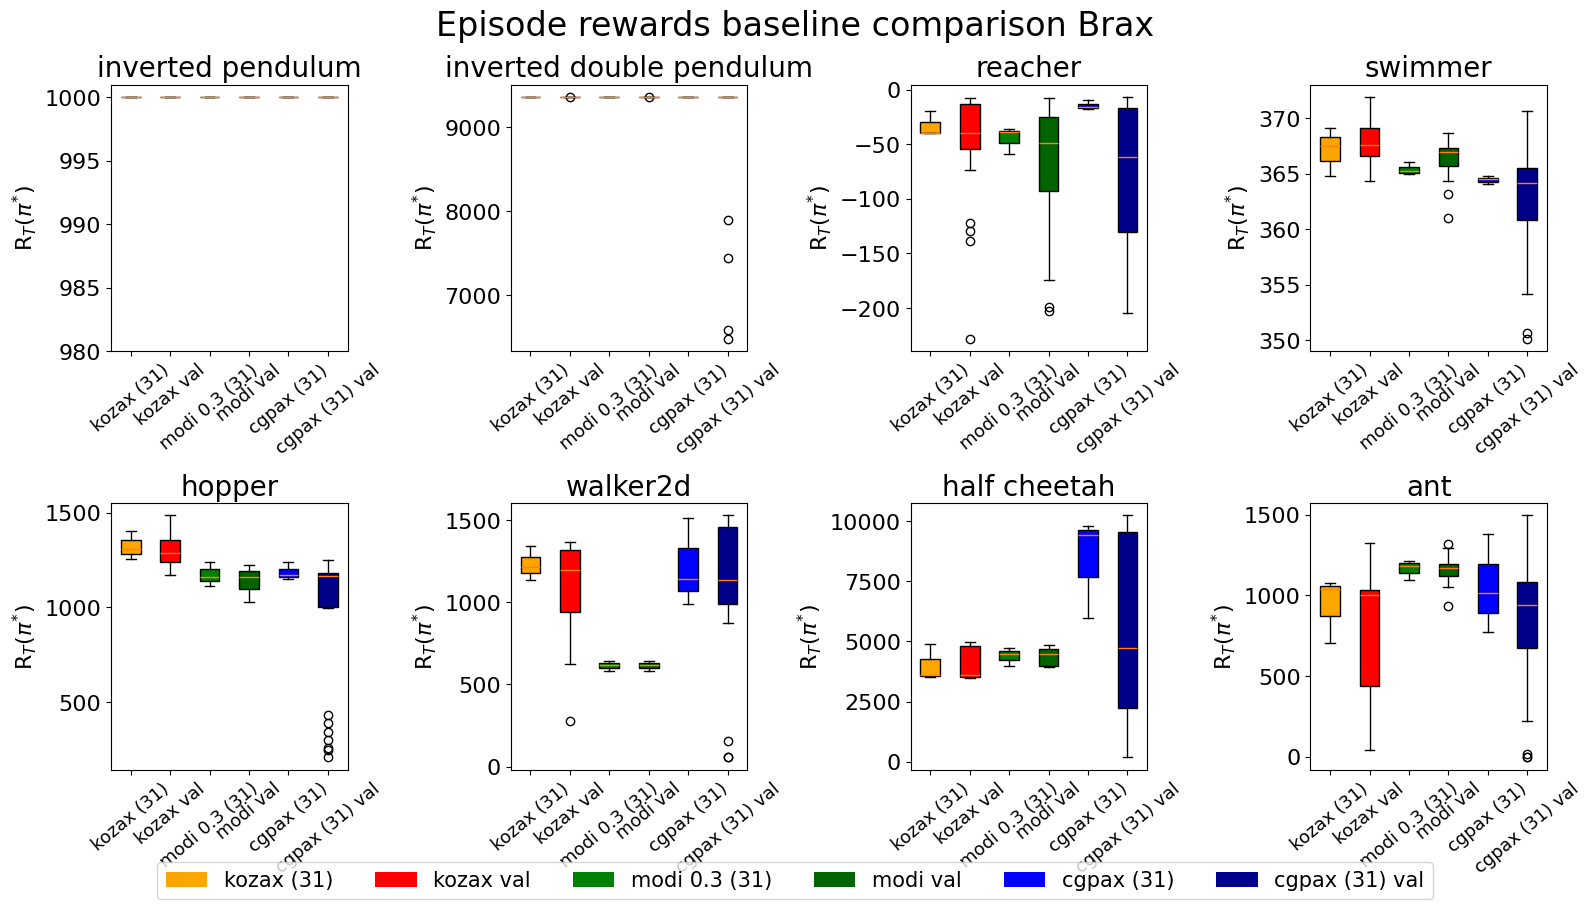

In [23]:
from matplotlib.patches import Patch

nrows = 2
ncols = 4
plot_titles = ["inverted pendulum", "inverted double pendulum", "reacher", "swimmer", "hopper", "walker2d", "half cheetah", "ant"]
colors = ["orange", "red", "green", "darkgreen", "blue", "darkblue"]
tick_labels = ["kozax (31)", "kozax val", "modi 0.3 (31)", "modi val", "cgpax (31)", "cgpax (31) val"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards baseline comparison Brax", fontsize=24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize=20)
    if plot_titles[idx] == "inverted pendulum":
      axs[i,j].set_ylim((980, 1001))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize=16)
    axs[i,j].set_xticklabels(tick_labels, rotation=40, fontsize=13)
    axs[i,j].tick_params(axis="y", labelsize=16)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize=15
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

# Mujoco Comparison

In [24]:
# hopper_scores = jnp.array([10.92, 23.35, 29.18, 45.04, 48.95, 64.59])
# walker_scores = jnp.array([228.42, 252.95, 301.51, 313.11, 299.52, 289.70])
# cheetah_scores = jnp.array([232.09, 242.76, 236.88, 390.00, 290.57, 269.23])

# all_scores = [hopper_scores, walker_scores, cheetah_scores]

In [25]:
# nr_of_cols = 3
# nr_of_rows = 1

# fig, axs = plt.subplots(nr_of_rows, nr_of_cols, figsize=(6, 6))
# fig.suptitle("Fitness Modi varying max nodes")

# x_s = jnp.array([10, 15, 20, 25, 30, 35])
# env_names = ["HopperHop", "WalkerWalk", "CheetahRun"]

# for i, env_name in enumerate(env_names):
#   k = i % nr_of_cols
#   axs[k].plot(x_s, all_scores[k], c="black")
#   axs[k].set_title(env_names[k])
#   axs[k].set_xlabel("max nodes")
#   axs[k].set_ylabel("fitness")
# plt.tight_layout()
# plt.show()

In [26]:
walker_multi_tree_modi_1_6 = jnp.array([299.64, 345.65, 340.90])
walker_multi_tree_modi_2_3 = jnp.array([438.18, 363.25, 330.71])
walker_multi_tree_modi_3_2 = jnp.array([366.44, 375.04, 337.55])

all_scores = [walker_multi_tree_modi_1_6, walker_multi_tree_modi_2_3, walker_multi_tree_modi_3_2]

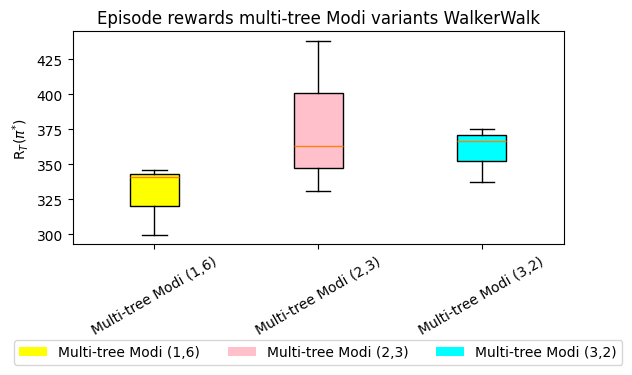

In [27]:
from matplotlib.patches import Patch

colors = ["yellow", "pink", "cyan"]
tick_labels = ["Multi-tree Modi (1,6)", "Multi-tree Modi (2,3)", "Multi-tree Modi (3,2)"]
bp = plt.boxplot(all_scores, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
  patch.set_facecolor(color)
  # for patch, color in zip(axs['boxes'], colors):
  #   patch.set_facecolor(color)
  plt.xticks(range(1, len(all_scores) + 1), tick_labels, rotation=30)
plt.ylabel(r"R$_T$($\pi^{*}$)")
plt.title("Episode rewards multi-tree Modi variants WalkerWalk")


legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

plt.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.6)
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

In [28]:
walker_multi_tree_modi_50 = jnp.array([492.25, 263.99, 325.77])
walker_multi_tree_modi_100 = jnp.array([519.14, 475.81, 507.29])
walker_multi_tree_modi_200 = jnp.array([502.15, 465.34, 481.25])
walker_multi_tree_modi_500 = jnp.array([502.93, 437.50, 522.83])
walker_multi_tree_modi_1000 = jnp.array([501.56, 517.20, 641.12])

all_scores = [walker_multi_tree_modi_50, walker_multi_tree_modi_100, walker_multi_tree_modi_200, walker_multi_tree_modi_500, walker_multi_tree_modi_1000]

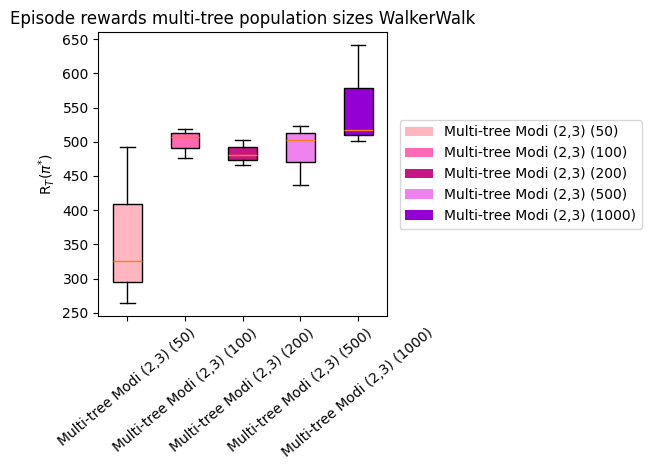

In [29]:
from matplotlib.patches import Patch

colors = ["lightpink", "hotpink", "mediumvioletred", "violet", "darkviolet"]
tick_labels = ["Multi-tree Modi (2,3) (50)", "Multi-tree Modi (2,3) (100)", "Multi-tree Modi (2,3) (200)", "Multi-tree Modi (2,3) (500)", "Multi-tree Modi (2,3) (1000)"]
bp = plt.boxplot(all_scores, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
  patch.set_facecolor(color)
  # for patch, color in zip(axs['boxes'], colors):
  #   patch.set_facecolor(color)
  plt.xticks(range(1, len(all_scores) + 1), tick_labels, rotation=40)
plt.ylabel(r"R$_T$($\pi^{*}$)")
plt.title("Episode rewards multi-tree population sizes WalkerWalk")


legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

plt.legend(
    handles=legend_elements,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1
)

# plt.legend(
#     handles=legend_elements,
#     loc="lower center",
#     ncol=len(tick_labels),
#     bbox_to_anchor=(0.5, -0.5)
# )

plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

In [30]:
# cartpole_muj_modi = jnp.array([999.299, 999.638, 999.734, 998.935, 999.688, 999.164, 999.673, 999.071, 999.686, 999.064])
# reacher_muj_modi = jnp.array([0., 969., 956., 965., 0., 950., 910., 0., 953., 945.])
# swimmer_muj_modi = jnp.array([12.104, 12.254, 404.326, 29.672, 17.867, 20.077, 4.984, 10.115, 7.519, 45.294])
# hopper_muj_modi = jnp.array([0., 4.541, 12.565, 6.874, 0.092, 0., 0., 4.404, 4.765, 0.])
# walker_muj_modi = jnp.array([126.486, 183.672, 187.557, 159.399, 183.04, 180.666, 209.276, 214.563, 180.802, 209.056])
# half_cheetah_muj_modi = jnp.array([183.892, 212.466, 234.023, 230.9, 225.17, 206.525, 197.757, 162.738, 203.516, 214.619])

# cartpole_muj_modi_100 = jnp.array([999.682, 999.895, 999.883, 999.436, 999.823, 999.7, 999.806, 999.594, 999.871, 999.545])
# reacher_muj_modi_100 = jnp.array([988., 950., 908., 932., 921., 564., 39., 835., 921., 948.])
# swimmer_muj_modi_100 = jnp.array([37.075, 38.617, 626.687, 223.369, 202.836, 82.241, 4.561, 24.286, 61.872, 569.931])
# hopper_muj_modi_100 = jnp.array([ 0., 0., 32.493, 31.79, 31.872, 0., 31.001, 0., 0., 0.])
# walker_muj_modi_100 = jnp.array([288.481, 200.324, 131.914, 173.643, 220.211, 212.348, 231.508, 129.078, 126.805, 232.129])
# half_cheetah_muj_modi_100 = jnp.array([219.562, 206.748, 228.983, 200.124, 243.859, 213.264, 229.229, 218.033, 237.127, 241.216])


# cartpole_muj_modi_31 = jnp.array([999.678, 999.893, 999.882, 999.429, 999.821, 999.695, 999.803, 999.589, 999.87, 999.539])
# reacher_muj_modi_31 = jnp.array([989., 921., 965., 955., 931., 50., 928., 947., 918., 884.])
# swimmer_muj_modi_31 = jnp.array([63.026, 11.991, 178.26, 40.549, 14.126, 21.829, 5.06, 9.495, 14.35, 580.194])
# hopper_muj_modi_31 = jnp.array([0., 0., 16.17, 33.969, 0.131, 0., 0., 0., 0., 0.])
# walker_muj_modi_31 = jnp.array([263.505, 357.869, 263.484, 157.828, 189.042, 315.117, 308.894, 143.63, 235.867, 156.382])
# half_cheetah_muj_modi_31 = jnp.array([221.18, 216.778, 229.119, 205.306, 237.611, 242.436, 218.511, 215.571, 231.423, 218.89 ])

# cartpole_muj_modi_31_100 = jnp.array([999.686, 999.897, 999.883, 999.44, 999.824, 999.704, 999.807, 999.599, 999.871, 999.549])
# reacher_muj_modi_31_100 = jnp.array([977., 929., 966., 0., 935., 63., 202., 971., 265., 913.])
# swimmer_muj_modi_31_100 = jnp.array([165.517, 11.804, 885.511, 27.474, 14.087, 21.996, 15.158, 9.837, 73.356, 607.769])
# hopper_muj_modi_31_100 = jnp.array([66.885, 40.201, 59.113, 48.774, 39.958, 67.912, 76.705, 29.945, 58.86, 64.646])
# walker_muj_modi_31_100 = jnp.array([198.04, 298.723, 305.329, 325.068, 424.641, 316.248, 249.18, 275.241, 188.907, 226.276])
# half_cheetah_muj_modi_31_100 = jnp.array([305.318, 308.952, 319.917, 287.012, 303.031, 301.408, 306.77, 278.236, 248.745, 281.466])


# cartpole_muj_modi_05 = jnp.array([999.299, 999.638, 999.734, 998.935, 999.688, 999.164, 999.673, 999.071, 999.686, 999.064])
# reacher_muj_modi_05 = jnp.array([77., 817., 838., 50., 732., 0., 963., 566., 90., 748.])
# swimmer_muj_modi_05 = jnp.array([182.107, 166.871, 875.319, 175.007, 276.913, 282.457, 27.355, 29.542, 82.367, 610.221])
# hopper_muj_modi_05 = jnp.array([25.79, 0., 41.226, 42.726, 0.078, 0., 0., 46.238, 0., 34.469])
# walker_muj_modi_05 = jnp.array([170.67, 213.608, 161.395, 200.99, 183.362, 223.379, 171.494, 195.467, 253.588, 275.211])
# half_cheetah_muj_modi_05 = jnp.array([228.029, 256.997, 203.092, 234.249, 263.274, 256.94, 238.235, 224.349, 275.157, 225.923])

# cartpole_muj_modi_05_100 = jnp.array([999.682, 999.895, 999.883, 999.436, 999.823, 999.7, 999.806, 999.594, 999.871, 999.545])
# reacher_muj_modi_05_100 = jnp.array([0., 0., 866., 664., 763., 336., 94., 945., 70., 0.])
# swimmer_muj_modi_05_100 = jnp.array([237.1, 223.769, 883.481, 468.353, 331.877, 384.51, 36.907, 188.744, 127.155, 637.696])
# hopper_muj_modi_05_100 = jnp.array([0., 0., 66.061, 66.281, 0.073, 0., 0., 70.223, 0., 70.622])
# walker_muj_modi_05_100 = jnp.array([250.936, 221.617, 248.403, 339.757, 245.473, 224.669, 347.014, 204.691, 170.449, 277.111])
# half_cheetah_muj_modi_05_100 = jnp.array([301.389, 241.676, 289.312, 332.105, 353.94, 257.773, 307.596, 294.534, 301.709, 271.37])


# cartpole_muj_modi_05_31 = jnp.array([999.678, 999.893, 999.882, 999.429, 999.821, 999.695, 999.803, 999.589, 999.87, 999.539])
# reacher_muj_modi_05_31 = jnp.array([985., 893., 955., 930., 885., 237., 874., 0., 878., 863.])
# swimmer_muj_modi_05_31 = jnp.array([12.365, 12.868, 728.888, 40.993, 18.125, 22.562, 5.074, 10.681, 8.446, 79.106])
# hopper_muj_modi_05_31 = jnp.array([20.289, 13.042, 18.417, 26.667, 38.554, 22.976, 20.263, 8.92, 50.861, 0.])
# walker_muj_modi_05_31 = jnp.array([245.304, 207.691, 219.615, 192.182, 219.883, 264.863, 175.034, 309.933, 191.54, 183.667])
# half_cheetah_muj_modi_05_31 = jnp.array([250.895, 242.993, 233.569, 258.957, 239.762, 242.009, 260.126, 235.152, 251.82, 217.735])

# cartpole_muj_modi_05_31_100 = jnp.array([999.686, 999.897, 999.883, 999.44, 999.824, 999.704, 999.807, 999.599, 999.871, 999.549])
# reacher_muj_modi_05_31_100 = jnp.array([984., 0., 965., 951., 922., 10., 683., 9., 332., 976.])
# swimmer_muj_modi_05_31_100 = jnp.array([12.078, 12.657, 774.843, 39.875, 15.163, 22.562, 4.659, 10.223, 8.318, 200.118])
# hopper_muj_modi_05_31_100 = jnp.array([2.357, 63.493, 57.156, 40.112, 40.553, 60.129, 48.046, 47.385, 25.538, 48.366])
# walker_muj_modi_05_31_100 = jnp.array([313.472, 305.015, 259.529, 214.351, 272.758, 325.753, 217.206, 184.324, 240.17, 227.501])
# half_cheetah_muj_modi_05_31_100 = jnp.array([301.231, 266.225, 298.726, 297.263, 310.567, 288.431, 321.088, 76.496, 295.538, 319.157])


# cartpole_muj_koz_scaled = jnp.array([999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55])
# reacher_muj_koz_scaled = jnp.array([71., 947., 720., 53., 642., 0., 181., 928., 810., 873.])
# swimmer_muj_koz_scaled = jnp.array([26.32, 27.653, 806.277, 27.3, 13.956, 122.688, 8.635, 9.857, 17.045, 467.509])
# hopper_muj_koz_scaled = jnp.array([0., 5.91, 26.848, 12.576, 0.062, 26.749, 15.321, 27.939, 0.693, 15.035])
# walker_muj_koz_scaled = jnp.array([209.056, 258.701, 365.056, 254.051, 204.002, 229.425, 242.421, 240.967, 189.773, 259.542])
# half_cheetah_muj_koz_scaled = jnp.array([248.783, 216.976, 272.458, 258.199, 282.693, 259.001, 122.627, 269.086, 277.081, 263.4])

# cartpole_muj_koz_scaled_100 = jnp.array([999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.599, 999.872, 999.55])
# reacher_muj_koz_scaled_100 = jnp.array([525., 936., 919., 257., 821., 7., 911., 496., 916., 952.])
# swimmer_muj_koz_scaled_100 = jnp.array([151.363, 11.571, 890.806, 48.916, 285.77, 25.361, 20.033, 9.853, 46.375, 639.611])
# hopper_muj_koz_scaled_100 = jnp.array([0., 0., 0., 90.649, 0.045, 0., 0., 0., 0., 0.])
# walker_muj_koz_scaled_100 = jnp.array([236.845, 245.152, 239.787, 252.995, 301.632, 376.253, 235.229, 262.749, 243.66, 366.04])
# half_cheetah_muj_koz_scaled_100 = jnp.array([259.398, 254.43, 258.64, 315.501, 270.054, 286.314, 147.135, 268.161, 296.289, 267.976])


# cartpole_muj_koz_31 = jnp.array([999.519, 999.783, 999.824, 999.228, 999.769, 999.471, 999.752, 999.37, 999.797, 999.34])
# reacher_muj_koz_31 = jnp.array([71., 947., 720., 53., 642., 0., 181., 928., 810., 873.])
# swimmer_muj_koz_31 = jnp.array([26.32, 27.653, 806.277, 27.3, 13.956, 122.688, 8.635, 9.857, 17.045, 467.509])
# hopper_muj_koz_31 = jnp.array([0., 0., 18.484, 54.329, 0.041, 0., 0., 0., 0., 0.])
# walker_muj_koz_31 = jnp.array([196.236, 264.117, 171.896, 235.519, 227.078, 303.047, 241.112, 295.991, 208.661, 248.115])
# half_cheetah_muj_koz_31 = jnp.array([75.204, 197.118, 251.852, 123.404, 269.859, 219.779, 208.463, 73.154, 314.192, 150.233])

# cartpole_muj_koz_31_100 = jnp.array([999.667, 999.887, 999.881, 999.416, 999.818, 999.68, 999.8, 999.573, 999.869, 999.525])
# reacher_muj_koz_31_100 = jnp.array([525., 936., 919., 257., 821., 7., 911., 496., 916., 952.])
# swimmer_muj_koz_31_100 = jnp.array([151.363, 11.571, 890.806, 48.916, 285.77, 25.361, 20.033, 9.853, 46.375, 639.611])
# hopper_muj_koz_31_100 = jnp.array([0., 0., 60.453, 50.068, 0.118, 0., 0., 0., 0., 0.])
# walker_muj_koz_31_100 = jnp.array([370.126, 191.43, 302.05, 340.486, 186.792, 191.479, 265.477, 181.137, 273.084, 215.512])
# half_cheetah_muj_koz_31_100 = jnp.array([242.613, 291.792, 285.128, 186.131, 276.268, 298.913, 284.85, 257.823, 278.618, 296.769])

# cartpole_results = [cartpole_muj_modi, cartpole_muj_modi_100, cartpole_muj_modi_31, cartpole_muj_modi_31_100, cartpole_muj_modi_05, cartpole_muj_modi_05_100, cartpole_muj_modi_05_31, cartpole_muj_modi_05_31_100, cartpole_muj_koz_scaled, cartpole_muj_koz_scaled_100, cartpole_muj_koz_31, cartpole_muj_koz_31_100]
# reacher_results = [reacher_muj_modi, reacher_muj_modi_100, reacher_muj_modi_31, reacher_muj_modi_31_100, reacher_muj_modi_05, reacher_muj_modi_05_100, reacher_muj_modi_05_31, reacher_muj_modi_05_31_100, reacher_muj_koz_scaled, reacher_muj_koz_scaled_100, reacher_muj_koz_31, reacher_muj_koz_31_100]
# swimmer_results = [swimmer_muj_modi, swimmer_muj_modi_100, swimmer_muj_modi_31, swimmer_muj_modi_31_100, swimmer_muj_modi_05, swimmer_muj_modi_05_100, swimmer_muj_modi_05_31, swimmer_muj_modi_05_31_100, swimmer_muj_koz_scaled, swimmer_muj_koz_scaled_100, swimmer_muj_koz_31, swimmer_muj_koz_31_100]
# hopper_results = [hopper_muj_modi, hopper_muj_modi_100, hopper_muj_modi_31, hopper_muj_modi_31_100, hopper_muj_modi_05, hopper_muj_modi_05_100, hopper_muj_modi_05_31, hopper_muj_modi_05_31_100, hopper_muj_koz_scaled, hopper_muj_koz_scaled_100, hopper_muj_koz_31, hopper_muj_koz_31_100]
# walker_results = [walker_muj_modi, walker_muj_modi_100, walker_muj_modi_31, walker_muj_modi_31_100, walker_muj_modi_05, walker_muj_modi_05_100, walker_muj_modi_05_31, walker_muj_modi_05_31_100, walker_muj_koz_scaled, walker_muj_koz_scaled_100, walker_muj_koz_31, walker_muj_koz_31_100]
# half_cheetah_results = [half_cheetah_muj_modi, half_cheetah_muj_modi_100, half_cheetah_muj_modi_31, half_cheetah_muj_modi_31_100, half_cheetah_muj_modi_05, half_cheetah_muj_modi_05_100, half_cheetah_muj_modi_05_31, half_cheetah_muj_modi_05_31_100, half_cheetah_muj_koz_scaled, half_cheetah_muj_koz_scaled_100, half_cheetah_muj_koz_31, half_cheetah_muj_koz_31_100]
# all_results = [cartpole_results, reacher_results, swimmer_results, hopper_results, walker_results, half_cheetah_results]

In [31]:
cartpole_muj_koz_scaled_100 = jnp.array([999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.599, 999.872, 999.55])
reacher_muj_koz_scaled_100 = jnp.array([525., 936., 919., 257., 821., 7., 911., 496., 916., 952.])
swimmer_muj_koz_scaled_100 = jnp.array([151.363, 11.571, 890.806, 48.916, 285.77, 25.361, 20.033, 9.853, 46.375, 639.611])
hopper_muj_koz_scaled_100 = jnp.array([0., 0., 0., 90.649, 0.045, 0., 0., 0., 0., 0.])
walker_muj_koz_scaled_100 = jnp.array([236.845, 245.152, 239.787, 252.995, 301.632, 376.253, 235.229, 262.749, 243.66, 366.04])
half_cheetah_muj_koz_scaled_100 = jnp.array([259.398, 254.43, 258.64, 315.501, 270.054, 286.314, 147.135, 268.161, 296.289, 267.976])

cartpole_muj_koz_31_100 = jnp.array([999.667, 999.887, 999.881, 999.416, 999.818, 999.68, 999.8, 999.573, 999.869, 999.525])
reacher_muj_koz_31_100 = jnp.array([525., 936., 919., 257., 821., 7., 911., 496., 916., 952.])
swimmer_muj_koz_31_100 = jnp.array([151.363, 11.571, 890.806, 48.916, 285.77, 25.361, 20.033, 9.853, 46.375, 639.611])
hopper_muj_koz_31_100 = jnp.array([0., 0., 60.453, 50.068, 0.118, 0., 0., 0., 0., 0.])
walker_muj_koz_31_100 = jnp.array([370.126, 191.43, 302.05, 340.486, 186.792, 191.479, 265.477, 181.137, 273.084, 215.512])
half_cheetah_muj_koz_31_100 = jnp.array([242.613, 291.792, 285.128, 186.131, 276.268, 298.913, 284.85, 257.823, 278.618, 296.769])


cartpole_muj_modi_100 = jnp.array([999.682, 999.895, 999.883, 999.436, 999.823, 999.7, 999.806, 999.594, 999.871, 999.545])
reacher_muj_modi_100 = jnp.array([988., 950., 908., 932., 921., 564., 39., 835., 921., 948.])
swimmer_muj_modi_100 = jnp.array([37.075, 38.617, 626.687, 223.369, 202.836, 82.241, 4.561, 24.286, 61.872, 569.931])
hopper_muj_modi_100 = jnp.array([ 0., 0., 32.493, 31.79, 31.872, 0., 31.001, 0., 0., 0.])
walker_muj_modi_100 = jnp.array([288.481, 200.324, 131.914, 173.643, 220.211, 212.348, 231.508, 129.078, 126.805, 232.129])
half_cheetah_muj_modi_100 = jnp.array([219.562, 206.748, 228.983, 200.124, 243.859, 213.264, 229.229, 218.033, 237.127, 241.216])

cartpole_muj_modi_31_100 = jnp.array([999.686, 999.897, 999.883, 999.44, 999.824, 999.704, 999.807, 999.599, 999.871, 999.549])
reacher_muj_modi_31_100 = jnp.array([977., 929., 966., 0., 935., 63., 202., 971., 265., 913.])
swimmer_muj_modi_31_100 = jnp.array([165.517, 11.804, 885.511, 27.474, 14.087, 21.996, 15.158, 9.837, 73.356, 607.769])
hopper_muj_modi_31_100 = jnp.array([66.885, 40.201, 59.113, 48.774, 39.958, 67.912, 76.705, 29.945, 58.86, 64.646])
walker_muj_modi_31_100 = jnp.array([198.04, 298.723, 305.329, 325.068, 424.641, 316.248, 249.18, 275.241, 188.907, 226.276])
half_cheetah_muj_modi_31_100 = jnp.array([305.318, 308.952, 319.917, 287.012, 303.031, 301.408, 306.77, 278.236, 248.745, 281.466])


cartpole_muj_modi_05_100 = jnp.array([999.682, 999.895, 999.883, 999.436, 999.823, 999.7, 999.806, 999.594, 999.871, 999.545])
reacher_muj_modi_05_100 = jnp.array([0., 0., 866., 664., 763., 336., 94., 945., 70., 0.])
swimmer_muj_modi_05_100 = jnp.array([237.1, 223.769, 883.481, 468.353, 331.877, 384.51, 36.907, 188.744, 127.155, 637.696])
hopper_muj_modi_05_100 = jnp.array([0., 0., 66.061, 66.281, 0.073, 0., 0., 70.223, 0., 70.622])
walker_muj_modi_05_100 = jnp.array([250.936, 221.617, 248.403, 339.757, 245.473, 224.669, 347.014, 204.691, 170.449, 277.111])
half_cheetah_muj_modi_05_100 = jnp.array([301.389, 241.676, 289.312, 332.105, 353.94, 257.773, 307.596, 294.534, 301.709, 271.37])

cartpole_muj_modi_05_31_100 = jnp.array([999.686, 999.897, 999.883, 999.44, 999.824, 999.704, 999.807, 999.599, 999.871, 999.549])
reacher_muj_modi_05_31_100 = jnp.array([984., 0., 965., 951., 922., 10., 683., 9., 332., 976.])
swimmer_muj_modi_05_31_100 = jnp.array([12.078, 12.657, 774.843, 39.875, 15.163, 22.562, 4.659, 10.223, 8.318, 200.118])
hopper_muj_modi_05_31_100 = jnp.array([2.357, 63.493, 57.156, 40.112, 40.553, 60.129, 48.046, 47.385, 25.538, 48.366])
walker_muj_modi_05_31_100 = jnp.array([313.472, 305.015, 259.529, 214.351, 272.758, 325.753, 217.206, 184.324, 240.17, 227.501])
half_cheetah_muj_modi_05_31_100 = jnp.array([301.231, 266.225, 298.726, 297.263, 310.567, 288.431, 321.088, 76.496, 295.538, 319.157])

cartpole_results = [cartpole_muj_koz_scaled_100, cartpole_muj_koz_31_100, cartpole_muj_modi_100, cartpole_muj_modi_31_100, cartpole_muj_modi_05_100, cartpole_muj_modi_05_31_100]
reacher_results = [reacher_muj_koz_scaled_100, reacher_muj_koz_31_100, reacher_muj_modi_100, reacher_muj_modi_31_100, reacher_muj_modi_05_100, reacher_muj_modi_05_31_100]
swimmer_results = [swimmer_muj_koz_scaled_100, swimmer_muj_koz_31_100, swimmer_muj_modi_100, swimmer_muj_modi_31_100, swimmer_muj_modi_05_100, swimmer_muj_modi_05_31_100]
hopper_results = [hopper_muj_koz_scaled_100, hopper_muj_koz_31_100, hopper_muj_modi_100, hopper_muj_modi_31_100, hopper_muj_modi_05_100, hopper_muj_modi_05_31_100]
walker_results = [walker_muj_koz_scaled_100, walker_muj_koz_31_100, walker_muj_modi_100, walker_muj_modi_31_100, walker_muj_modi_05_100, walker_muj_modi_05_31_100]
half_cheetah_results = [half_cheetah_muj_koz_scaled_100, half_cheetah_muj_koz_31_100, half_cheetah_muj_modi_100, half_cheetah_muj_modi_31_100, half_cheetah_muj_modi_05_100, half_cheetah_muj_modi_05_31_100]
all_results = [cartpole_results, reacher_results, swimmer_results, hopper_results, walker_results, half_cheetah_results]

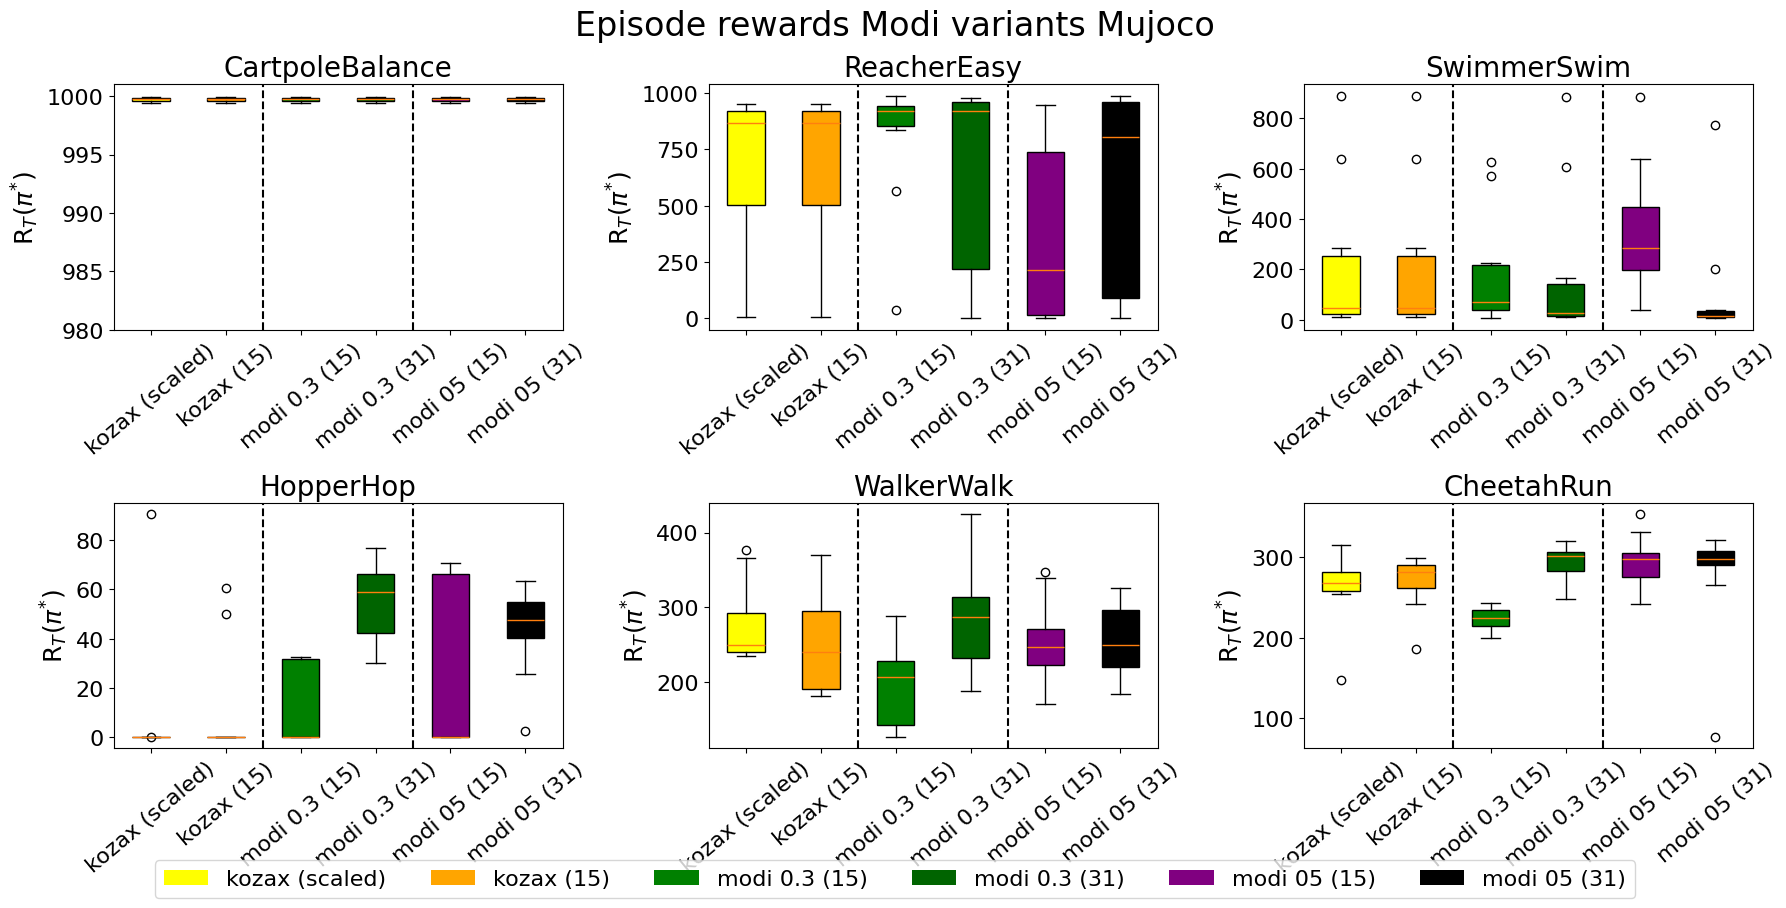

In [32]:
from matplotlib.patches import Patch

nrows = 2
ncols = 3
plot_titles = ["CartpoleBalance", "ReacherEasy", "SwimmerSwim", "HopperHop", "WalkerWalk", "CheetahRun"]
colors = ["yellow", "orange", "green", "darkgreen", 'purple', 'black']
tick_labels = ["kozax (scaled)", "kozax (15)", "modi 0.3 (15)", "modi 0.3 (31)", "modi 05 (15)", "modi 05 (31)"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 9))
fig.suptitle("Episode rewards Modi variants Mujoco", fontsize = 24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize = 20)
    if plot_titles[idx] == "CartpoleBalance":
      axs[i,j].set_ylim((980, 1001))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize = 18)
    axs[i,j].set_xticklabels(tick_labels, rotation=40, fontsize = 16)
    axs[i,j].tick_params(axis="y", labelsize=16)
    [axs[i,j].axvline(x, color = 'black', linestyle='--') for x in [2.5,4.5]]


legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize = 16
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

In [33]:
#Kozax (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 15)
inv_pen_muj_koz_scaled = [992.46, 998.41, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81]
reacher_muj_koz_scaled = [428.75, 549.81, 691.38, 831.94, 846.81, 860.06, 860.06, 860.06, 860.06, 861.13, 887.31, 887.31, 890.0, 890.0, 890.0, 890.44, 890.44, 893.31, 893.31, 893.31, 893.31]
swimmer_muj_koz_scaled = [181.11, 193.64, 235.78, 275.50, 292.68, 299.16, 329.49, 352.07, 352.07, 368.91, 370.93, 375.76, 383.36, 387.03, 387.94, 389.46, 389.46, 389.46, 389.46, 397.10, 397.10]
hopper_muj_koz_scaled = [1.39, 9.37, 15.31, 27.92, 32.71, 33.64, 33.64, 37.06, 41.14, 41.24, 41.24, 41.24, 42.49, 42.49, 42.49, 42.49, 42.49, 42.49, 42.49, 42.49, 42.49]
walker2d_muj_koz_scaled = [147.91, 201.46, 230.27, 237.14, 253.75, 266.09, 293.84, 299.19, 303.26, 303.26, 303.26, 322.80, 322.80, 322.80, 322.80, 322.80, 322.80, 322.80, 322.80, 322.80, 322.80]
half_cheetah_muj_koz_scaled = [120.40, 186.63, 218.97, 232.57, 253.34, 258.19, 262.36, 262.36, 263.29, 276.88, 276.88, 280.82, 292.97, 298.53, 301.92, 302.74, 308.27, 308.27, 308.27, 308.27, 308.27]
muj_koz_scaled = [inv_pen_muj_koz_scaled, reacher_muj_koz_scaled, swimmer_muj_koz_scaled, hopper_muj_koz_scaled, walker2d_muj_koz_scaled, half_cheetah_muj_koz_scaled]

#Kozax (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 31)
inv_pen_muj_koz_31 = [992.46, 998.20, 998.51, 999.61, 999.61, 999.72, 999.72, 999.72, 999.77, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81]
reacher_muj_koz_31 = [428.75, 549.81, 691.38, 831.94, 846.81, 860.06, 860.06, 860.06, 860.06, 861.13, 887.31, 887.31, 890.0, 890.0, 890.0, 890.44, 890.44, 893.31, 893.31, 893.31, 893.31]
swimmer_muj_koz_31 = [181.11, 193.64, 235.78, 275.50, 292.68, 299.16, 329.49, 352.07, 352.07, 368.91, 370.93, 375.76, 383.36, 387.03, 387.94, 389.46, 389.46, 389.46, 389.46, 397.10, 397.10]
hopper_muj_koz_31 = [1.05, 3.71, 8.48, 10.23, 19.41, 27.59, 27.59, 27.59, 28.30, 29.62, 33.38, 34.45, 34.45, 34.94, 34.94, 35.12, 35.12, 35.12, 36.72, 36.72, 36.72]
walker2d_muj_koz_31 = [143.45, 211.62, 236.25, 248.22, 248.61, 258.55, 276.34, 294.62, 294.62, 294.80, 294.80, 300.40, 301.50, 312.28, 312.28, 312.28, 312.28, 312.28, 312.28, 312.28, 312.28]
half_cheetah_muj_koz_31 = [109.95, 185.29, 253.47, 262.39, 266.23, 272.68, 277.48, 282.19, 282.19, 286.55, 286.55, 286.90, 292.26, 293.33, 293.96, 294.75, 294.75, 295.94, 295.94, 295.94, 295.94]
muj_koz_31 = [inv_pen_muj_koz_31, reacher_muj_koz_31, swimmer_muj_koz_31, hopper_muj_koz_31, walker2d_muj_koz_31, half_cheetah_muj_koz_31]

#Modi (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 15, modi_rate = 0.3)
inv_pen_muj_mod = [992.81, 994.25, 998.32, 998.59, 998.59, 999.65, 999.80, 999.80, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83]
reacher_muj_mod = [346.94, 554.63, 600.69, 644.56, 672.06, 745.13, 745.13, 766.0, 774.19, 781.31, 781.31, 781.31, 782.56, 782.56, 782.56, 782.56, 782.56, 782.56, 782.56, 782.56, 782.56]
swimmer_muj_mod = [172.98, 189.46, 192.90, 196.29, 198.84, 201.15, 215.85, 239.71, 246.63, 285.92, 307.62, 347.97, 352.59, 368.60, 368.60, 368.60, 368.60, 368.60, 373.76, 374.97, 374.97]
hopper_muj_mod = [0.83, 2.15, 6.05, 10.60, 10.60, 10.60, 10.86, 11.23, 11.61, 11.61, 11.84, 12.40, 13.88, 17.22, 19.38, 19.60, 19.60, 19.60, 20.07, 20.07, 20.36]
walker_muj_mod = [92.40, 166.69, 188.38, 211.23, 221.85, 240.74, 240.74, 240.74, 241.10, 241.10, 241.10, 241.62, 241.62, 241.62, 241.62, 248.10, 248.10, 248.10, 248.10, 250.54, 250.54]
half_cheetah_muj_mod = [154.57, 204.24, 210.22, 213.33, 220.59, 220.59, 226.14, 226.14, 226.14, 226.14, 226.14, 232.58, 233.15, 236.23, 236.56, 236.56, 236.56, 236.56, 236.56, 236.56, 237.32]
muj_mod = [inv_pen_muj_mod, reacher_muj_mod, swimmer_muj_mod, hopper_muj_mod, walker_muj_mod, half_cheetah_muj_mod]

#Modi (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 31, modi_rate = 0.3)
inv_pen_muj_mod_31 = [992.46, 998.46, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81]
reacher_muj_mod_31 = [401.32, 526.94, 704.25, 861.5, 873.94, 886.94, 898.81, 940.94, 942.63, 952.19, 952.19, 952.38, 953.19, 953.19, 953.19, 953.19, 953.19, 953.19, 957.88, 957.88, 958.43]
swimmer_muj_mod_31 = [173.87, 196.74, 240.31, 337.06, 341.19, 361.25, 361.38, 371.12, 372.28, 372.33, 373.48, 376.01, 379.03, 384.56, 388.94, 389.04, 389.78, 389.78, 391.36, 392.77, 394.61]
hopper_muj_mod_31 = [1.37, 2.28, 6.30, 11.21, 14.11, 27.72, 31.04, 33.87, 38.77, 45.92, 48.84, 54.47, 54.47, 54.47, 57.76, 57.76, 60.05, 60.45, 61.00, 61.04, 65.41]
walker_muj_mod_31 = [63.02, 183.73, 202.69, 209.43, 223.72, 287.12, 298.71, 298.94, 298.94, 299.50, 299.50, 303.03, 306.91, 306.91, 308.78, 319.65, 319.65, 319.65, 319.65, 330.69, 330.69]
half_cheetah_muj_mod_31 = [129.48, 190.03, 246.39, 263.60, 277.54, 283.89, 287.93, 291.26, 294.98, 295.05, 296.82, 296.82, 296.82, 299.49, 299.49, 299.54, 300.88, 303.12, 305.88, 305.88, 308.94]
muj_mod_31 = [inv_pen_muj_mod_31, reacher_muj_mod_31, swimmer_muj_mod_31, hopper_muj_mod_31, walker_muj_mod_31, half_cheetah_muj_mod_31]

#Modi (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 15, modi_rate = 0.5)
inv_pen_muj_mod_05 = [992.81, 994.25, 998.32, 998.59, 998.59, 999.65, 999.80, 999.80, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83, 999.83]
reacher_muj_mod_05 = [410.75, 532.44, 635.19, 702.06, 733.5, 790.56, 790.56, 790.56, 790.56, 790.56, 803.75, 805.56, 809.56, 873.69, 873.69, 873.69, 876.94, 890.0, 890.0, 897.63, 897.63]
swimmer_muj_mod_05 = [172.98, 186.62, 215.93, 220.02, 261.62, 421.53, 421.53, 421.53, 447.72, 450.13, 450.13, 458.17, 458.17, 458.17, 458.17, 458.17, 458.17, 458.17, 458.17, 458.17, 458.17]
hopper_muj_mod_05 = [1.92, 2.95, 7.64, 9.18, 15.88, 18.20, 18.26, 21.45, 25.37, 25.85, 26.07, 26.96, 29.92, 29.92, 31.48, 31.68, 31.68, 31.68, 31.68, 31.68, 31.68]
walker_muj_mod_05 = [95.50, 177.48, 206.95, 217.25, 223.86, 233.74, 241.56, 245.84, 254.98, 259.00, 262.66, 275.31, 290.86, 290.86, 290.86, 301.41, 301.41, 301.41, 301.41, 301.41, 301.41]
half_cheetah_muj_mod_05 = [144.18, 194.59, 210.88, 221.33, 222.11, 234.45, 243.86, 249.44, 249.44, 266.82, 271.62, 285.10, 292.71, 297.31, 300.81, 308.54, 308.54, 308.54, 308.54, 308.54, 308.54]
muj_mod_05 = [inv_pen_muj_mod_05, reacher_muj_mod_05, swimmer_muj_mod_05, hopper_muj_mod_05, walker_muj_mod_05, half_cheetah_muj_mod_05]

#Modi (pop_size = 5x100, nr_of_gen = 100, operator_list = [+,-,x], max_nodes = 31, modi_rate = 0.3)
inv_pen_muj_mod_05_31 = [992.46, 998.46, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81, 999.81]
reacher_muj_mod_05_31 = [401.31, 524.0, 762.13, 789.25, 847.88, 847.88, 878.13, 883.19, 886.13, 886.13, 892.75, 897.25, 923.69, 926.44, 926.94, 933.06, 937.19, 944.88, 954.31, 954.31, 954.31]
swimmer_muj_mod_05_31 = [174.76, 188.10, 198.97, 213.33, 228.33, 229.09, 229.09, 235.94, 236.01, 236.22, 236.22, 239.96, 251.63, 251.63, 251.63, 252.40, 253.03, 257.02, 258.78, 259.28, 259.64]
hopper_muj_mod_05_31 = [0.90, 3.97, 7.76, 10.03, 17.32, 26.20, 28.57, 30.16, 36.97, 40.41, 40.41, 40.41, 40.41, 40.41, 41.89, 42.33, 42.33, 43.04, 46.55, 49.36, 49.36]
walker_muj_mod_05_31 = [130.27, 179.39, 215.21, 234.48, 236.55, 243.81, 267.77, 267.77, 274.67, 278.61, 283.90, 286.60, 286.60, 287.52, 289.62, 290.40, 298.04, 298.04, 298.04, 298.04, 298.04]
half_cheetah_muj_mod_05_31 = [114.93, 197.01, 211.44, 221.22, 222.71, 238.74, 250.21, 250.44, 257.43, 265.57, 265.57, 265.57, 265.57, 271.09, 273.73, 274.36, 281.56, 291.97, 291.97, 292.13, 301.25]
muj_mod_05_31 = [inv_pen_muj_mod_05_31, reacher_muj_mod_05_31, swimmer_muj_mod_05_31, hopper_muj_mod_05_31, walker_muj_mod_05_31, half_cheetah_muj_mod_05_31]

all_muj = [muj_koz_scaled, muj_koz_31, muj_mod, muj_mod_31, muj_mod_05, muj_mod_05_31]

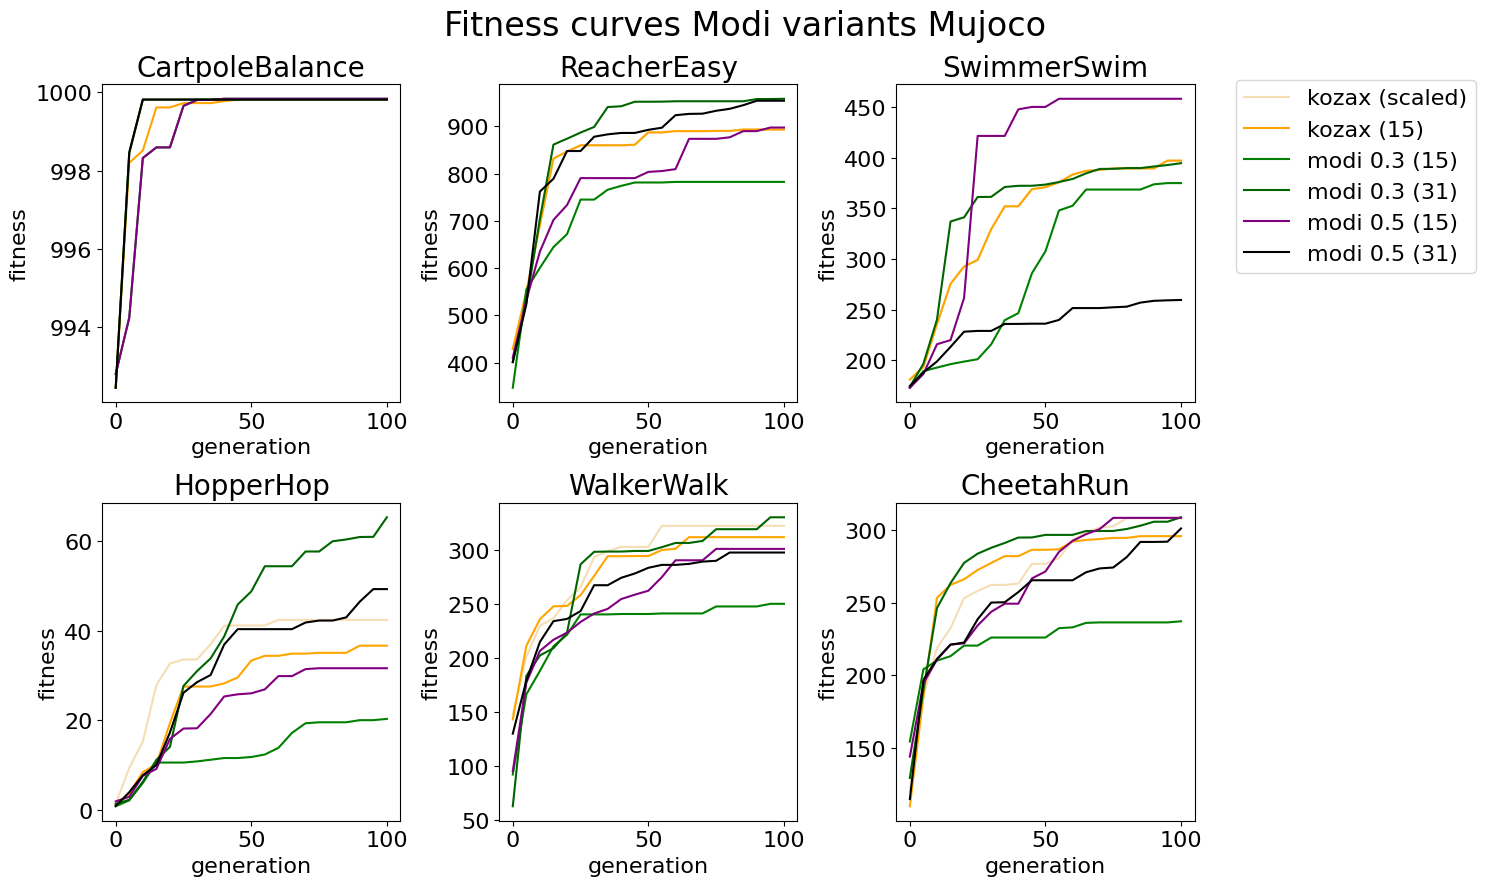

In [34]:
nr_of_cols = 3
nr_of_rows = 2

fig, axs = plt.subplots(nr_of_rows, nr_of_cols, figsize=(15, 9))
fig.suptitle("Fitness curves Modi variants Mujoco", fontsize = 24)

x_s = jnp.arange(21)*5
env_names = ["CartpoleBalance", "ReacherEasy", "SwimmerSwim", "HopperHop", "WalkerWalk", "CheetahRun"]

for i, env_name in enumerate(env_names):
  j = int(i / nr_of_cols)
  k = i % nr_of_cols
  axs[j, k].plot(x_s, all_muj[0][i], label = "kozax (scaled)", c="wheat")
  axs[j, k].plot(x_s, all_muj[1][i], label = "kozax (15)", c="orange")
  axs[j, k].plot(x_s, all_muj[2][i], label = "modi 0.3 (15)", c="green")
  axs[j, k].plot(x_s, all_muj[3][i], label = "modi 0.3 (31)", c="darkgreen")
  axs[j, k].plot(x_s, all_muj[4][i], label = "modi 0.5 (15)", c="purple")
  axs[j, k].plot(x_s, all_muj[5][i], label = "modi 0.5 (31)", c="black")
  axs[j, k].set_title(env_name, fontsize = 20)
  axs[j, k].set_xlabel("generation", fontsize = 16)
  axs[j, k].set_ylabel("fitness", fontsize = 16)
  axs[j, k].tick_params(axis="x", labelsize=16)
  axs[j, k].tick_params(axis="y", labelsize=16)
axs[0, 2].legend(bbox_to_anchor=(1.1, 1.05), fontsize = 16)
plt.tight_layout()
plt.show()

In [35]:
# cartpole_muj_koz_31_100 = jnp.array([999.667, 999.887, 999.881, 999.416, 999.818, 999.68, 999.8, 999.573, 999.869, 999.525])
# reacher_muj_koz_31_100 = jnp.array([525., 936., 919., 257., 821., 7., 911., 496., 916., 952.])
# swimmer_muj_koz_31_100 = jnp.array([151.363, 11.571, 890.806, 48.916, 285.77, 25.361, 20.033, 9.853, 46.375, 639.611])
# hopper_muj_koz_31_100 = jnp.array([0., 0., 60.453, 50.068, 0.118, 0., 0., 0., 0., 0.])
# walker_muj_koz_31_100 = jnp.array([370.126, 191.43, 302.05, 340.486, 186.792, 191.479, 265.477, 181.137, 273.084, 215.512])
# half_cheetah_muj_koz_31_100 = jnp.array([242.613, 291.792, 285.128, 186.131, 276.268, 298.913, 284.85, 257.823, 278.618, 296.769])

# cartpole_muj_modi_31_100 = jnp.array([999.686, 999.897, 999.883, 999.44, 999.824, 999.704, 999.807, 999.599, 999.871, 999.549])
# reacher_muj_modi_31_100 = jnp.array([977., 929., 966., 0., 935., 63., 202., 971., 265., 913.])
# swimmer_muj_modi_31_100 = jnp.array([165.517, 11.804, 885.511, 27.474, 14.087, 21.996, 15.158, 9.837, 73.356, 607.769])
# hopper_muj_modi_31_100 = jnp.array([66.885, 40.201, 59.113, 48.774, 39.958, 67.912, 76.705, 29.945, 58.86, 64.646])
# walker_muj_modi_31_100 = jnp.array([198.04, 298.723, 305.329, 325.068, 424.641, 316.248, 249.18, 275.241, 188.907, 226.276])
# half_cheetah_muj_modi_31_100 = jnp.array([305.318, 308.952, 319.917, 287.012, 303.031, 301.408, 306.77, 278.236, 248.745, 281.466])

# #PPO ()
# cartpole_ppo = jnp.array([999.52])
# reacher_ppo = jnp.array([981.10])
# swimmer_ppo = jnp.array([466.97])
# hopper_ppo =  jnp.array([1.12])
# walker2d_ppo =  jnp.array([971.67])
# half_cheetah_ppo =  jnp.array([1.73])

# #SAC ()
# cartpole_sac = jnp.array([994.39])
# reacher_sac = jnp.array([947.97])
# swimmer_sac = jnp.array([257.69])
# hopper_sac = jnp.array([168.71])
# walker2d_sac = jnp.array([977.10])
# half_cheetah_sac = jnp.array([912.37])

# cartpole_results = [cartpole_muj_koz_31_100, cartpole_muj_modi_31_100, cartpole_ppo, cartpole_sac]
# reacher_results = [reacher_muj_koz_31_100, reacher_muj_modi_31_100, reacher_ppo, reacher_sac]
# swimmer_results = [swimmer_muj_koz_31_100, swimmer_muj_modi_31_100, swimmer_ppo, swimmer_sac]
# hopper_results = [hopper_muj_koz_31_100, hopper_muj_modi_31_100, hopper_ppo, hopper_sac]
# walker2d_results = [walker_muj_koz_31_100, walker_muj_modi_31_100, walker2d_ppo, walker2d_sac]
# half_cheetah_results = [half_cheetah_muj_koz_31_100, half_cheetah_muj_modi_31_100, half_cheetah_ppo, half_cheetah_sac]
# all_results = [cartpole_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results]

In [36]:
# from matplotlib.patches import Patch

# nrows = 2
# ncols = 3
# plot_titles = ["CartpoleBalance", "ReacherEasy", "SwimmerSwim", "HopperHop", "WalkerWalk", "CheetahRun"]
# colors = ["orange", "green", "black", "purple"]
# tick_labels = ["kozax (31)", "modi (31)", "ppo", "sac"]
# fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
# fig.suptitle("Episode rewards baseline comparison Mujoco", fontsize = 24)
# for i in range(nrows):
#   for j in range(ncols):
#     idx = i * ncols + j
#     bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
#     for patch, color in zip(bp['boxes'], colors):
#       patch.set_facecolor(color)
#     # for patch, color in zip(axs['boxes'], colors):
#     #   patch.set_facecolor(color)
#     axs[i,j].set_title(plot_titles[idx], fontsize = 20)
#     axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize = 18)
#     axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize = 18)
#     axs[i,j].tick_params(axis="y", labelsize=18)

# legend_elements = [
#     Patch(facecolor=color, label=label)
#     for color, label in zip(colors, tick_labels)
# ]

# fig.legend(
#     handles=legend_elements,
#     loc="lower center",
#     ncol=len(tick_labels),
#     bbox_to_anchor=(0.5, -0.02),
#     fontsize = 18
# )
# plt.tight_layout()
#     # axs[i,j].get_xaxis().set_visible(False)

In [37]:
cartpole_muj_koz_31_100 = jnp.array([999.81, 999.84, 999.89])
reacher_muj_koz_31_100 = jnp.array([958.38, 907.38, 933.63])
swimmer_muj_koz_31_100 = jnp.array([433.75, 290.12, 431.28])
hopper_muj_koz_31_100 = jnp.array([44.20, 74.41, 43.71])
walker_muj_koz_31_100 = jnp.array([342.63, 346.39, 321.82])
half_cheetah_muj_koz_31_100 = jnp.array([295.28, 296.50, 370.46])

cartpole_muj_modi_31_100 = jnp.array([999.81, 999.84, 999.89])
reacher_muj_modi_31_100 = jnp.array([895.0, 927.31, 933.44])
swimmer_muj_modi_31_100 = jnp.array([430.86, 363.18, 414.93])
hopper_muj_modi_31_100 = jnp.array([22.46, 55.55, 36.60])
walker_muj_modi_31_100 = jnp.array([371.01, 302.67, 337.69])
half_cheetah_muj_modi_31_100 = jnp.array([274.14, 238.87, 238.09])

cartpole_muj_modi_multi_31_100 = jnp.array([])
reacher_muj_modi_multi_31_100 = jnp.array([969.63, 900.0, 942.19])
swimmer_muj_modi_multi_31_100 = jnp.array([229.95, 471.46, 459.55])
hopper_muj_modi_multi_31_100 = jnp.array([38.55, 58.84, 38.65])
walker_muj_modi_multi_31_100 = jnp.array([381.34, 425.91, 494.00])
half_cheetah_muj_modi_multi_31_100 = jnp.array([353.15, 362.58, 361.03])

#PPO ()
cartpole_ppo = jnp.array([999.52, 999.34, 999.66])
reacher_ppo = jnp.array([981.10, 983.21, 978.45])
swimmer_ppo = jnp.array([466.97, 411.84, 464.82])
hopper_ppo =  jnp.array([1.12, 2.29, 2.20])
walker2d_ppo =  jnp.array([971.67, 967.67, 970.75])
half_cheetah_ppo =  jnp.array([1.73, 64.20, 19.56])

#SAC ()
cartpole_sac = jnp.array([994.39, 994.12, 994.05])
reacher_sac = jnp.array([947.97, 963.77, 956.34])
swimmer_sac = jnp.array([257.69, 228.91, 195.00])
hopper_sac = jnp.array([168.71, 99.55, 143.22])
walker2d_sac = jnp.array([977.10, 974.9, 975.79])
half_cheetah_sac = jnp.array([912.37, 917.71, 908.75])

cartpole_results = [cartpole_muj_koz_31_100, cartpole_muj_modi_31_100, cartpole_muj_modi_multi_31_100, cartpole_ppo, cartpole_sac]
reacher_results = [reacher_muj_koz_31_100, reacher_muj_modi_31_100, reacher_muj_modi_multi_31_100, reacher_ppo, reacher_sac]
swimmer_results = [swimmer_muj_koz_31_100, swimmer_muj_modi_31_100, swimmer_muj_modi_multi_31_100, swimmer_ppo, swimmer_sac]
hopper_results = [hopper_muj_koz_31_100, hopper_muj_modi_31_100, hopper_muj_modi_multi_31_100, hopper_ppo, hopper_sac]
walker2d_results = [walker_muj_koz_31_100, walker_muj_modi_31_100, walker_muj_modi_multi_31_100, walker2d_ppo, walker2d_sac]
half_cheetah_results = [half_cheetah_muj_koz_31_100, half_cheetah_muj_modi_31_100, half_cheetah_muj_modi_multi_31_100, half_cheetah_ppo, half_cheetah_sac]
all_results = [cartpole_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results]

In [38]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(cartpole_muj_koz_31_100.mean(), cartpole_muj_koz_31_100.std())
print(reacher_muj_koz_31_100.mean(), reacher_muj_koz_31_100.std())
print(swimmer_muj_koz_31_100.mean(), swimmer_muj_koz_31_100.std())
print(hopper_muj_koz_31_100.mean(), hopper_muj_koz_31_100.std())
print(walker_muj_koz_31_100.mean(), walker_muj_koz_31_100.std()) # max_nodes = 7
print(half_cheetah_muj_koz_31_100.mean(), half_cheetah_muj_koz_31_100.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(cartpole_muj_modi_31_100.mean(), cartpole_muj_modi_31_100.std())
print(reacher_muj_modi_31_100.mean(), reacher_muj_modi_31_100.std())
print(swimmer_muj_modi_31_100.mean(), swimmer_muj_modi_31_100.std())
print(hopper_muj_modi_31_100.mean(), hopper_muj_modi_31_100.std())
print(walker_muj_modi_31_100.mean(), walker_muj_modi_31_100.std())
print(half_cheetah_muj_modi_31_100.mean(), half_cheetah_muj_modi_31_100.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(cartpole_muj_modi_multi_31_100.mean(), cartpole_muj_modi_multi_31_100.std())
print(reacher_muj_modi_multi_31_100.mean(), reacher_muj_modi_multi_31_100.std())
print(swimmer_muj_modi_multi_31_100.mean(), swimmer_muj_modi_multi_31_100.std())
print(hopper_muj_modi_multi_31_100.mean(), hopper_muj_modi_multi_31_100.std())
print(walker_muj_modi_multi_31_100.mean(), walker_muj_modi_multi_31_100.std())
print(half_cheetah_muj_modi_multi_31_100.mean(), half_cheetah_muj_modi_multi_31_100.std())
print()

#PPO ()
print(cartpole_ppo.mean(), cartpole_ppo.std())
print(reacher_ppo.mean(), reacher_ppo.std())
print(swimmer_ppo.mean(), swimmer_ppo.std())
print(hopper_ppo.mean(), hopper_ppo.std())
print(walker2d_ppo.mean(), walker2d_ppo.std())
print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
print()

#SAC ()
print(cartpole_sac.mean(), cartpole_sac.std())
print(reacher_sac.mean(), reacher_sac.std())
print(swimmer_sac.mean(), swimmer_sac.std())
print(hopper_sac.mean(), hopper_sac.std())
print(walker2d_sac.mean(), walker2d_sac.std())
print(half_cheetah_sac.mean(), half_cheetah_sac.std())

999.8467 0.033003826
933.13007 20.823666
385.05002 67.133224
54.10667 14.35802
336.9467 10.805754
320.74667 35.15616

999.8467 0.033003826
918.5834 16.86267
402.99 28.891384
38.20333 13.556426
337.12335 27.902563
250.36667 16.813309

nan nan
937.2734 28.63814
386.98666 111.148094
45.346672 9.541315
433.75 46.32615
358.92 4.1287837

999.5067 0.13095802
980.92004 1.9474283
447.87668 25.496887
1.8699999 0.53160137
970.02997 1.710519
28.496666 26.274488

994.1867 0.1466022
956.02673 6.4541473
227.2 25.621634
137.16 28.557768
975.93005 0.9035668
912.94336 3.6803117


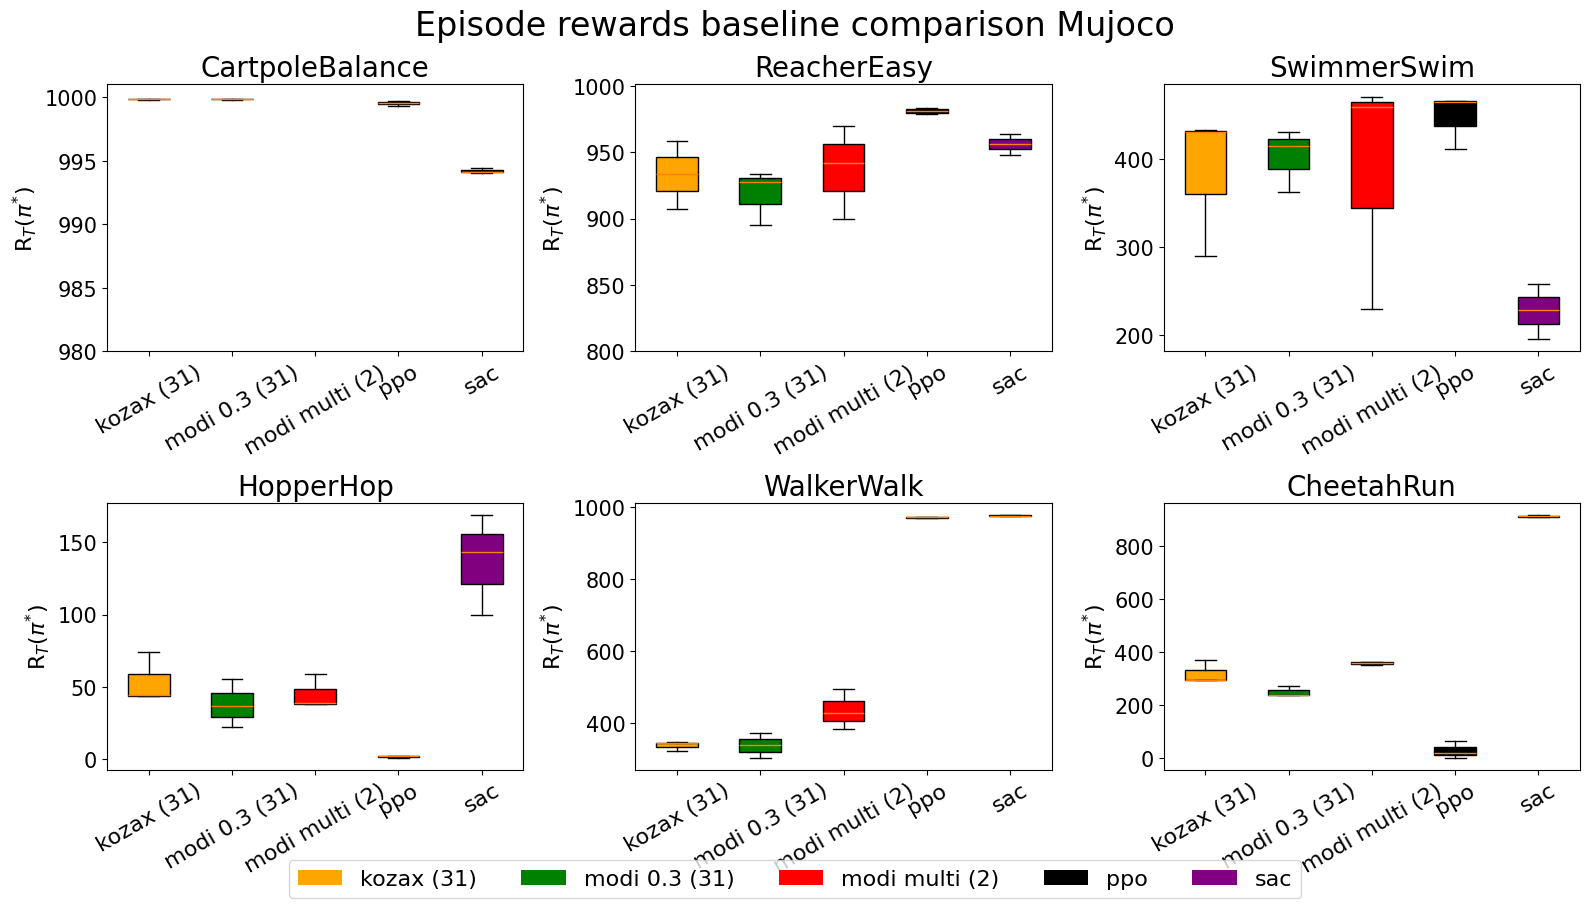

In [39]:
from matplotlib.patches import Patch

nrows = 2
ncols = 3
plot_titles = ["CartpoleBalance", "ReacherEasy", "SwimmerSwim", "HopperHop", "WalkerWalk", "CheetahRun"]
colors = ["orange", "green", "red", "black", "purple"]
tick_labels = ["kozax (31)", "modi 0.3 (31)", "modi multi (2)", "ppo", "sac"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards baseline comparison Mujoco", fontsize = 24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize = 20)
    if plot_titles[idx] == "CartpoleBalance":
      axs[i,j].set_ylim((980, 1001))
    if plot_titles[idx] == "ReacherEasy":
      axs[i,j].set_ylim((800, 1001))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize = 16)
    axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize = 16)
    axs[i,j].tick_params(axis="y", labelsize=15)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize = 16
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)

## Complexity results

In [40]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([25, 21, 17])
reacher_koz = jnp.array([60, 62, 57])
swimmer_koz = jnp.array([62, 56, 61])
hopper_koz = jnp.array([59, 47, 47])
walker2d_koz = jnp.array([37, 42, 32]) # max_nodes = 7
half_cheetah_koz = jnp.array([20, 31, 34]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([28, 25, 19])
reacher_modi = jnp.array([31, 31, 31])
swimmer_modi = jnp.array([31, 31, 31])
hopper_modi = jnp.array([31, 31, 31])
walker2d_modi = jnp.array([31, 29, 31])
half_cheetah_modi = jnp.array([31, 30, 31])

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_multi = jnp.array([])
reacher_modi_multi = jnp.array([62, 56, 60])
swimmer_modi_multi = jnp.array([55, 60, 52])
hopper_modi_multi = jnp.array([55, 55, 45])
walker2d_modi_multi = jnp.array([57, 44, 60])
half_cheetah_modi_multi = jnp.array([56, 54, 58])


# #PPO ()
# inv_pen_ppo = jnp.array([])
# reacher_ppo = jnp.array([])
# swimmer_ppo = jnp.array([])
# hopper_ppo =  jnp.array([])
# walker2d_ppo = jnp.array([])
# half_cheetah_ppo = jnp.array([])

# #SAC ()
# inv_pen_sac = jnp.array([])
# reacher_sac = jnp.array([])
# swimmer_sac = jnp.array([])
# hopper_sac = jnp.array([])
# walker2d_sac = jnp.array([])
# half_cheetah_sac = jnp.array([])

# inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_modi_multi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
# reacher_results = [reacher_koz, reacher_modi, reacher_modi_multi, reacher_cgpax, reacher_ppo, reacher_sac]
# swimmer_results = [swimmer_koz, swimmer_modi, swimmer_modi_multi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
# hopper_results = [hopper_koz, hopper_modi, hopper_modi_multi, hopper_cgpax, hopper_ppo, hopper_sac]
# walker2d_results = [walker2d_koz, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
# half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_modi_multi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
# all_results = [inv_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results]

In [41]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(inv_pen_koz.mean(), inv_pen_koz.std())
print(reacher_koz.mean(), reacher_koz.std())
print(swimmer_koz.mean(), swimmer_koz.std())
print(hopper_koz.mean(), hopper_koz.std())
print(walker2d_koz.mean(), walker2d_koz.std()) # max_nodes = 7
print(half_cheetah_koz.mean(), half_cheetah_koz.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi.mean(), inv_pen_modi.std())
print(reacher_modi.mean(), reacher_modi.std())
print(swimmer_modi.mean(), swimmer_modi.std())
print(hopper_modi.mean(), hopper_modi.std())
print(walker2d_modi.mean(), walker2d_modi.std())
print(half_cheetah_modi.mean(), half_cheetah_modi.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi_multi.mean(), inv_pen_modi_multi.std())
print(reacher_modi_multi.mean(), reacher_modi_multi.std())
print(swimmer_modi_multi.mean(), swimmer_modi_multi.std())
print(hopper_modi_multi.mean(), hopper_modi_multi.std())
print(walker2d_modi_multi.mean(), walker2d_modi_multi.std())
print(half_cheetah_modi_multi.mean(), half_cheetah_modi_multi.std())
print()

# #PPO ()
# print(inv_pen_ppo.mean(), inv_pen_ppo.std())
# print(reacher_ppo.mean(), reacher_ppo.std())
# print(swimmer_ppo.mean(), swimmer_ppo.std())
# print(hopper_ppo.mean(), hopper_ppo.std())
# print(walker2d_ppo.mean(), walker2d_ppo.std())
# print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
# print()

# #SAC ()
# print(inv_pen_sac.mean(), inv_pen_sac.std())
# print(reacher_sac.mean(), reacher_sac.std())
# print(swimmer_sac.mean(), swimmer_sac.std())
# print(hopper_sac.mean(), hopper_sac.std())
# print(walker2d_sac.mean(), walker2d_sac.std())
# print(half_cheetah_sac.mean(), half_cheetah_sac.std())

21.0 3.2659864
59.666668 2.0548048
59.666668 2.6246693
51.0 5.656854
37.0 4.082483
28.333334 6.0184903

24.0 3.7416575
31.0 0.0
31.0 0.0
31.0 0.0
30.333334 0.94280905
30.666668 0.47140452

nan nan
59.333336 2.4944382
55.666668 3.2998316
51.666668 4.714045
53.666668 6.944222
56.0 1.6329932



## Runtime results

In [42]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
inv_pen_koz = jnp.array([447, 361, 306])
reacher_koz = jnp.array([727, 640, 591])
swimmer_koz = jnp.array([1130, 1182, 1149])
hopper_koz = jnp.array([989, 943, 839])
walker2d_koz = jnp.array([1542, 1423, 1434]) # max_nodes = 7
half_cheetah_koz = jnp.array([342, 382, 378]) # max_nodes = 7

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi = jnp.array([718, 732, 630])
reacher_modi = jnp.array([9073, 1196, 2351])
swimmer_modi = jnp.array([7284, 1641, 1696])
hopper_modi = jnp.array([923, 863, 848])
walker2d_modi = jnp.array([1499, 1472, 1447])
half_cheetah_modi = jnp.array([409, 415, 473])

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
inv_pen_modi_multi = jnp.array([])
reacher_modi_multi = jnp.array([853, 890, 1311])
swimmer_modi_multi = jnp.array([1148, 1281, 1052])
hopper_modi_multi = jnp.array([855, 864, 884])
walker2d_modi_multi = jnp.array([1524, 1484, 1489])
half_cheetah_modi_multi = jnp.array([508, 475, 473])

#PPO ()
inv_pen_ppo = jnp.array([1017, 965, 907])
reacher_ppo = jnp.array([1139, 1088, 1065])
swimmer_ppo = jnp.array([2810, 2970, 2930])
hopper_ppo =  jnp.array([1217, 1408, 1463])
walker2d_ppo = jnp.array([1517, 1757, 1736])
half_cheetah_ppo = jnp.array([1110, 1289, 1221])

#SAC ()
inv_pen_sac = jnp.array([385, 397, 380])
reacher_sac = jnp.array([436, 444, 443])
swimmer_sac = jnp.array([1408, 1414, 1397])
hopper_sac = jnp.array([1391, 1394, 1394])
walker2d_sac = jnp.array([763, 764, 707])
half_cheetah_sac = jnp.array([1302, 1310, 1306])

inv_pen_results = [inv_pen_koz, inv_pen_modi, inv_pen_modi_multi, inv_pen_cgpax, inv_pen_ppo, inv_pen_sac]
reacher_results = [reacher_koz, reacher_modi, reacher_modi_multi, reacher_cgpax, reacher_ppo, reacher_sac]
swimmer_results = [swimmer_koz, swimmer_modi, swimmer_modi_multi, swimmer_cgpax, swimmer_ppo, swimmer_sac]
hopper_results = [hopper_koz, hopper_modi, hopper_modi_multi, hopper_cgpax, hopper_ppo, hopper_sac]
walker2d_results = [walker2d_koz, walker2d_modi, walker2d_modi, walker2d_cgpax, walker2d_ppo, walker2d_sac]
half_cheetah_results = [half_cheetah_koz, half_cheetah_modi, half_cheetah_modi_multi, half_cheetah_cgpax, half_cheetah_ppo, half_cheetah_sac]
all_results = [inv_pen_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results]

In [43]:
#Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31)
print(inv_pen_koz.mean(), inv_pen_koz.std())
print(reacher_koz.mean(), reacher_koz.std())
print(swimmer_koz.mean(), swimmer_koz.std())
print(hopper_koz.mean(), hopper_koz.std())
print(walker2d_koz.mean(), walker2d_koz.std()) # max_nodes = 7
print(half_cheetah_koz.mean(), half_cheetah_koz.std()) # max_nodes = 7
print()

#Modi Kozax (pop_size = 5x100, nr_of_gen = 50, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi.mean(), inv_pen_modi.std())
print(reacher_modi.mean(), reacher_modi.std())
print(swimmer_modi.mean(), swimmer_modi.std())
print(hopper_modi.mean(), hopper_modi.std())
print(walker2d_modi.mean(), walker2d_modi.std())
print(half_cheetah_modi.mean(), half_cheetah_modi.std())
print()

#Modi Multi Kozax (pop_size = 100, nr_of_gen = 25, operator_list = [+,-,x,sin,cos], max_nodes = 31, modi_rate = 0.3, carry_on_method = both)
print(inv_pen_modi_multi.mean(), inv_pen_modi_multi.std())
print(reacher_modi_multi.mean(), reacher_modi_multi.std())
print(swimmer_modi_multi.mean(), swimmer_modi_multi.std())
print(hopper_modi_multi.mean(), hopper_modi_multi.std())
print(walker2d_modi_multi.mean(), walker2d_modi_multi.std())
print(half_cheetah_modi_multi.mean(), half_cheetah_modi_multi.std())
print()

#PPO ()
print(inv_pen_ppo.mean(), inv_pen_ppo.std())
print(reacher_ppo.mean(), reacher_ppo.std())
print(swimmer_ppo.mean(), swimmer_ppo.std())
print(hopper_ppo.mean(), hopper_ppo.std())
print(walker2d_ppo.mean(), walker2d_ppo.std())
print(half_cheetah_ppo.mean(), half_cheetah_ppo.std())
print()

#SAC ()
print(inv_pen_sac.mean(), inv_pen_sac.std())
print(reacher_sac.mean(), reacher_sac.std())
print(swimmer_sac.mean(), swimmer_sac.std())
print(hopper_sac.mean(), hopper_sac.std())
print(walker2d_sac.mean(), walker2d_sac.std())
print(half_cheetah_sac.mean(), half_cheetah_sac.std())

371.33334 58.0249
652.6667 56.239567
1153.6667 21.483845
923.6667 62.744633
1466.3334 53.69254
367.33334 17.98765

693.3334 45.146675
4206.667 3473.1738
3540.3335 2647.2673
878.0 32.4037
1472.6667 21.234144
432.33334 28.859816

nan nan
1018.0 207.73221
1160.3334 93.89474
867.6667 12.119773
1499.0 17.79513
485.33334 16.048538

963.0 44.929573
1097.3334 30.922844
2903.3335 67.98692
1362.6667 105.420845
1670.0 108.5265
1206.6667 73.77594

387.33334 7.1336446
441.0 3.5590262
1406.3334 7.039571
1393.0 1.4142135
744.6667 26.637486
1306.0 3.2659864


## Validation Baseline Results

In [44]:
cartpole_muj_koz_31_100 = jnp.array([999.81, 999.84, 999.89])
reacher_muj_koz_31_100 = jnp.array([958.38, 907.38, 933.63])
swimmer_muj_koz_31_100 = jnp.array([433.75, 290.12, 431.28])
hopper_muj_koz_31_100 = jnp.array([44.20, 74.41, 43.71])
walker_muj_koz_31_100 = jnp.array([342.63, 346.39, 321.82])
half_cheetah_muj_koz_31_100 = jnp.array([295.28, 296.50, 370.46])

cartpole_muj_koz_31_100_val = jnp.array([999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55, 999.687, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55, 999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55])
reacher_muj_koz_31_100_val = jnp.array([560., 958., 935., 848., 876., 10., 120., 967., 906., 954., 0., 963., 21., 0., 8., 360., 978., 949., 972., 966., 962., 0., 938., 896., 951., 875., 43., 964., 32., 22.])
swimmer_muj_koz_31_100_val = jnp.array([267.634, 255.458, 711.224, 27.075, 14.01, 428.743, 23.424, 9.856, 124.507, 664.281, 12.536, 16.121, 840.797, 27.684, 13.835, 37.865, 6.353, 10.287, 13.56, 341.262, 280.763, 11.941, 894.36, 36.79, 377.348, 23.267, 29.34, 198.311, 86.544, 606.461])
hopper_muj_koz_31_100_val = jnp.array([22.087, 46.094, 30.424, 42.975, 49.237, 14.758, 33.086, 20.091, 45.175, 35.08, 50.062, 55.835, 103.078, 41.025, 59.774, 46.909, 0., 83.589, 86.485, 72.984, 0., 0., 49.454, 48.054, 0.071, 0., 0., 55.669, 0., 49.893])
walker_muj_koz_31_100_val = jnp.array([255.816, 324.743, 326.308, 256.602, 255.319, 292.164, 257.535, 290.454, 314.176, 199.473, 286.654, 281.65, 282.569, 234.364, 308.975, 291.702, 285.649, 290.315, 224.39, 194.977, 272.288, 263.947, 212.877, 286.494, 294.424, 184.447, 295.429, 274.594, 235.297, 299.392])
half_cheetah_muj_koz_31_100_val = jnp.array([274.479, 278.729, 264.012, 296.48, 294.525, 244.15, 135.257, 243.986, 258.053, 266.829, 135.5, 76.68, 257.092, 275.702, 282.553, 246.632, 261.532, 164.505, 312.732, 328.403, 320.745, 379.107, 358.162, 385.786, 336.995, 334.997, 329.397, 316.839, 341.817, 365.036])

cartpole_muj_modi_31_100 = jnp.array([999.81, 999.84, 999.89])
reacher_muj_modi_31_100 = jnp.array([895.0, 927.31, 933.44])
swimmer_muj_modi_31_100 = jnp.array([430.86, 363.18, 414.93])
hopper_muj_modi_31_100 = jnp.array([22.46, 55.55, 36.60])
walker_muj_modi_31_100 = jnp.array([371.01, 302.67, 337.69])
half_cheetah_muj_modi_31_100 = jnp.array([274.14, 238.87, 238.09])

cartpole_muj_modi_31_100_val = jnp.array([999.681, 999.895, 999.882, 999.439, 999.824, 999.703, 999.805, 999.592, 999.871, 999.542, 999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55, 999.686, 999.897, 999.883, 999.441, 999.824, 999.706, 999.807, 999.6, 999.872, 999.55])
reacher_muj_modi_31_100_val = jnp.array([874., 974., 959., 942., 837., 821., 718., 951., 980., 6., 986., 45., 956., 944., 0., 628., 74., 887., 77., 19., 913., 613., 911., 901., 940., 915., 853., 981., 835., 0.])
swimmer_muj_modi_31_100_val = jnp.array([177.766, 11.786, 900.767, 35.742, 14.086, 21.9, 11.597, 9.76, 60.66, 643.165, 32.995, 11.623, 890.912, 30.058, 118.027, 22.494, 23.144, 10.377, 103.198, 576.589, 297.094, 12.297, 616.514, 150.59, 383.667, 24.366, 34.33, 228.602, 164.441, 667.77])
hopper_muj_modi_31_100_val = jnp.array([0., 0., 29.344, 32.354, 0., 0., 32.865, 26.848, 0., 20.944, 51.364, 26.723, 37.244, 53.643, 20.863, 39.085, 34.496, 41.529, 36.987, 49.234, 0., 0., 36.191, 35.188, 0.088, 0., 0., 33.703, 0., 37.048])
walker_muj_modi_31_100_val = jnp.array([316.619, 345.502, 280.08, 368.348, 341.867, 390.875, 363.044, 344.176, 341.779, 329.082, 200.299, 204.469, 314.776, 235.352, 201.337, 276.866, 266.976, 266.101, 300.673, 138.327, 370.719, 262.261, 309.53, 367.203, 326.679, 333.46, 331.307, 209.457, 285.203, 294.864])
half_cheetah_muj_modi_31_100_val = jnp.array([248.874, 285.53, 258.969, 263.085, 276.086, 254.769, 271.678, 241.969, 269.057, 265.845, 215.596, 226.494, 224.309, 230.642, 214.656, 216.992, 230.202, 113.078, 230.675, 169.496, 226.51, 220.368, 222.571, 236.734, 192.973, 229.68, 127.878, 165.906, 224.036, 221.508])

cartpole_results = [cartpole_muj_koz_31_100, cartpole_muj_koz_31_100_val, cartpole_muj_modi_31_100, cartpole_muj_modi_31_100_val]
reacher_results = [reacher_muj_koz_31_100, reacher_muj_koz_31_100_val, reacher_muj_modi_31_100, reacher_muj_modi_31_100_val]
swimmer_results = [swimmer_muj_koz_31_100, swimmer_muj_koz_31_100_val, swimmer_muj_modi_31_100, swimmer_muj_modi_31_100_val]
hopper_results = [hopper_muj_koz_31_100, hopper_muj_koz_31_100_val, hopper_muj_modi_31_100, hopper_muj_modi_31_100_val]
walker2d_results = [walker_muj_koz_31_100, walker_muj_koz_31_100_val, walker_muj_modi_31_100, walker_muj_modi_31_100_val]
half_cheetah_results = [half_cheetah_muj_koz_31_100, half_cheetah_muj_koz_31_100_val, half_cheetah_muj_modi_31_100, half_cheetah_muj_modi_31_100_val]
all_results = [cartpole_results, reacher_results, swimmer_results, hopper_results, walker2d_results, half_cheetah_results]

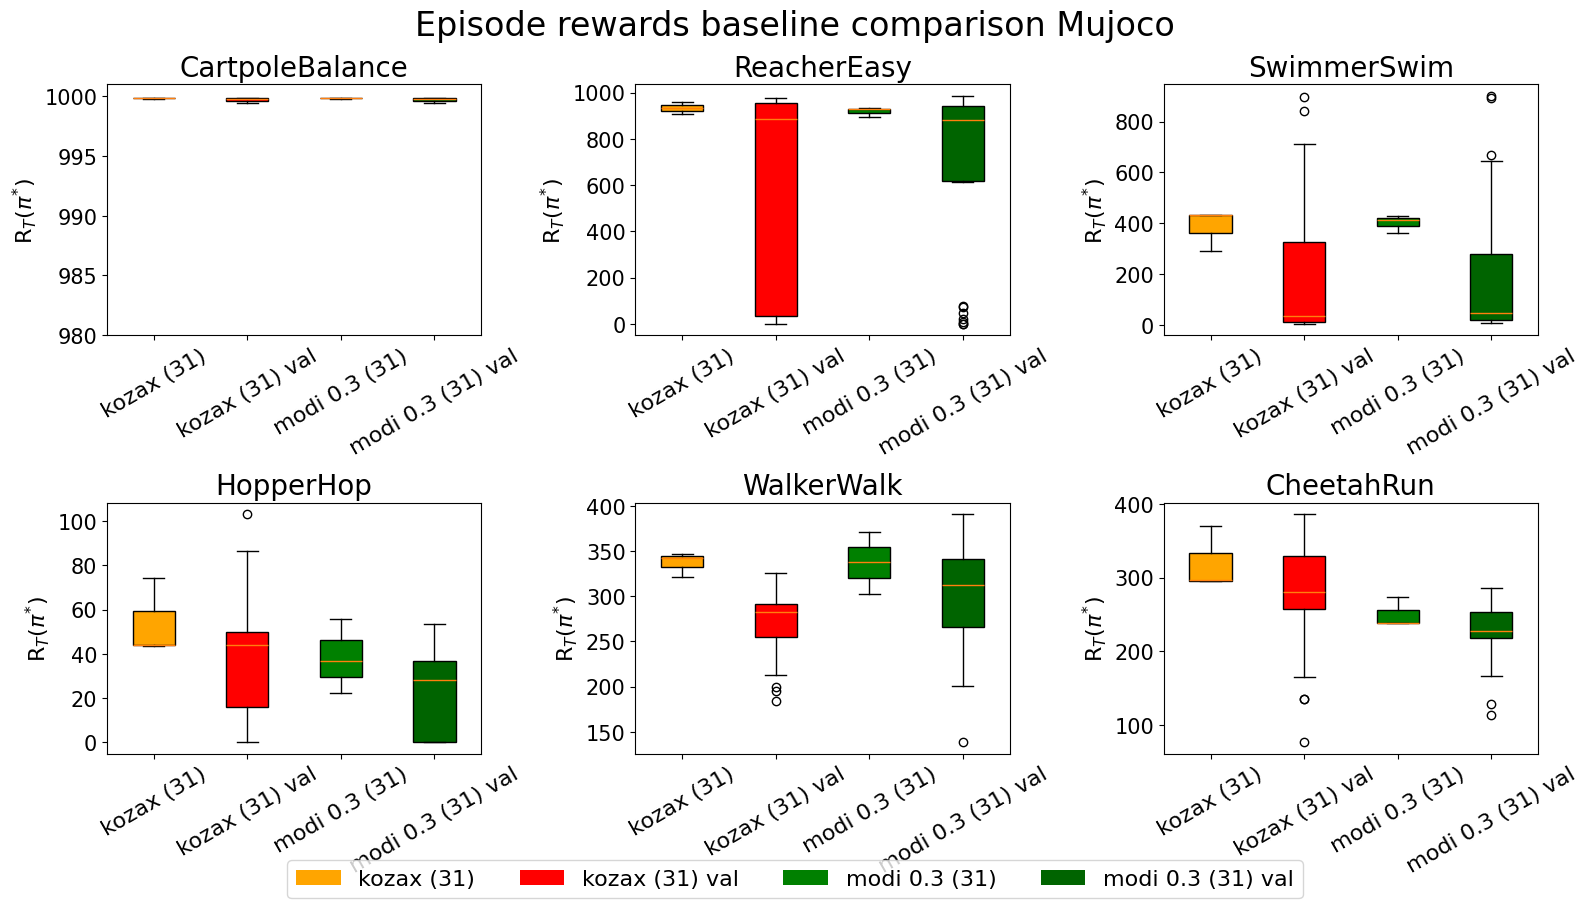

In [45]:
from matplotlib.patches import Patch

nrows = 2
ncols = 3
plot_titles = ["CartpoleBalance", "ReacherEasy", "SwimmerSwim", "HopperHop", "WalkerWalk", "CheetahRun"]
colors = ["orange", "red", "green", "darkgreen"]
tick_labels = ["kozax (31)", "kozax (31) val", "modi 0.3 (31)", "modi 0.3 (31) val"]
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 9))
fig.suptitle("Episode rewards baseline comparison Mujoco", fontsize = 24)
for i in range(nrows):
  for j in range(ncols):
    idx = i * ncols + j
    bp = axs[i,j].boxplot(all_results[idx], patch_artist=True)
    for patch, color in zip(bp['boxes'], colors):
      patch.set_facecolor(color)
    # for patch, color in zip(axs['boxes'], colors):
    #   patch.set_facecolor(color)
    axs[i,j].set_title(plot_titles[idx], fontsize = 20)
    if plot_titles[idx] == "CartpoleBalance":
      axs[i,j].set_ylim((980, 1001))
    axs[i,j].set_ylabel(r"R$_T$($\pi^{*}$)", fontsize = 16)
    axs[i,j].set_xticklabels(tick_labels, rotation=30, fontsize = 16)
    axs[i,j].tick_params(axis="y", labelsize=15)

legend_elements = [
    Patch(facecolor=color, label=label)
    for color, label in zip(colors, tick_labels)
]

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=len(tick_labels),
    bbox_to_anchor=(0.5, -0.02),
    fontsize = 16
)
plt.tight_layout()
    # axs[i,j].get_xaxis().set_visible(False)